# ANADI – Trabalho Prático 2
## 4.1 Análise Exploratória de Dados (EDA)
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Analisar o impacto da eficiência energética na iluminação pública sobre a reserva de potência dos Postos de Transformação de Distribuição (PTD) e avaliar a viabilidade de instalação de carregadores de veículos elétricos.

---
## 1. Carregamento do Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
from pathlib import Path

# Garante que o diretório de trabalho é o da pasta do notebook (funciona em qualquer PC)
try:
    os.chdir(Path(__vsc_ipynb_file__).parent)
except NameError:
    pass  # Jupyter clássico: lançar a partir da pasta do projeto

sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel('data/PTD_level_dataset.xlsx')
print('Dimensão do dataset:', df.shape)
print(f'Registos: {df.shape[0]:,} | Variáveis: {df.shape[1]}')

Dimensão do dataset: (72027, 32)
Registos: 72,027 | Variáveis: 32


In [2]:
# Primeiros registos
df.head()

,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [3]:
# Informação geral: tipos de dados e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  flo

In [4]:
# Sumário estatístico das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CodDistritoConcelho,72027.0,989.432671,4.939913e+02,101.000000,603.000000,1106.000000,1317.000000,1824.000000
Potência instalada [kVA],72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Cap_PTD_kVA,72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Pot_Contratada_kVA,50847.0,80941.484060,6.714603e+04,5456.000000,34035.500000,60886.000000,106720.000000,804687.000000
N_Clientes,72027.0,94.698002,1.100551e+02,20.000000,20.000000,54.000000,124.000000,1438.000000
Pot_Geracao_kW,1836.0,6216.724401,2.876378e+03,1622.000000,4271.750000,5574.500000,7393.500000,22032.000000
N_Clientes_Produtores,72027.0,20.203479,2.017686e+00,20.000000,20.000000,20.000000,20.000000,106.000000
P_IP_Total,72027.0,1381.490215,1.723711e+03,23.218600,382.569000,842.179701,1766.391301,9065.655300
P_IP_Inef,72027.0,463.290614,7.080096e+02,0.000000,28.985000,137.720000,625.790000,3494.920000
Rate_Ineficiencia,72027.0,0.280694,2.403671e-01,0.000000,0.064209,0.229231,0.447381,0.983568


---
## 2. Exploração Visual dos Dados

### 2.1 Valores Omissos

                         Valores Omissos  Percentagem (%)
Pot_Geracao_kW                     70191            97.45
Geracao_per_Cliente                70191            97.45
PContratada_per_Cliente            21180            29.41
Pot_Contratada_kVA                 21180            29.41
D_PTD_LED                           3064             4.25
D_PTD                               3064             4.25
Util_Decimal                        3064             4.25
PFolga_PTD                          3064             4.25


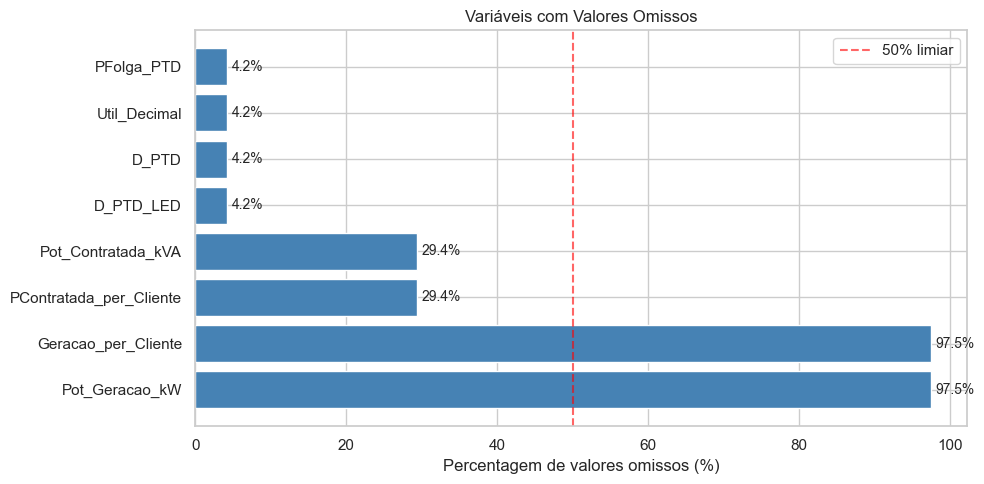

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Omissos': missing, 'Percentagem (%)': missing_pct})
missing_df = missing_df[missing_df['Valores Omissos'] > 0].sort_values('Percentagem (%)', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentagem (%)'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('Percentagem de valores omissos (%)')
ax.set_title('Variáveis com Valores Omissos')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% limiar')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Distribuição da Variável Categórica: Tipo Construtivo

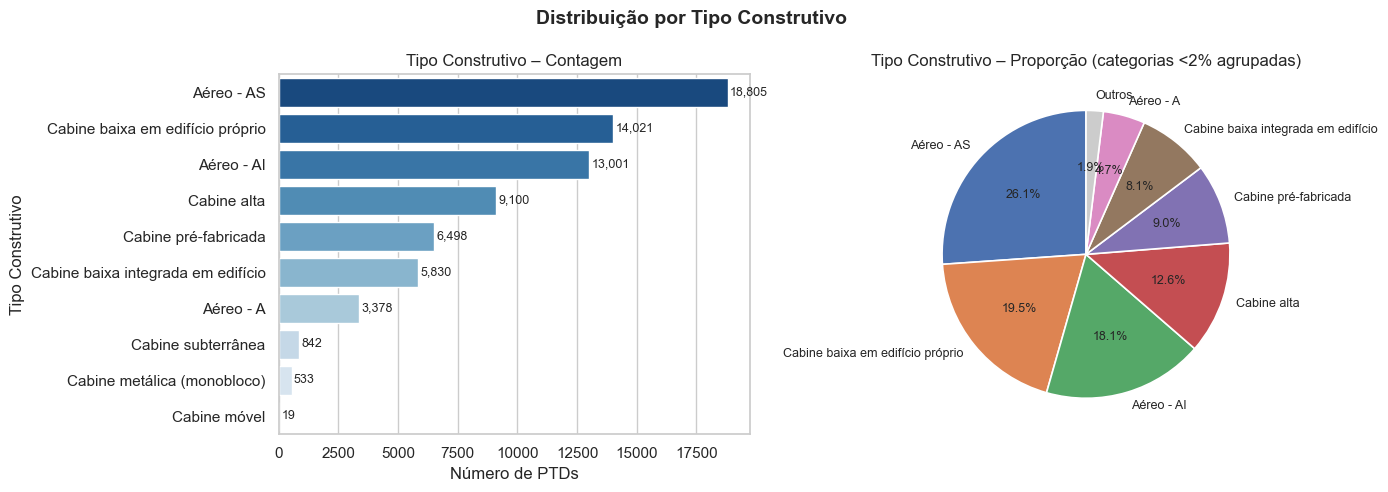

Categorias agrupadas em "Outros" (< 2% = < 1441 PTDs):
  - Cabine subterrânea: 842 PTDs (1.17%)
  - Cabine metálica (monobloco): 533 PTDs (0.74%)
  - Cabine móvel: 19 PTDs (0.03%)


In [6]:
tipo_counts = df['Tipo Construtivo'].value_counts()

# Agrupar categorias raras (< 2%) em "Outros"
threshold = 0.02 * tipo_counts.sum()
outros_sum = tipo_counts[tipo_counts < threshold].sum()
tipo_grouped = tipo_counts[tipo_counts >= threshold].copy()
tipo_grouped['Outros'] = outros_sum

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras (dados originais completos)
sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0],
            hue=tipo_counts.index, palette='Blues_r', legend=False)
axes[0].set_xlabel('Número de PTDs')
axes[0].set_title('Tipo Construtivo – Contagem')
for i, v in enumerate(tipo_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Gráfico circular (dados agrupados)
wedges, texts, autotexts = axes[1].pie(
    tipo_grouped.values,
    labels=tipo_grouped.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for i, label in enumerate(tipo_grouped.index):
    if label == 'Outros':
        wedges[i].set_facecolor('#cccccc')

axes[1].set_title('Tipo Construtivo – Proporção (categorias <2% agrupadas)')

plt.suptitle('Distribuição por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar o que foi agrupado
raras = tipo_counts[tipo_counts < threshold]
print(f'Categorias agrupadas em "Outros" (< 2% = < {threshold:.0f} PTDs):')
for nome, count in raras.items():
    print(f'  - {nome}: {count:,} PTDs ({count/tipo_counts.sum()*100:.2f}%)')

### 2.3 Distribuição do Nível de Utilização dos PTDs

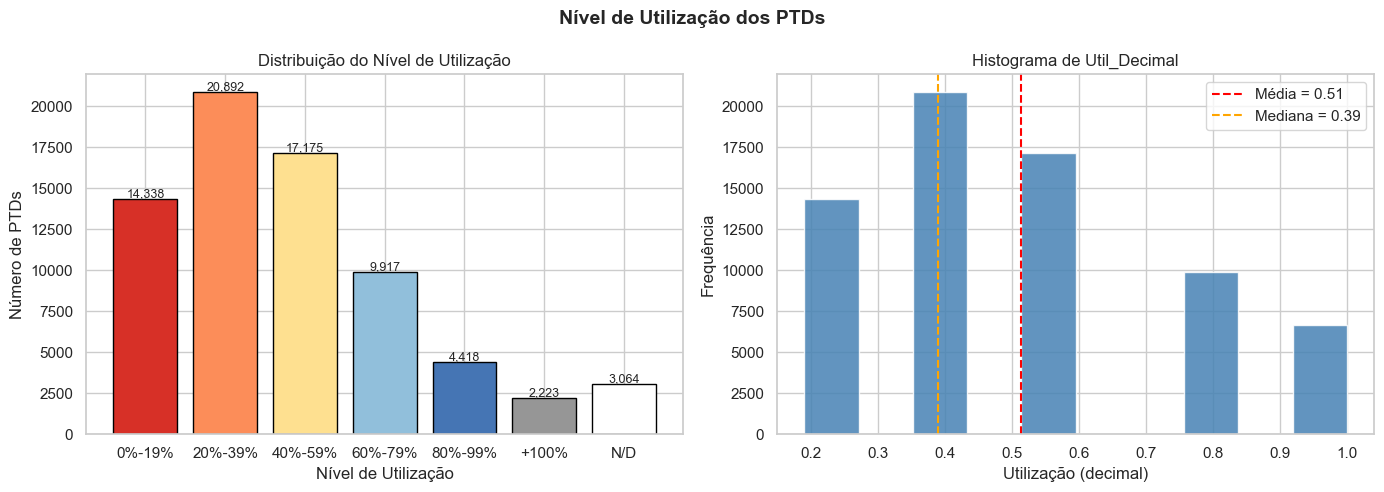

PTDs com utilização acima de 80%: 6,641 (9.6%)


In [7]:
util_col = [c for c in df.columns if 'Utiliza' in c][0]
util_counts = df[util_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por categoria
cores = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4', '#969696', '#ffffff']
cats_order = ['0%-19%', '20%-39%', '40%-59%', '60%-79%', '80%-99%', '+100%', 'N/D']
ordered = [util_counts.get(c, 0) for c in cats_order]
axes[0].bar(cats_order, ordered, color=cores[:len(cats_order)], edgecolor='black')
axes[0].set_xlabel('Nível de Utilização')
axes[0].set_ylabel('Número de PTDs')
axes[0].set_title('Distribuição do Nível de Utilização')
for i, v in enumerate(ordered):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Histograma de Util_Decimal (excluindo N/D)
util_dec = df['Util_Decimal'].dropna()
axes[1].hist(util_dec, bins=10, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(util_dec.mean(), color='red', linestyle='--', label=f'Média = {util_dec.mean():.2f}')
axes[1].axvline(util_dec.median(), color='orange', linestyle='--', label=f'Mediana = {util_dec.median():.2f}')
axes[1].set_xlabel('Utilização (decimal)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma de Util_Decimal')
axes[1].legend()

plt.suptitle('Nível de Utilização dos PTDs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PTDs com utilização acima de 80%: {(util_dec >= 0.8).sum():,} ({(util_dec >= 0.8).mean()*100:.1f}%)')

### 2.4 Distribuição das Variáveis Numéricas Principais

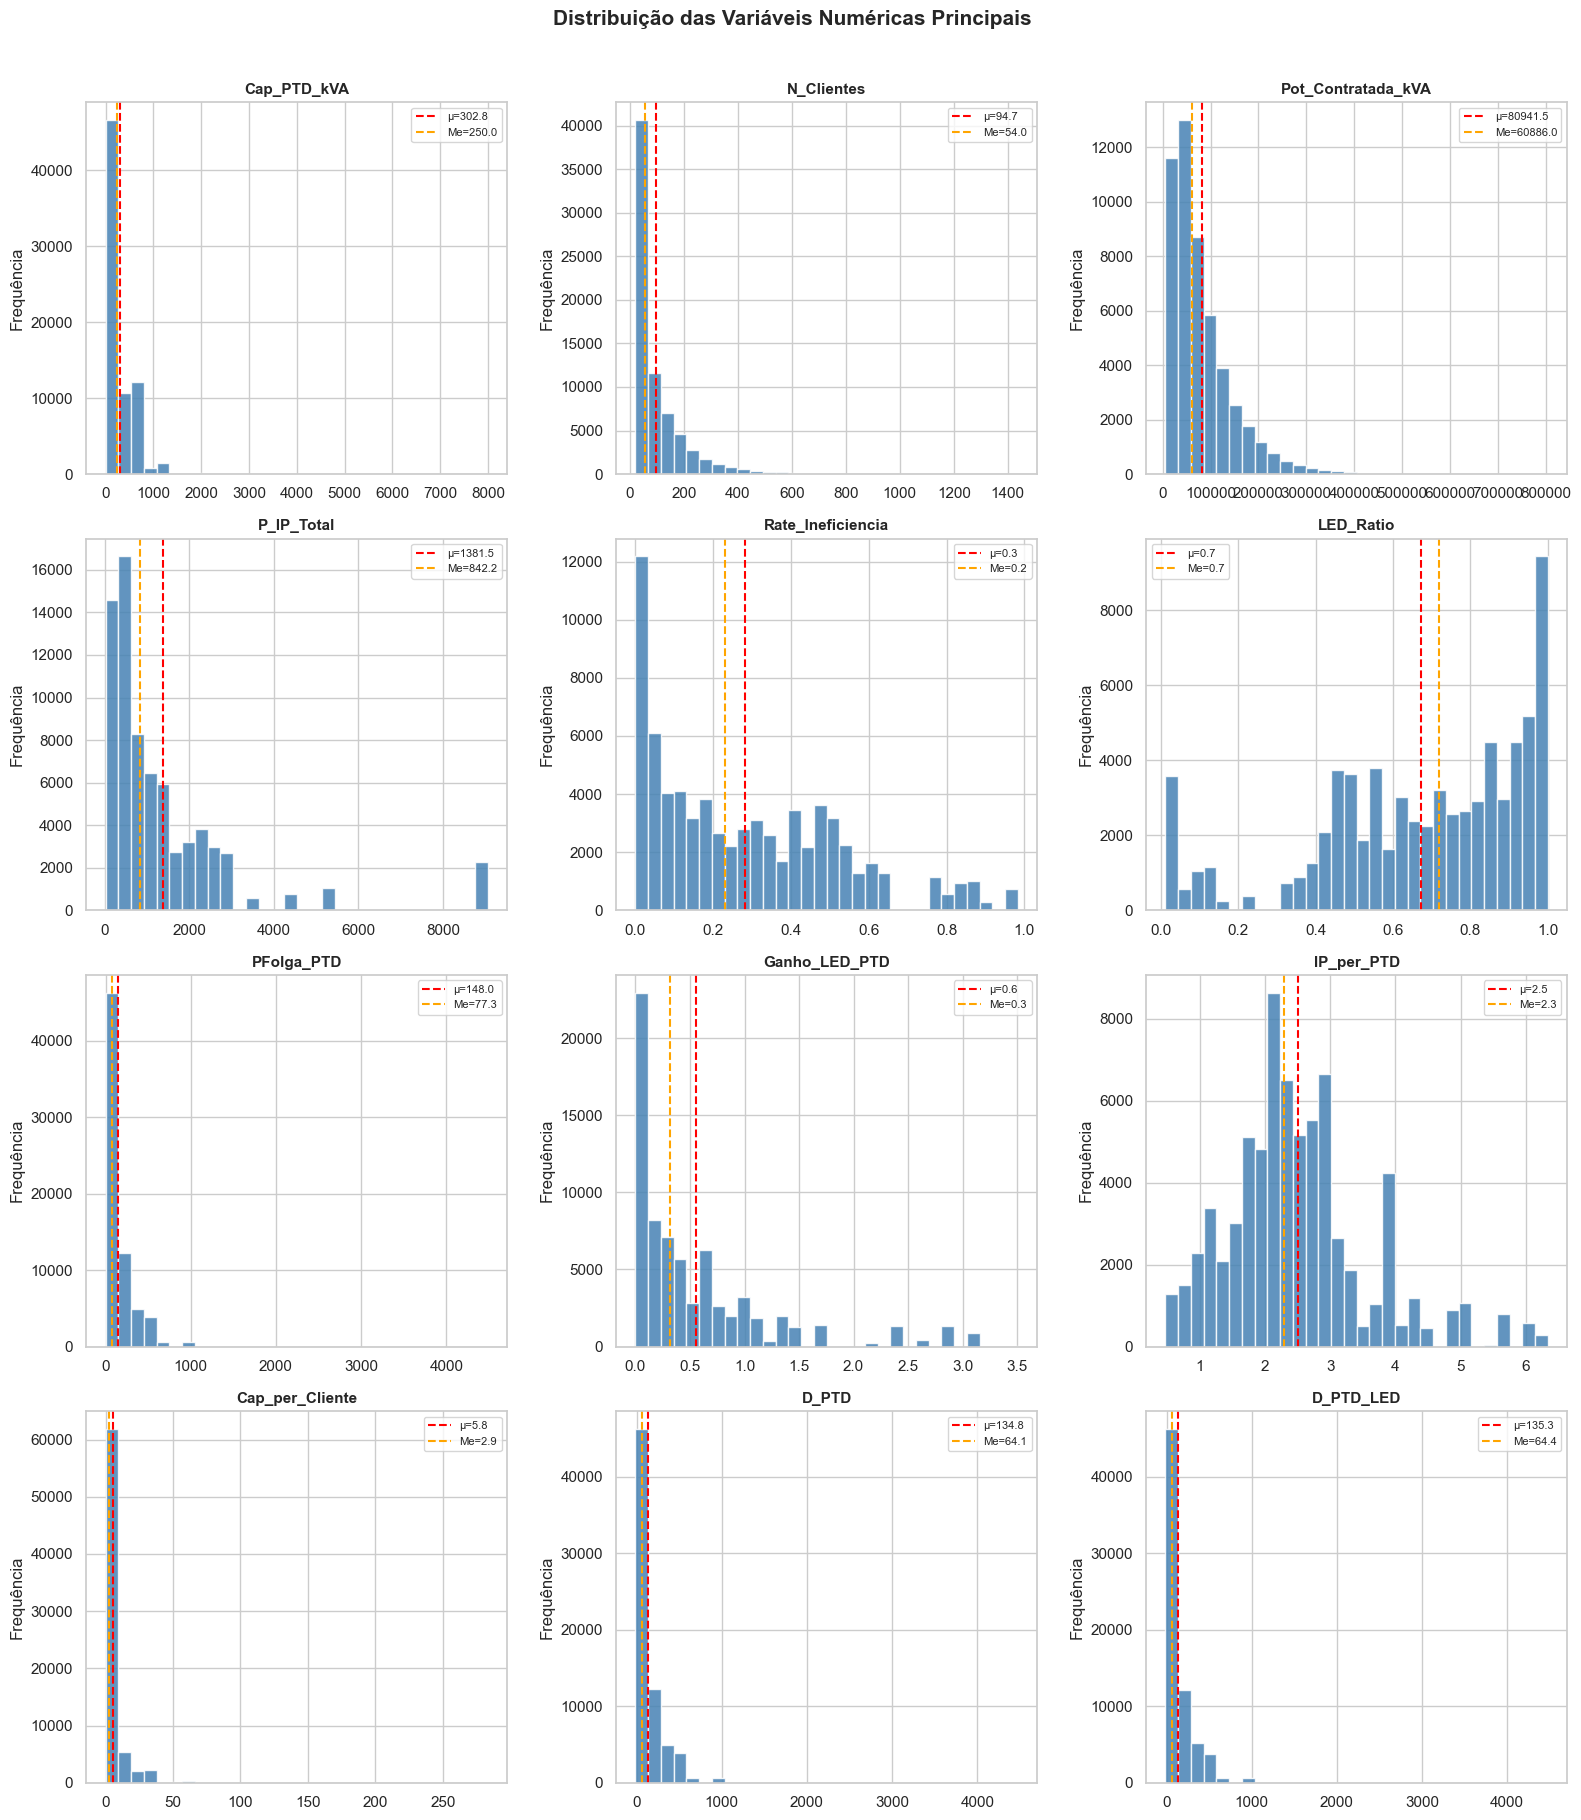

Assimetria (skewness) das variáveis principais:
Cap_per_Cliente       6.00
PFolga_PTD            3.77
D_PTD                 3.77
D_PTD_LED             3.76
Cap_PTD_kVA           3.41
P_IP_Total            3.00
N_Clientes            2.88
Pot_Contratada_kVA    2.14
Ganho_LED_PTD         1.97
IP_per_PTD            0.93
Rate_Ineficiencia     0.77
LED_Ratio            -0.83


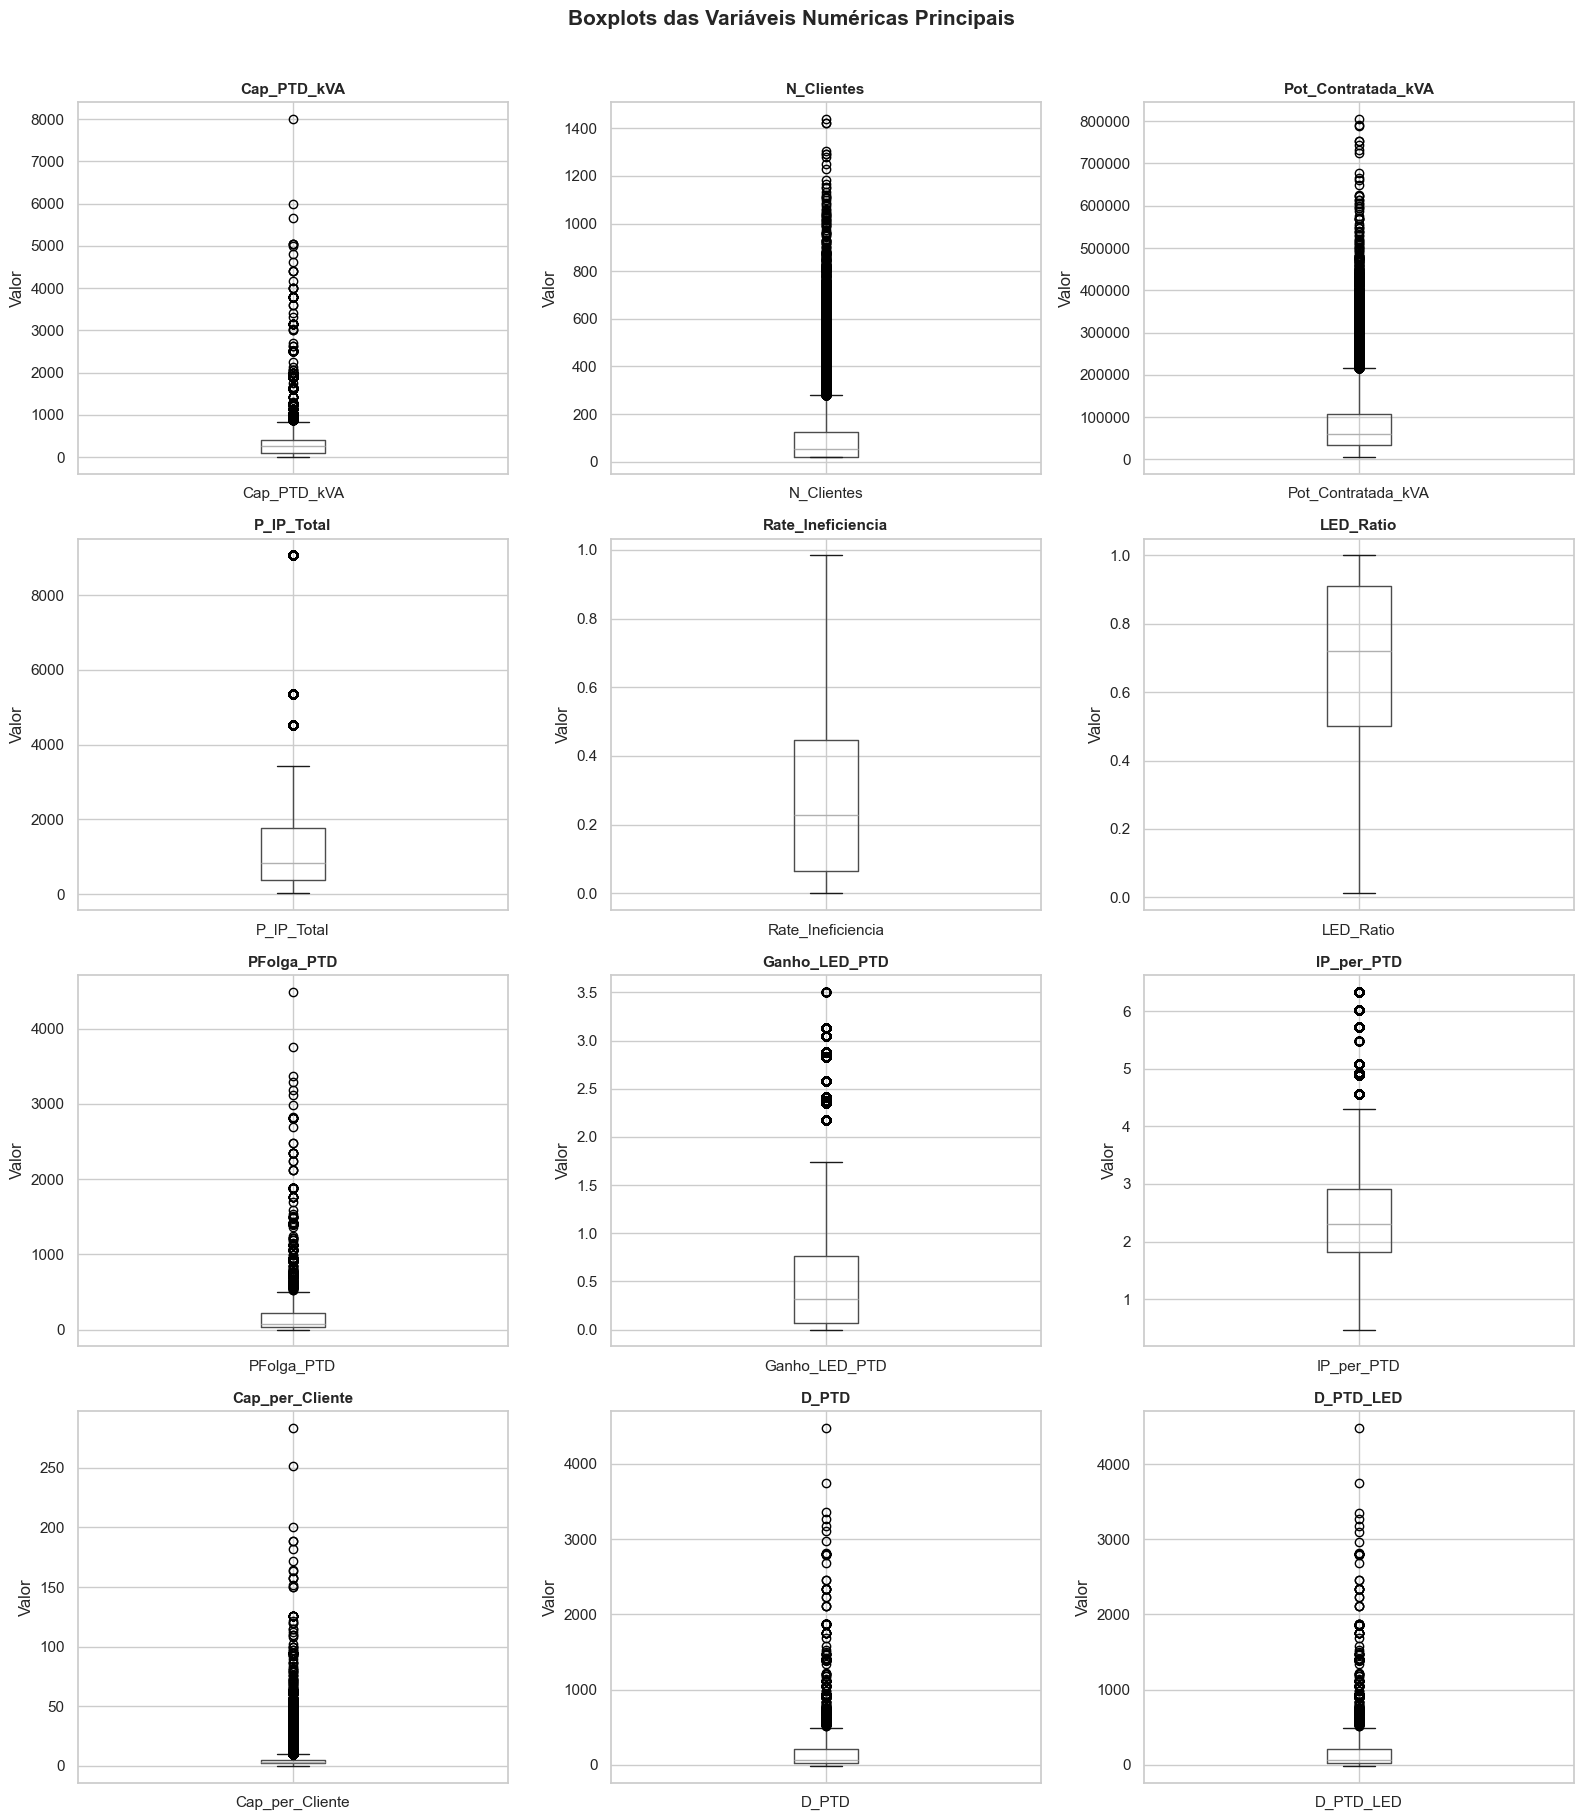

In [8]:
vars_principais = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'PFolga_PTD', 'Ganho_LED_PTD', 'IP_per_PTD',
    'Cap_per_Cliente', 'D_PTD', 'D_PTD_LED'
]

# ── Histogramas ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Me={data.median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Assimetria (skewness) ─────────────────────────────────────────────────────
print('Assimetria (skewness) das variáveis principais:')
skewness = df[vars_principais].skew().sort_values(ascending=False).round(2)
print(skewness.to_string())

# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[[col]].dropna()
    data.boxplot(ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Boxplots por Tipo Construtivo

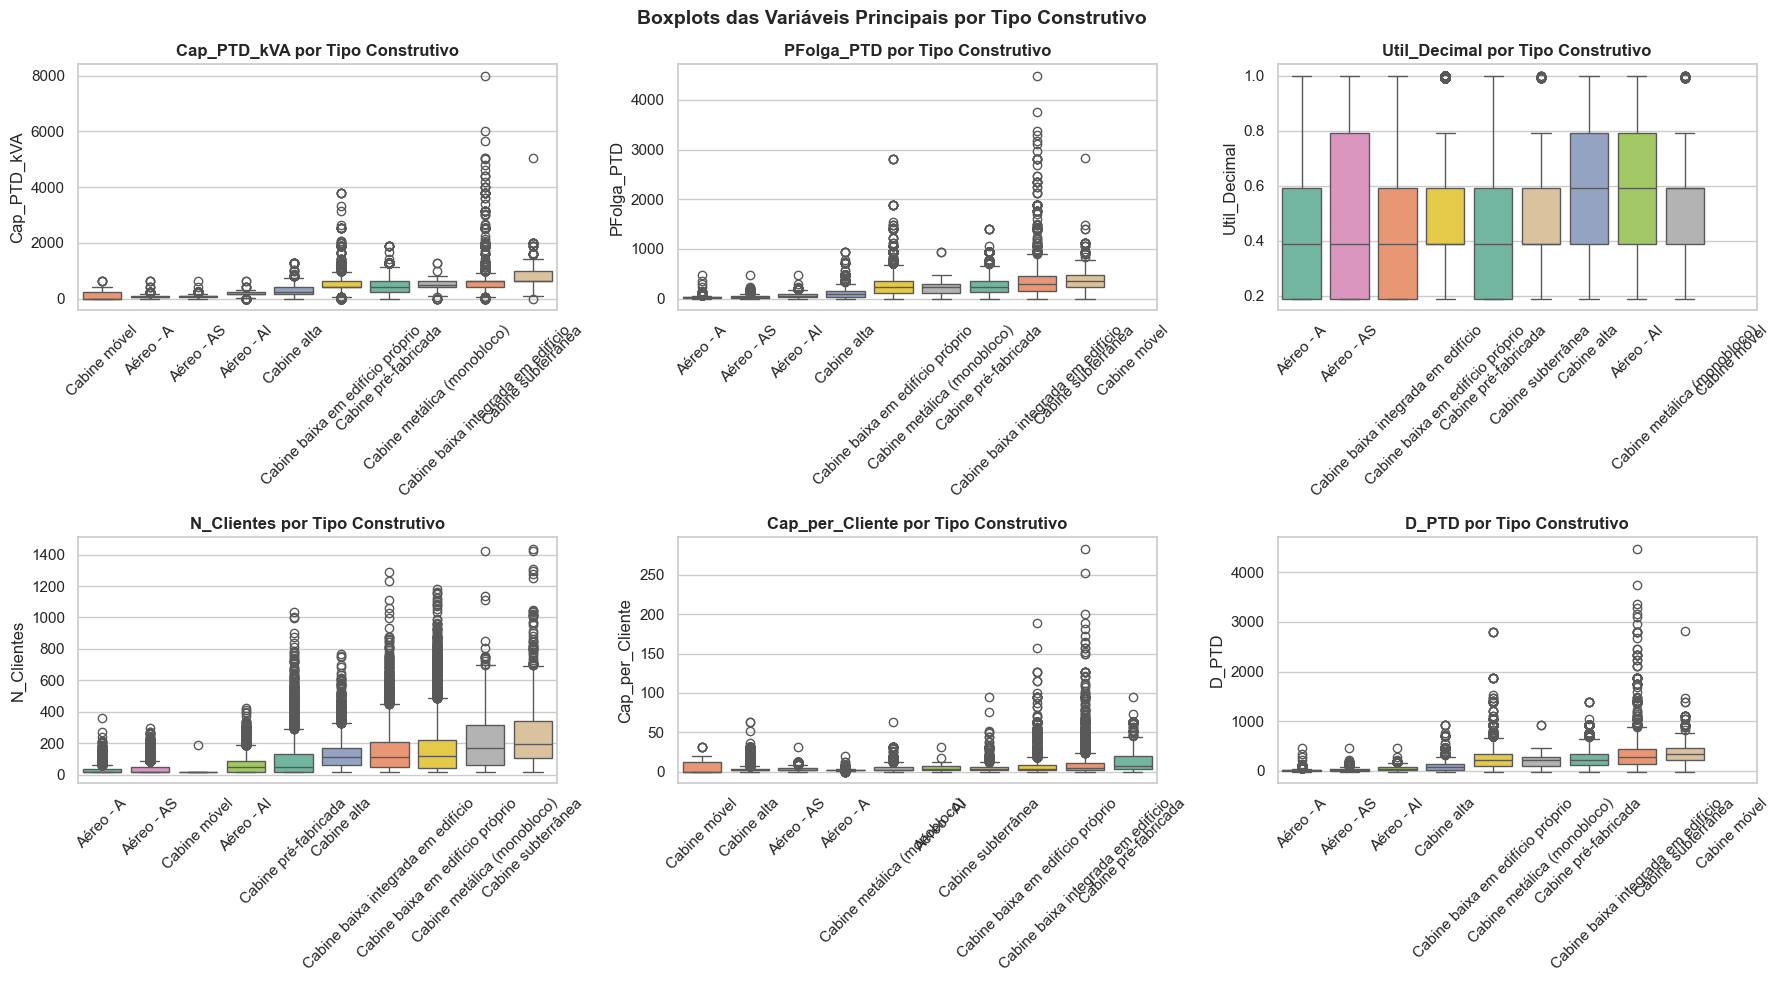

In [9]:
vars_boxplot = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal',
                'N_Clientes', 'Cap_per_Cliente', 'D_PTD']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    order = df.groupby('Tipo Construtivo')[col].median().sort_values().index
    sns.boxplot(
        data=df, x='Tipo Construtivo', y=col,
        ax=axes[i], palette='Set2',
        hue='Tipo Construtivo', legend=False,
        order=order
    )
    axes[i].set_title(f'{col} por Tipo Construtivo', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Boxplots das Variáveis Principais por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Matriz de Correlação

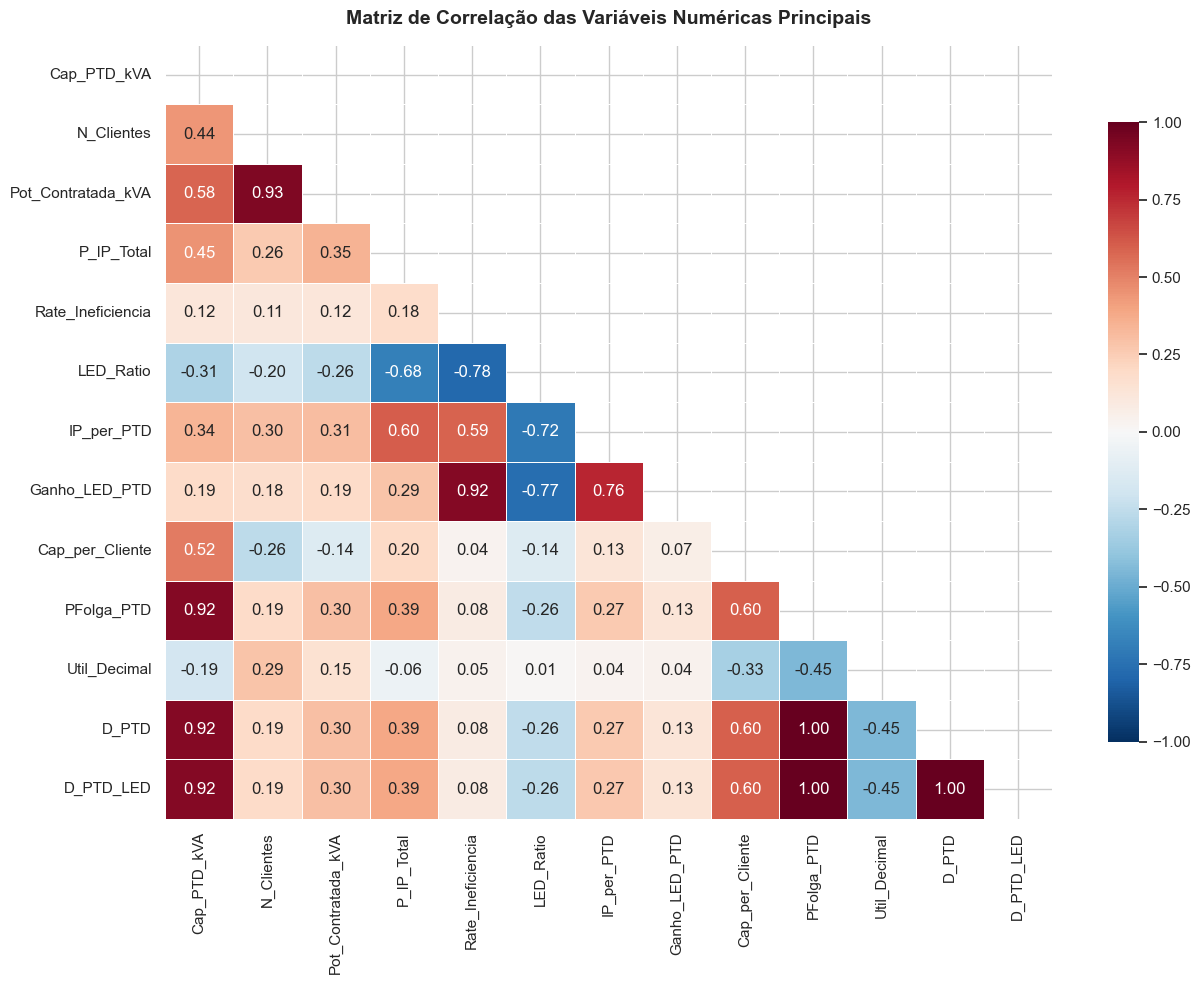

In [10]:
vars_corr = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente',
    'PFolga_PTD', 'Util_Decimal', 'D_PTD', 'D_PTD_LED'
]

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação das Variáveis Numéricas Principais', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2.7 Relações-Chave entre Variáveis

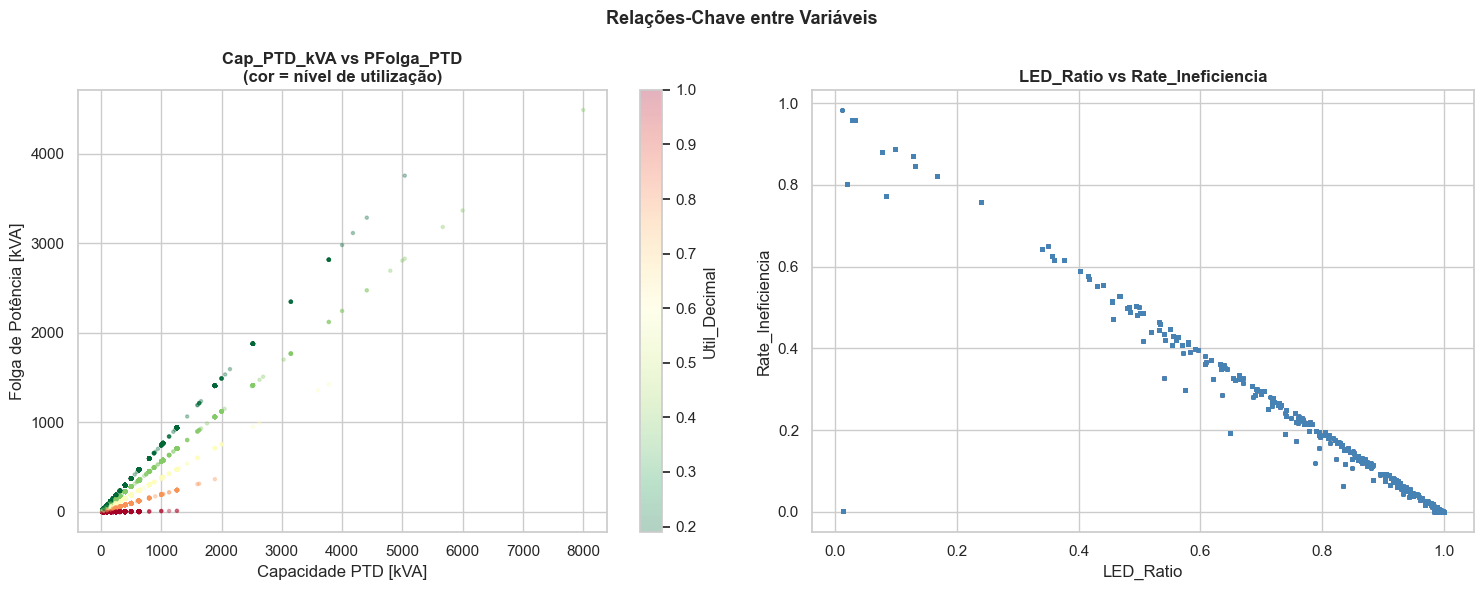

In [11]:
# Folga de Potência vs Capacidade do PTD — colorido por Tipo Construtivo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_data = df[['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'LED_Ratio',
                    'Rate_Ineficiencia', 'Tipo Construtivo']].dropna()

# Scatter: Cap_PTD_kVA vs PFolga_PTD
sc1 = axes[0].scatter(
    scatter_data['Cap_PTD_kVA'], scatter_data['PFolga_PTD'],
    c=scatter_data['Util_Decimal'], cmap='RdYlGn_r',
    alpha=0.3, s=5
)
plt.colorbar(sc1, ax=axes[0], label='Util_Decimal')
axes[0].set_xlabel('Capacidade PTD [kVA]')
axes[0].set_ylabel('Folga de Potência [kVA]')
axes[0].set_title('Cap_PTD_kVA vs PFolga_PTD\n(cor = nível de utilização)', fontweight='bold')

# Scatter: LED_Ratio vs Rate_Ineficiencia
sc2 = axes[1].scatter(
    scatter_data['LED_Ratio'], scatter_data['Rate_Ineficiencia'],
    alpha=0.2, s=5, color='steelblue'
)
axes[1].set_xlabel('LED_Ratio')
axes[1].set_ylabel('Rate_Ineficiencia')
axes[1].set_title('LED_Ratio vs Rate_Ineficiencia', fontweight='bold')

plt.suptitle('Relações-Chave entre Variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

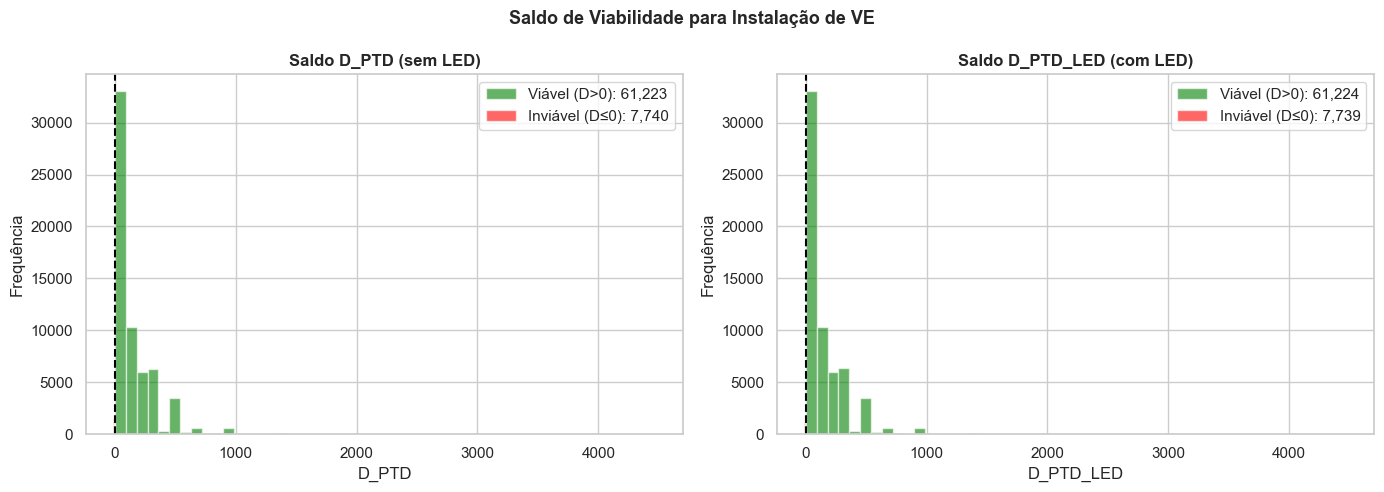

PTDs viáveis SEM LED:  61,223 / 68,963 (88.8%)
PTDs viáveis COM LED:  61,224 / 68,963 (88.8%)


In [12]:
# Distribuição de D_PTD e D_PTD_LED — Viabilidade de VE
d_data = df[['D_PTD', 'D_PTD_LED']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['D_PTD', 'D_PTD_LED'],
                           ['Saldo D_PTD (sem LED)', 'Saldo D_PTD_LED (com LED)']):
    data = d_data[col]
    pos = (data > 0).sum()
    neg = (data <= 0).sum()
    ax.hist(data[data > 0], bins=50, color='green', alpha=0.6, label=f'Viável (D>0): {pos:,}')
    ax.hist(data[data <= 0], bins=30, color='red', alpha=0.6, label=f'Inviável (D≤0): {neg:,}')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Saldo de Viabilidade para Instalação de VE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total = len(d_data)
print(f'PTDs viáveis SEM LED:  {(d_data["D_PTD"] > 0).sum():,} / {total:,} ({(d_data["D_PTD"] > 0).mean()*100:.1f}%)')
print(f'PTDs viáveis COM LED:  {(d_data["D_PTD_LED"] > 0).sum():,} / {total:,} ({(d_data["D_PTD_LED"] > 0).mean()*100:.1f}%)')

---
## 3. Pré-processamento dos Dados
### 3.1 Tratamento de Valores Omissos

In [13]:
df_clean = df.copy()

# Pot_Geracao_kW e Geracao_per_Cliente: ~97% de valores omissos → remover colunas
cols_drop_missing = ['Pot_Geracao_kW', 'Geracao_per_Cliente']
df_clean.drop(columns=cols_drop_missing, inplace=True)
print(f'Colunas removidas por excesso de valores omissos (>95%): {cols_drop_missing}')

# Nível de Utilização com valor "N/D" corresponde às mesmas linhas com PFolga_PTD = NaN
# Remover registos sem PFolga_PTD (não é possível calcular métricas principais)
n_antes = len(df_clean)
util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)
print(f'Registos removidos (PFolga_PTD/Util indefinido): {n_antes - len(df_clean):,}')
print(f'Registos restantes: {len(df_clean):,}')

# Pot_Contratada_kVA: ~29% de valores omissos → imputar com mediana por Tipo Construtivo
df_clean['Pot_Contratada_kVA'] = df_clean.groupby('Tipo Construtivo')['Pot_Contratada_kVA'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['PContratada_per_Cliente'] = df_clean.groupby('Tipo Construtivo')['PContratada_per_Cliente'].transform(
    lambda x: x.fillna(x.median())
)
print(f'\nValores omissos restantes:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Colunas removidas por excesso de valores omissos (>95%): ['Pot_Geracao_kW', 'Geracao_per_Cliente']
Registos removidos (PFolga_PTD/Util indefinido): 3,064
Registos restantes: 68,963

Valores omissos restantes:
Series([], dtype: int64)


### 3.2 Transformação de Variáveis Categóricas

In [14]:
# Tipo Construtivo - One-Hot Encoding (todas as categorias, sem agrupamento)
print('Categorias de Tipo Construtivo:')
print(df_clean['Tipo Construtivo'].value_counts().to_string())

df_clean = pd.get_dummies(df_clean, columns=['Tipo Construtivo'], drop_first=False, dtype=int)
cols_ohe_tipo = [c for c in df_clean.columns if 'Tipo Construtivo' in c]
n_tipo = len(cols_ohe_tipo)
print('Colunas OHE Tipo Construtivo (' + str(n_tipo) + '):', cols_ohe_tipo)

# Distrito - One-Hot Encoding
n_dist = df_clean['Distrito'].nunique()
print('Distritos unicos:', n_dist)
print(df_clean['Distrito'].value_counts().to_string())

df_clean = pd.get_dummies(df_clean, columns=['Distrito'], drop_first=False, dtype=int)
cols_ohe_dist = [c for c in df_clean.columns if c.startswith('Distrito_')]
n_dist_cols = len(cols_ohe_dist)
print('Colunas OHE Distrito (' + str(n_dist_cols) + '):', cols_ohe_dist)


Categorias de Tipo Construtivo:
Tipo Construtivo
Aéreo - AS                            17888
Cabine baixa em edifício próprio      13486
Aéreo - AI                            12359
Cabine alta                            8844
Cabine pré-fabricada                   6119
Cabine baixa integrada em edifício     5655
Aéreo - A                              3269
Cabine subterrânea                      829
Cabine metálica (monobloco)             514
Colunas OHE Tipo Construtivo (9): ['Tipo Construtivo_Aéreo - A', 'Tipo Construtivo_Aéreo - AI', 'Tipo Construtivo_Aéreo - AS', 'Tipo Construtivo_Cabine alta', 'Tipo Construtivo_Cabine baixa em edifício próprio', 'Tipo Construtivo_Cabine baixa integrada em edifício', 'Tipo Construtivo_Cabine metálica (monobloco)', 'Tipo Construtivo_Cabine pré-fabricada', 'Tipo Construtivo_Cabine subterrânea']


Distritos unicos: 18
Distrito
Porto               8725
Lisboa              8490
Braga               4992
Faro                4974
Santarém            4488
Setúbal             4425
Aveiro              4348
Leiria              4167
Viseu               3828
Coimbra             3188
Castelo Branco      2652
Beja                2599
Guarda              2371
Évora               2144
Vila Real           2063
Viana do Castelo    2061
Portalegre          1945
Bragança            1503


Colunas OHE Distrito (18): ['Distrito_Aveiro', 'Distrito_Beja', 'Distrito_Braga', 'Distrito_Bragança', 'Distrito_Castelo Branco', 'Distrito_Coimbra', 'Distrito_Faro', 'Distrito_Guarda', 'Distrito_Leiria', 'Distrito_Lisboa', 'Distrito_Portalegre', 'Distrito_Porto', 'Distrito_Santarém', 'Distrito_Setúbal', 'Distrito_Viana do Castelo', 'Distrito_Vila Real', 'Distrito_Viseu', 'Distrito_Évora']


### 3.3 Seleção de Variáveis Relevantes

In [15]:
# Criterios de remocao:
# [Identificadores]    : Concelho, Codigo de Instalacao, Coordenadas Geograficas, CodDistritoConcelho
# [Data leakage]       : D_PTD, D_PTD_LED
# [Constante]          : PVE_PTD
# [Duplicado]          : Potencia instalada [kVA]
# [97% omissos]        : Pot_Geracao_kW, Geracao_per_Cliente
# [Redundante]         : Nivel de Utilizacao [%]
# [Multicolinearidade] : N_Lampadas, IP_Inef_per_PTD

pot_col      = [c for c in df_clean.columns if 'instalada' in c][0]
util_col_str = [c for c in df_clean.columns if 'Utiliza' in c][0]
cod_col      = [c for c in df_clean.columns if 'digo' in c][0]
coord_col    = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Concelho', 'CodDistritoConcelho', cod_col, coord_col,
    'D_PTD', 'D_PTD_LED',
    'PVE_PTD',
    pot_col,
    util_col_str,
    'N_Lampadas', 'IP_Inef_per_PTD',
]

cols_rem = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_rem)

print('Variaveis removidas (' + str(len(cols_rem)) + '):')
for c in cols_rem:
    print('  - ' + c)

print('Total variaveis finais: ' + str(df_model.shape[1]))
print('Variaveis selecionadas:')
for c in df_model.columns:
    print('  ' + c + '  (' + str(df_model[c].dtype) + ')')


Variaveis removidas (11):
  - Concelho
  - CodDistritoConcelho
  - Código de Instalação
  - Coordenadas Geográficas
  - D_PTD
  - D_PTD_LED
  - PVE_PTD
  - Potência instalada [kVA]
  - Nível de Utilização [%]
  - N_Lampadas
  - IP_Inef_per_PTD
Total variaveis finais: 44
Variaveis selecionadas:
  Cap_PTD_kVA  (int64)
  Pot_Contratada_kVA  (float64)
  N_Clientes  (int64)
  N_Clientes_Produtores  (int64)
  P_IP_Total  (float64)
  P_IP_Inef  (float64)
  Rate_Ineficiencia  (float64)
  LED_Ratio  (float64)
  N_Luminarias  (int64)
  N_PTDs_Concelho  (int64)
  IP_per_PTD  (float64)
  Ganho_LED_PTD  (float64)
  Cap_per_Cliente  (float64)
  PContratada_per_Cliente  (float64)
  Clientes_Produtores_Ratio  (float64)
  Util_Decimal  (float64)
  PFolga_PTD  (float64)
  Tipo Construtivo_Aéreo - A  (int64)
  Tipo Construtivo_Aéreo - AI  (int64)
  Tipo Construtivo_Aéreo - AS  (int64)
  Tipo Construtivo_Cabine alta  (int64)
  Tipo Construtivo_Cabine baixa em edifício próprio  (int64)
  Tipo Construtivo_C

### 3.4 Normalização / Standardização

In [16]:
cols_ohe = [c for c in df_model.columns if 'Tipo Construtivo' in c or c.startswith('Distrito_')]

cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns
                  if c not in cols_ohe]

scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[cols_numericas] = scaler.fit_transform(df_model[cols_numericas])

print('Variaveis NAO normalizadas (OHE - ' + str(len(cols_ohe)) + '):')
print(cols_ohe)

print('Variaveis normalizadas (' + str(len(cols_numericas)) + '):')
print(cols_numericas)

print('Estatisticas apos normalizacao (media=0, std=1):')
print(df_scaled[cols_numericas].describe().loc[['mean', 'std']].round(4).T)

print('Nota: na modelacao o fit sera feito apenas nos dados de treino.')


Variaveis NAO normalizadas (OHE - 27):
['Tipo Construtivo_Aéreo - A', 'Tipo Construtivo_Aéreo - AI', 'Tipo Construtivo_Aéreo - AS', 'Tipo Construtivo_Cabine alta', 'Tipo Construtivo_Cabine baixa em edifício próprio', 'Tipo Construtivo_Cabine baixa integrada em edifício', 'Tipo Construtivo_Cabine metálica (monobloco)', 'Tipo Construtivo_Cabine pré-fabricada', 'Tipo Construtivo_Cabine subterrânea', 'Distrito_Aveiro', 'Distrito_Beja', 'Distrito_Braga', 'Distrito_Bragança', 'Distrito_Castelo Branco', 'Distrito_Coimbra', 'Distrito_Faro', 'Distrito_Guarda', 'Distrito_Leiria', 'Distrito_Lisboa', 'Distrito_Portalegre', 'Distrito_Porto', 'Distrito_Santarém', 'Distrito_Setúbal', 'Distrito_Viana do Castelo', 'Distrito_Vila Real', 'Distrito_Viseu', 'Distrito_Évora']
Variaveis normalizadas (17):
['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'N_Clientes_Produtores', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_PTDs_Concelho', 'IP_per_PTD', 'Ganho_LED_PTD', 'C

                           mean  std
Cap_PTD_kVA                 0.0  1.0
Pot_Contratada_kVA          0.0  1.0
N_Clientes                 -0.0  1.0
N_Clientes_Produtores       0.0  1.0
P_IP_Total                  0.0  1.0
P_IP_Inef                  -0.0  1.0
Rate_Ineficiencia          -0.0  1.0
LED_Ratio                  -0.0  1.0
N_Luminarias               -0.0  1.0
N_PTDs_Concelho             0.0  1.0
IP_per_PTD                 -0.0  1.0
Ganho_LED_PTD               0.0  1.0
Cap_per_Cliente             0.0  1.0
PContratada_per_Cliente    -0.0  1.0
Clientes_Produtores_Ratio  -0.0  1.0
Util_Decimal               -0.0  1.0
PFolga_PTD                  0.0  1.0
Nota: na modelacao o fit sera feito apenas nos dados de treino.


---
## 4. Sumário Final do Dataset Pré-processado

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# RESUMO DO PRÉ-PROCESSAMENTO
# ─────────────────────────────────────────────────────────────────────────────

SEP = '=' * 70

print(SEP)
print('  RESUMO DO PRÉ-PROCESSAMENTO')
print(SEP)
print(f'  Dataset original :   {df.shape[0]:>7,} registos  ×  {df.shape[1]:>2} variáveis')
print(f'  Após limpeza     :   {df_model.shape[0]:>7,} registos  ×  {df_model.shape[1]:>2} variáveis')
print(f'  Registos removidos : {df.shape[0] - df_model.shape[0]:>7,}  ({(df.shape[0]-df_model.shape[0])/df.shape[0]*100:.1f}%)')
print(f'  Valores omissos restantes: {df_model.isnull().sum().sum()}')
print(SEP)

# ── 1. COLUNAS REMOVIDAS ──────────────────────────────────────────────────────
print('\n[1] COLUNAS REMOVIDAS E JUSTIFICAÇÃO\n')

removidas = {
    # Identificadores / administrativas
    'Distrito'                   : 'Identificador geográfico administrativo — sem valor preditivo para o PTD.',
    'Concelho'                   : 'Identificador geográfico administrativo — sem valor preditivo para o PTD.',
    'CodDistritoConcelho'        : 'Código numérico do concelho — identificador, não feature.',
    'Código de Instalação'       : 'Chave primária do PTD — não contém informação preditiva.',
    'Coordenadas Geográficas'    : 'String de texto (lat/lon) não tratada; espacialidade não modelada nesta fase.',
    'N_PTDs_Concelho'            : 'Característica do concelho, não do PTD individual; não acrescenta discriminação.',
    # Constante
    'PVE_PTD'                    : 'Variável constante (13,2 kW em todos os registos) — variância = 0, sem poder discriminativo.',
    # Redundante / colinear
    'Potência instalada [kVA]'   : 'Cópia exata de Cap_PTD_kVA (correlação = 1,0) — removida para evitar multicolinearidade.',
    'Nível de Utilização [%]'    : 'Variável categórica textual substituída por Util_Decimal (contínua) e Util_Ordinal (ordinal).',
    'N_Luminarias'               : 'Quantidade de luminárias do concelho; informação já resumida em P_IP_Total e LED_Ratio.',
    'N_Lampadas'                 : 'Análoga a N_Luminarias — colinear e redundante.',
    'P_IP_Inef'                  : 'Colinear com IP_per_PTD × Rate_Ineficiencia; capturada por essas duas features.',
    'IP_Inef_per_PTD'            : 'Derivada direta de IP_per_PTD e Rate_Ineficiencia — redundante.',
    'N_Clientes_Produtores'      : 'Valores maioritariamente = 20 (valor mínimo por defeito) — variabilidade negligenciável.',
    'Clientes_Produtores_Ratio'  : 'Derivada de N_Clientes_Produtores / N_Clientes — herda a mesma limitação.',
    # Excesso de omissos
    'Pot_Geracao_kW'             : '97,5 % de valores omissos — imputação não seria fiável; coluna removida.',
    'Geracao_per_Cliente'        : '97,5 % de valores omissos — derivada de Pot_Geracao_kW; idem.',
    # Data leakage
    'D_PTD'                      : 'Derivada direta de PFolga_PTD − PVE_PTD — causaria data leakage nos modelos.',
    'D_PTD_LED'                  : 'Derivada de D_PTD + Ganho_LED_PTD — idem.',
    # Remoção de registos
    'Linhas com Util = N/D'      : '3 064 registos sem PFolga_PTD / Util_Decimal definidos — removidos (4,3 % do total).',
}

for col, justif in removidas.items():
    print(f'  ✗ {col:<35} → {justif}')

# ── 2. COLUNAS ADICIONADAS ────────────────────────────────────────────────────
print(f'\n{SEP}')
print('\n[2] COLUNAS ADICIONADAS / CRIADAS\n')

adicionadas = {
    'Util_Ordinal'                                       : 'Mapeamento ordinal de "Nível de Utilização [%]" (1–6) — preserva ordem lógica das classes.',
    'PTD_Saturado'                                       : 'Variável binária: 1 se Util_Decimal ≥ 0,8 (saturado), 0 caso contrário — alvo para classificação.',
    'Tipo Construtivo_Aéreo - AI'                        : 'OHE de "Tipo Construtivo": indica PTD do tipo Aéreo - AI.',
    'Tipo Construtivo_Aéreo - AS'                        : 'OHE de "Tipo Construtivo": indica PTD do tipo Aéreo - AS.',
    'Tipo Construtivo_Cabine alta'                       : 'OHE de "Tipo Construtivo": indica Cabine alta.',
    'Tipo Construtivo_Cabine baixa em edifício próprio'  : 'OHE de "Tipo Construtivo": indica Cabine baixa em edifício próprio.',
    'Tipo Construtivo_Cabine baixa integrada em edifício': 'OHE de "Tipo Construtivo": indica Cabine baixa integrada em edifício.',
    'Tipo Construtivo_Cabine pré-fabricada'              : 'OHE de "Tipo Construtivo": indica Cabine pré-fabricada.',
    'Tipo Construtivo_Outros'                            : 'OHE: agrupa categorias raras (<2 % dos PTDs) — Cabine subterrânea e Cabine metálica.',
}

print('  Nota: one-hot encoding com drop_first=True (categoria base omitida automaticamente).')
print()
for col, justif in adicionadas.items():
    print(f'  ✚ {col:<55} → {justif}')

# ── 3. VARIÁVEIS FINAIS ───────────────────────────────────────────────────────
print(f'\n{SEP}')
print(f'\n[3] VARIÁVEIS FINAIS ({df_model.shape[1]}) E PAPEL NA ANÁLISE\n')

vars_desc = {
    'Cap_PTD_kVA'               : '[PTD] Capacidade instalada do transformador (kVA). Feature central da capacidade disponível.',
    'Pot_Contratada_kVA'        : '[PTD] Potência contratada pelos clientes (kVA). Indica carga efetiva registada.',
    'N_Clientes'                : '[PTD] Número de clientes ligados. Proxy da carga residencial/comercial.',
    'Cap_per_Cliente'           : '[PTD] Capacidade por cliente (kVA/cliente). Normaliza a capacidade pelo número de ligações.',
    'PContratada_per_Cliente'   : '[PTD] Potência contratada por cliente. Captura perfil de consumo médio por ligação.',
    'P_IP_Total'                : '[IP] Potência total de iluminação pública no concelho (W). Volume absoluto de carga de IP.',
    'Rate_Ineficiencia'         : '[IP] Fração de luminárias ineficientes. Mede o potencial de melhoria via substituição LED.',
    'LED_Ratio'                 : '[IP] Fração de luminárias já convertidas para LED. Complemento de Rate_Ineficiencia.',
    'IP_per_PTD'                : '[IP] Potência de IP atribuída por PTD (kW/PTD). Distribui a carga de IP por posto.',
    'Ganho_LED_PTD'             : '[IP] Redução de carga estimada por conversão total para LED, por PTD (kW). Quantifica o ganho.',
    'Util_Decimal'              : '[Alvo/Feature] Utilização do PTD em decimal [0,1]. Variável contínua de carga relativa.',
    'Util_Ordinal'              : '[Alvo/Feature] Nível de utilização codificado ordinalmente (1=0–19% … 6=+100%).',
    'PTD_Saturado'              : '[Alvo binário] 1 se utilização ≥ 80% — variável alvo para classificação de saturação.',
    'PFolga_PTD'                : '[Alvo regressão] Folga de potência disponível no PTD (kVA). Variável alvo principal.',
    'Tipo Construtivo_Aéreo - AI'                        : '[Tipo] OHE — PTD do tipo Aéreo integrado.',
    'Tipo Construtivo_Aéreo - AS'                        : '[Tipo] OHE — PTD do tipo Aéreo simples.',
    'Tipo Construtivo_Cabine alta'                       : '[Tipo] OHE — Cabine alta.',
    'Tipo Construtivo_Cabine baixa em edifício próprio'  : '[Tipo] OHE — Cabine baixa em edifício próprio.',
    'Tipo Construtivo_Cabine baixa integrada em edifício': '[Tipo] OHE — Cabine baixa integrada em edifício.',
    'Tipo Construtivo_Cabine pré-fabricada'              : '[Tipo] OHE — Cabine pré-fabricada.',
    'Tipo Construtivo_Outros'                            : '[Tipo] OHE — Categorias raras agrupadas (<2%).',
}

for col in df_model.columns:
    desc = vars_desc.get(col, '—')
    print(f'  • {col:<55} {desc}')

print(f'\n{SEP}')
print(f'  df_model  (sem normalização) : {df_model.shape}')
print(f'  df_scaled (StandardScaler)   : {df_scaled.shape}')
print(SEP)

  RESUMO DO PRÉ-PROCESSAMENTO
  Dataset original :    72,027 registos  ×  32 variáveis
  Após limpeza     :    68,963 registos  ×  44 variáveis
  Registos removidos :   3,064  (4.3%)
  Valores omissos restantes: 0

[1] COLUNAS REMOVIDAS E JUSTIFICAÇÃO

  ✗ Distrito                            → Identificador geográfico administrativo — sem valor preditivo para o PTD.
  ✗ Concelho                            → Identificador geográfico administrativo — sem valor preditivo para o PTD.
  ✗ CodDistritoConcelho                 → Código numérico do concelho — identificador, não feature.
  ✗ Código de Instalação                → Chave primária do PTD — não contém informação preditiva.
  ✗ Coordenadas Geográficas             → String de texto (lat/lon) não tratada; espacialidade não modelada nesta fase.
  ✗ N_PTDs_Concelho                     → Característica do concelho, não do PTD individual; não acrescenta discriminação.
  ✗ PVE_PTD                             → Variável constante (13,2 kW em 

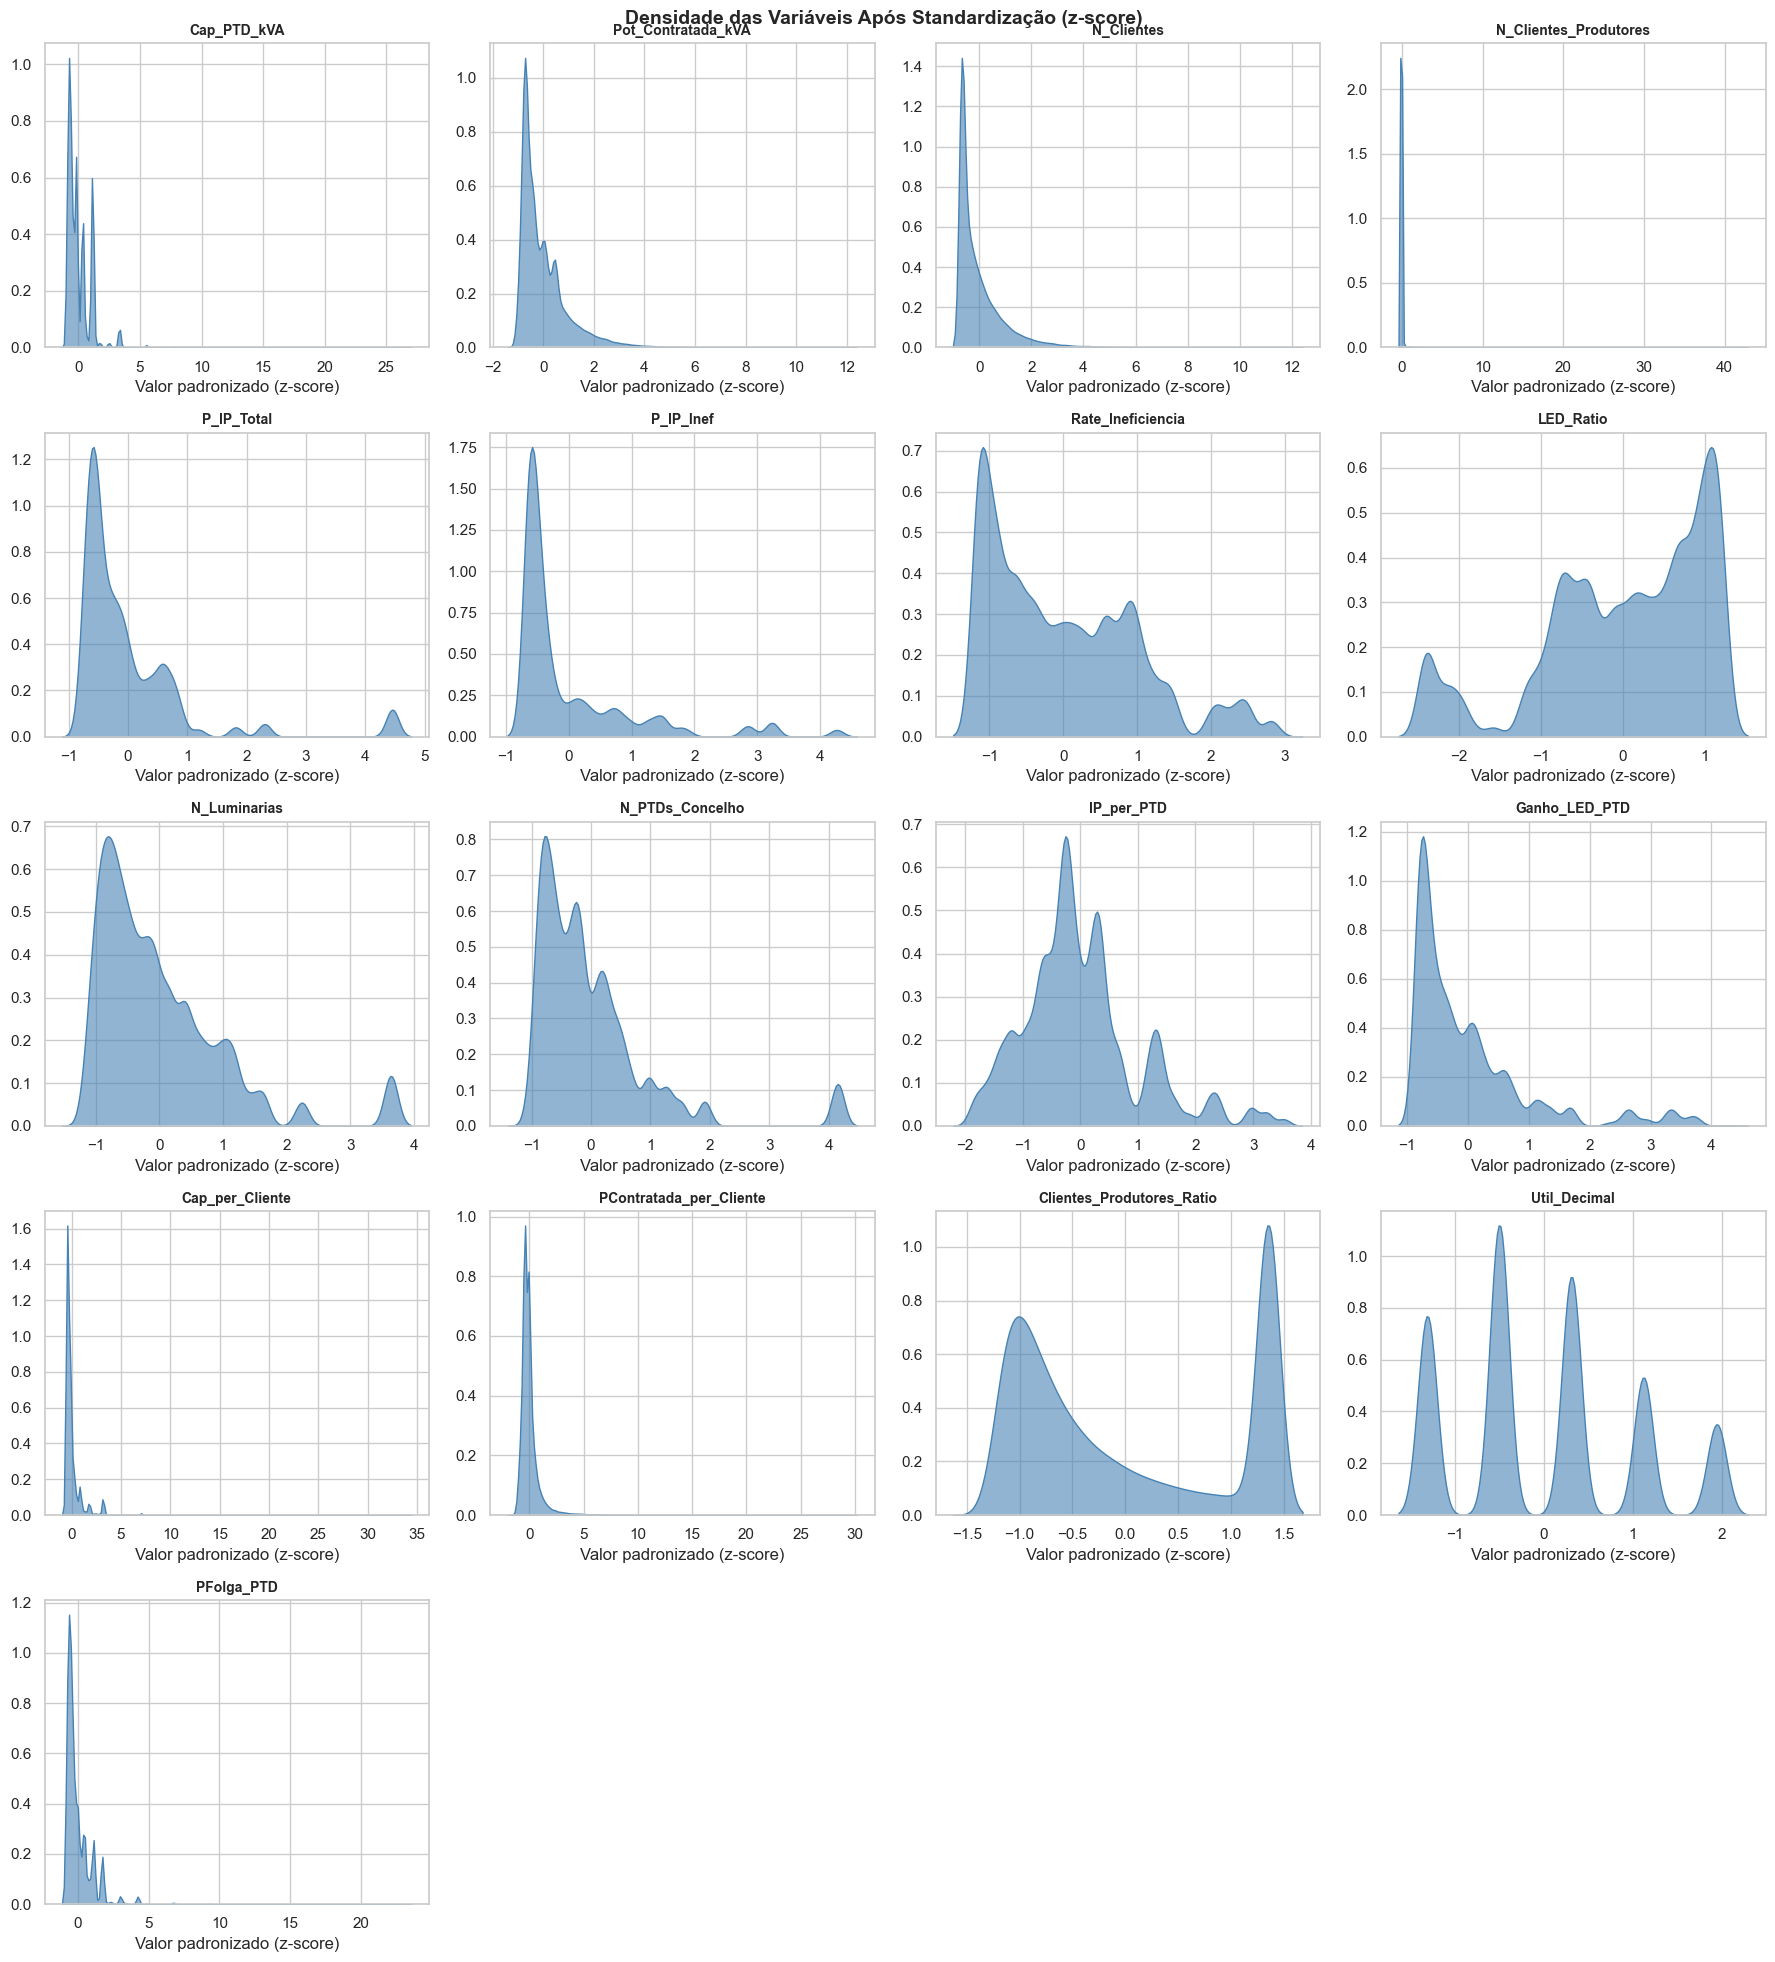

Variáveis representadas: 17
['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'N_Clientes_Produtores', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_PTDs_Concelho', 'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Clientes_Produtores_Ratio', 'Util_Decimal', 'PFolga_PTD']


In [18]:
# Visualização final: distribuição das variáveis numéricas após standardização
cols_ohe = [c for c in df_model.columns if 'Tipo Construtivo' in c or c.startswith('Distrito_')]
cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns if c not in cols_ohe]

n = len(cols_numericas)
ncols = 4
nrows = -(-n // ncols)  # arredonda para cima

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.kdeplot(df_scaled[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor padronizado (z-score)')
    axes[i].set_ylabel('')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Densidade das Variáveis Após Standardização (z-score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Variáveis representadas: {n}')
print(cols_numericas)

# ANADI – Trabalho Prático 2
## 4.2 Regressão – Previsão de PFolga_PTD
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Prever o valor contínuo da Folga Rede por PTD (PFolga_PTD), métrica que determina a capacidade de um PTD em absorver a mobilidade elétrica.

---
## 0. Imports e Carregamento do Dataset

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import (KFold, cross_val_score, learning_curve,
                                     train_test_split)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import os
from pathlib import Path

# Garante que o diretório de trabalho é o da pasta do notebook (funciona em qualquer PC)
try:
    os.chdir(Path(__vsc_ipynb_file__).parent)
except NameError:
    pass  # Jupyter clássico: lançar a partir da pasta do projeto

sns.set_theme(style='whitegrid')
%matplotlib inline

SEED = 42
np.random.seed(SEED)

# ── Carregar dataset ─────────────────────────────────────────────────────────
df = pd.read_excel('data/PTD_level_dataset.xlsx')
print(f'Dataset carregado: {df.shape[0]:,} registos × {df.shape[1]} variáveis')

Dataset carregado: 72,027 registos × 32 variáveis


---
## Pré-processamento (replicado do 4.1)

In [20]:
df_clean = df.copy()

# Remover colunas com >95% de missing
df_clean.drop(columns=['Pot_Geracao_kW', 'Geracao_per_Cliente'], inplace=True)

# Remover registos sem PFolga_PTD / Util
util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)

# Imputação de Pot_Contratada_kVA e PContratada_per_Cliente
for col in ['Pot_Contratada_kVA', 'PContratada_per_Cliente']:
    df_clean[col] = df_clean.groupby('Tipo Construtivo')[col].transform(
        lambda x: x.fillna(x.median())
    )

# One-Hot Encoding – Tipo Construtivo
raras = df_clean['Tipo Construtivo'].value_counts()
raras = raras[raras < 0.02 * len(df_clean)].index
df_clean['Tipo Construtivo'] = df_clean['Tipo Construtivo'].replace(raras, 'Outros')
df_clean = pd.get_dummies(df_clean, columns=['Tipo Construtivo'], drop_first=True, dtype=int)

# Variáveis ordinais / binárias
ordem_util = {'0%-19%': 1, '20%-39%': 2, '40%-59%': 3, '60%-79%': 4, '80%-99%': 5, '+100%': 6}
df_clean['Util_Ordinal'] = df_clean['Nível de Utilização [%]'].map(ordem_util)
df_clean['PTD_Saturado'] = (df_clean['Util_Decimal'] >= 0.8).astype(int)

# Remover colunas irrelevantes / data leakage
pot_col   = [c for c in df_clean.columns if 'instalada' in c][0]
cod_col   = [c for c in df_clean.columns if 'digo' in c][0]
coord_col = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Distrito', 'Concelho', 'CodDistritoConcelho', cod_col, coord_col,
    pot_col, util_col, 'Nível de Utilização [%]',
    'PVE_PTD', 'N_PTDs_Concelho', 'N_Clientes_Produtores',
    'Clientes_Produtores_Ratio', 'N_Luminarias', 'N_Lampadas',
    'IP_Inef_per_PTD', 'P_IP_Inef', 'D_PTD', 'D_PTD_LED'
]
cols_remover = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_remover)

print(f'Dataset para modelação: {df_model.shape[0]:,} registos × {df_model.shape[1]} variáveis')
print(f'Missing values: {df_model.isnull().sum().sum()}')

Dataset para modelação: 68,963 registos × 21 variáveis


Missing values: 0


---
## 1. Diagrama de Correlação com PFolga_PTD

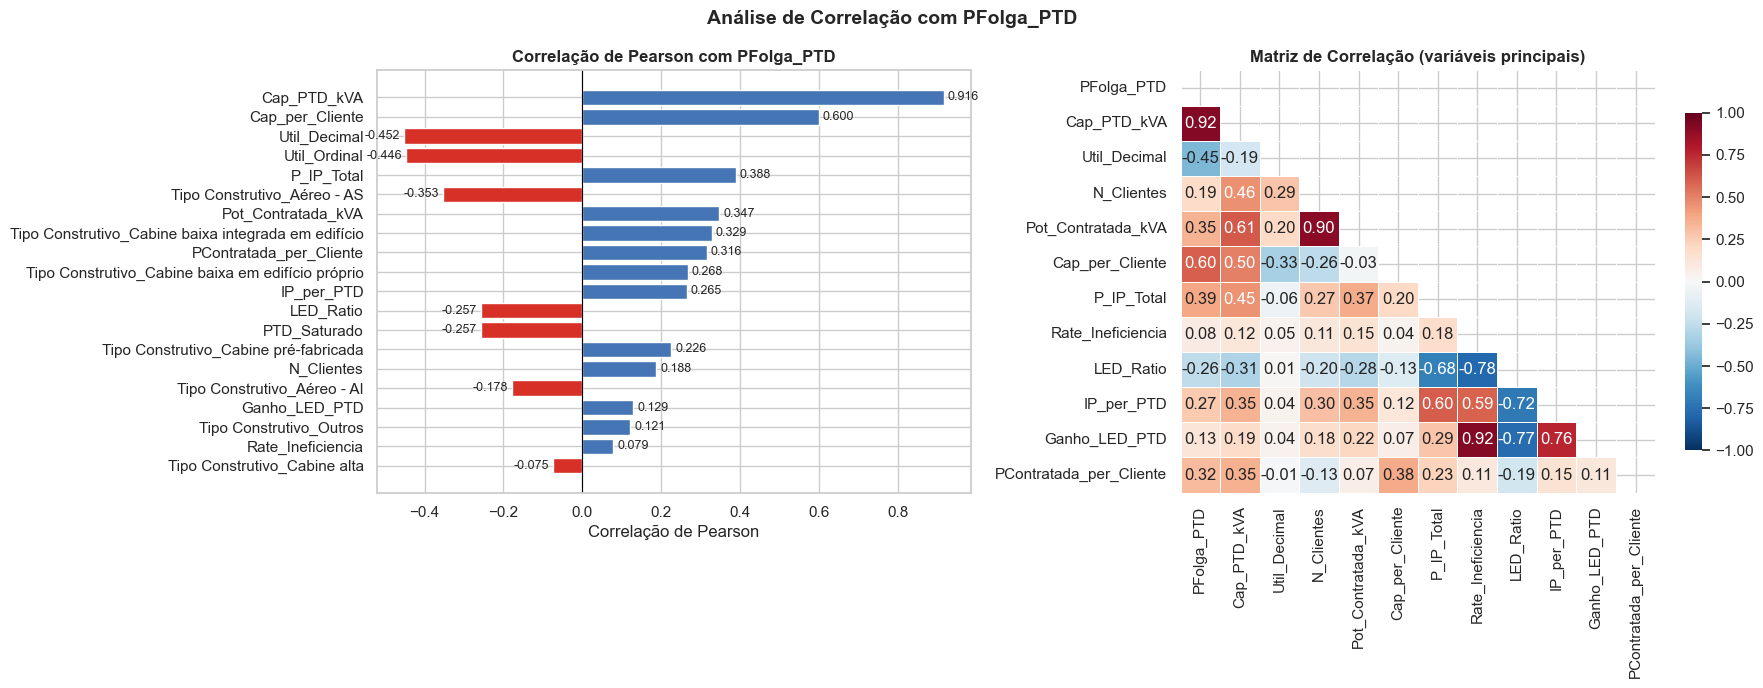

Top 5 variáveis mais correlacionadas com PFolga_PTD:
Cap_PTD_kVA        0.915892
Cap_per_Cliente    0.599554
Util_Decimal      -0.452051
Util_Ordinal      -0.446497
P_IP_Total         0.388398


In [21]:
# Correlação de Pearson com PFolga_PTD, ordenada por valor absoluto
num_cols = df_model.select_dtypes(include=np.number).columns.tolist()
corr_target = df_model[num_cols].corr()['PFolga_PTD'].drop('PFolga_PTD').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barplot de correlação com PFolga_PTD
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_target.values]
axes[0].barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlação de Pearson')
axes[0].set_title('Correlação de Pearson com PFolga_PTD', fontweight='bold')
for i, v in enumerate(corr_target.values[::-1]):
    axes[0].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Heatmap da matriz de correlação completa (variáveis numéricas principais)
vars_heatmap = ['PFolga_PTD', 'Cap_PTD_kVA', 'Util_Decimal', 'N_Clientes',
                'Pot_Contratada_kVA', 'Cap_per_Cliente', 'P_IP_Total',
                'Rate_Ineficiencia', 'LED_Ratio', 'IP_per_PTD',
                'Ganho_LED_PTD', 'PContratada_per_Cliente']
vars_heatmap = [c for c in vars_heatmap if c in df_model.columns]
corr_matrix = df_model[vars_heatmap].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de Correlação (variáveis principais)', fontweight='bold')

plt.suptitle('Análise de Correlação com PFolga_PTD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variáveis mais correlacionadas com PFolga_PTD:')
print(corr_target.head(5).to_string())

**Interpretação:**  
As variáveis com maior correlação positiva com `PFolga_PTD` são `Cap_PTD_kVA` e `Pot_Contratada_kVA`, o que é expectável: PTDs com maior capacidade instalada tendem a ter maior folga disponível. A variável `Util_Decimal` apresenta correlação negativa forte — quanto maior o nível de utilização do PTD, menor a folga de potência disponível para absorver veículos elétricos. **Nota:** apesar de `Util_Decimal` ser a variável mais correlacionada, é excluída da modelação por constituir *data leakage* — é derivada da mesma utilização que determina `PFolga_PTD`, pelo que a sua inclusão produziria resultados artificialmente perfeitos. Variáveis relacionadas com iluminação pública (`LED_Ratio`, `P_IP_Total`, `Rate_Ineficiencia`) mostram correlações fracas a moderadas, sugerindo que o impacto da eficiência em LED na folga é limitado quando comparado com a capacidade instalada.

---
## 2. Regressão Linear Simples (k-Fold Cross-Validation)

In [22]:
# Preparação: escolha da variável explicativa
# Cap_PTD_kVA tem a maior correlação positiva com PFolga_PTD (r ≈ 0.96)
# e interpretação direta: a capacidade instalada do PTD determina o headroom disponível.

X_simple = df_model[['Cap_PTD_kVA']].values
y = df_model['PFolga_PTD'].values

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

mae_scores, rmse_scores, r2_scores = [], [], []
all_coef, all_intercept = [], []

for train_idx, test_idx in kf.split(X_simple):
    X_tr, X_te = X_simple[train_idx], X_simple[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae_scores.append(mean_absolute_error(y_te, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_te, y_pred)))
    r2_scores.append(r2_score(y_te, y_pred))
    all_coef.append(model.coef_[0])
    all_intercept.append(model.intercept_)

coef_mean   = np.mean(all_coef)
interc_mean = np.mean(all_intercept)

print('='*55)
print('  REGRESSÃO LINEAR SIMPLES  (10-Fold CV)')
print('='*55)
print(f'  Variável explicativa: Cap_PTD_kVA')
print(f'  MAE  (média ± std): {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}')
print(f'  RMSE (média ± std): {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}')
print(f'  R²   (média ± std): {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}')
print('='*55)

  REGRESSÃO LINEAR SIMPLES  (10-Fold CV)
  Variável explicativa: Cap_PTD_kVA
  MAE  (média ± std): 50.7496 ± 0.3797
  RMSE (média ± std): 74.9728 ± 0.6679
  R²   (média ± std): 0.8385 ± 0.0074


### 2a. Função Linear Resultante

In [23]:
print('Função de regressão linear simples (média dos coeficientes dos 10 folds):')
print(f'  PFolga_PTD = {coef_mean:.6f} × Cap_PTD_kVA + {interc_mean:.4f}')
print()
print('Interpretação:')
print(f'  Por cada kVA adicional de capacidade instalada (Cap_PTD_kVA),')
print(f'  a folga de potência disponível aumenta em ≈ {coef_mean:.4f} kVA.')
print(f'  A ordenada na origem ({interc_mean:.2f} kVA) representa a folga teórica')
print(f'  para um PTD com capacidade zero (sem significado prático direto).')

Função de regressão linear simples (média dos coeficientes dos 10 folds):
  PFolga_PTD = 0.593750 × Cap_PTD_kVA + -32.1892

Interpretação:
  Por cada kVA adicional de capacidade instalada (Cap_PTD_kVA),
  a folga de potência disponível aumenta em ≈ 0.5937 kVA.
  A ordenada na origem (-32.19 kVA) representa a folga teórica
  para um PTD com capacidade zero (sem significado prático direto).


### 2b. Reta de Regressão e Diagrama de Dispersão

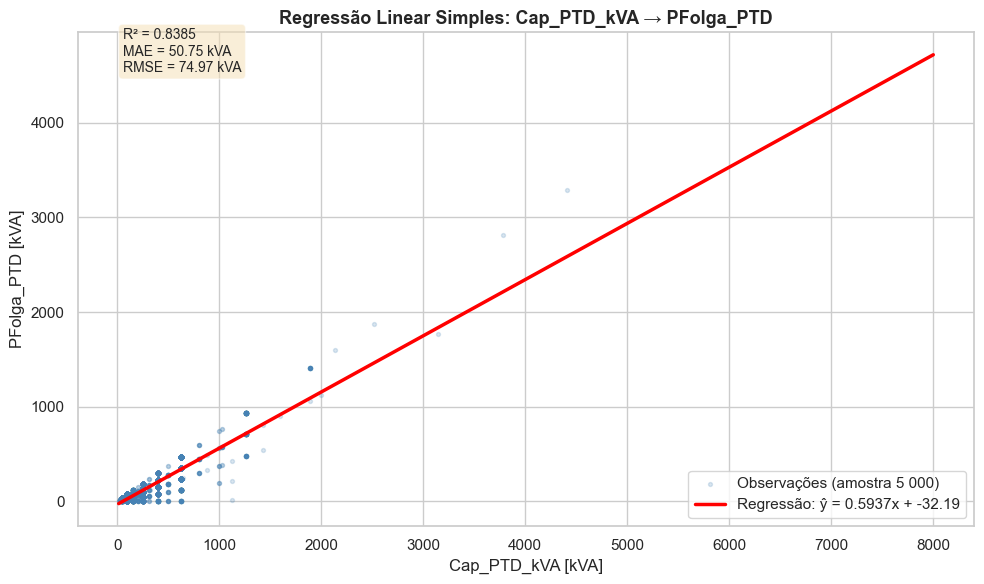

In [24]:
# Ajuste final no dataset completo para visualização
model_simple = LinearRegression()
model_simple.fit(X_simple, y)

x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
y_line = model_simple.predict(x_line)

# Amostra aleatória para scatter (evitar overplotting)
sample_idx = np.random.choice(len(X_simple), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_simple[sample_idx], y[sample_idx],
           alpha=0.2, s=8, color='steelblue', label='Observações (amostra 5 000)')
ax.plot(x_line, y_line, color='red', linewidth=2.5,
        label=f'Regressão: ŷ = {model_simple.coef_[0]:.4f}x + {model_simple.intercept_:.2f}')

ax.set_xlabel('Cap_PTD_kVA [kVA]', fontsize=12)
ax.set_ylabel('PFolga_PTD [kVA]', fontsize=12)
ax.set_title('Regressão Linear Simples: Cap_PTD_kVA → PFolga_PTD', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.text(0.05, 0.92,
        f'R² = {np.mean(r2_scores):.4f}\nMAE = {np.mean(mae_scores):.2f} kVA\nRMSE = {np.mean(rmse_scores):.2f} kVA',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig_regressao_simples.png', dpi=150, bbox_inches='tight')
plt.show()

### 2c. MAE e RMSE do Modelo

In [25]:
print('Métricas do modelo de Regressão Linear Simples (10-Fold CV):')
print(f'  MAE  = {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f} kVA')
print(f'  R²   = {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}')
print()
print(f'Média de PFolga_PTD: {y.mean():.2f} kVA  |  Desvio-padrão: {y.std():.2f} kVA')
print(f'MAE relativo: {np.mean(mae_scores)/y.mean()*100:.1f}% da média da variável alvo')

Métricas do modelo de Regressão Linear Simples (10-Fold CV):
  MAE  = 50.7496 ± 0.3797 kVA
  RMSE = 74.9728 ± 0.6679 kVA
  R²   = 0.8385 ± 0.0074

Média de PFolga_PTD: 147.98 kVA  |  Desvio-padrão: 186.76 kVA
MAE relativo: 34.3% da média da variável alvo


---
## 3. Modelos de Regressão (k-Fold CV)
### Preparação dos dados

In [26]:
# Features e target
# Util_Decimal, PTD_Saturado e Util_Ordinal são derivadas diretamente da utilização
# do PTD, que determina PFolga_PTD — incluí-las causaria data leakage
LEAKAGE = ['Util_Decimal', 'PTD_Saturado', 'Util_Ordinal']
feature_cols = [c for c in df_model.columns if c not in ['PFolga_PTD'] + LEAKAGE]
X = df_model[feature_cols].values
y = df_model['PFolga_PTD'].values

# Colunas não normalizadas (apenas OHE após remover binárias/ordinais)
cols_ohe = [c for c in feature_cols if 'Tipo Construtivo' in c]
cols_nao_norm = cols_ohe
idx_nao_norm = [feature_cols.index(c) for c in cols_nao_norm if c in feature_cols]
idx_norm     = [i for i in range(len(feature_cols)) if i not in idx_nao_norm]

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

print(f'Features: {len(feature_cols)}')
print(f'Registos: {X.shape[0]:,}')
print(f'Target (PFolga_PTD): média={y.mean():.2f}, std={y.std():.2f}')
print(f'Excluídas por leakage: {LEAKAGE}')

Features: 17
Registos: 68,963
Target (PFolga_PTD): média=147.98, std=186.76
Excluídas por leakage: ['Util_Decimal', 'PTD_Saturado', 'Util_Ordinal']


### 3a. Regressão Linear Múltipla

In [27]:
mae_mlr, rmse_mlr = [], []

for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae_mlr.append(mean_absolute_error(y_te, y_pred))
    rmse_mlr.append(np.sqrt(mean_squared_error(y_te, y_pred)))

print('Regressão Linear Múltipla (10-Fold CV):')
print(f'  MAE  = {np.mean(mae_mlr):.4f} ± {np.std(mae_mlr):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_mlr):.4f} ± {np.std(rmse_mlr):.4f} kVA')

Regressão Linear Múltipla (10-Fold CV):
  MAE  = 33.7776 ± 0.3836 kVA
  RMSE = 52.4093 ± 1.4257 kVA


### 3b. Árvore de Regressão

In [28]:
from sklearn.model_selection import GridSearchCV

# Otimização dos hiperparâmetros via GridSearch com CV interno (3-fold)
param_grid_dt = {
    'max_depth':        [3, 5, 7, 10, 15],
    'min_samples_leaf': [20, 50, 100]
}
dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=SEED),
    param_grid_dt,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
dt_gs.fit(X, y)
best_dt_params = dt_gs.best_params_
print(f'Melhores hiperparâmetros (GridSearch): {best_dt_params}')
print(f'MAE CV interno: {-dt_gs.best_score_:.4f} kVA')

# Avaliação final com os melhores hiperparâmetros em 10-fold CV externo
mae_dt, rmse_dt = [], []
best_dt = None
best_dt_mae = np.inf

for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X[train_idx].copy(), X[test_idx].copy()
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

    model = DecisionTreeRegressor(**best_dt_params, random_state=SEED)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae_fold = mean_absolute_error(y_te, y_pred)
    mae_dt.append(mae_fold)
    rmse_dt.append(np.sqrt(mean_squared_error(y_te, y_pred)))

    if mae_fold < best_dt_mae:
        best_dt_mae = mae_fold
        best_dt = model

print(f'\nÁrvore de Regressão (10-Fold CV, params={best_dt_params}):')
print(f'  MAE  = {np.mean(mae_dt):.4f} ± {np.std(mae_dt):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_dt):.4f} ± {np.std(rmse_dt):.4f} kVA')

Melhores hiperparâmetros (GridSearch): {'max_depth': 10, 'min_samples_leaf': 20}
MAE CV interno: 32.1724 kVA



Árvore de Regressão (10-Fold CV, params={'max_depth': 10, 'min_samples_leaf': 20}):
  MAE  = 32.0676 ± 0.4652 kVA
  RMSE = 52.9288 ± 2.0651 kVA


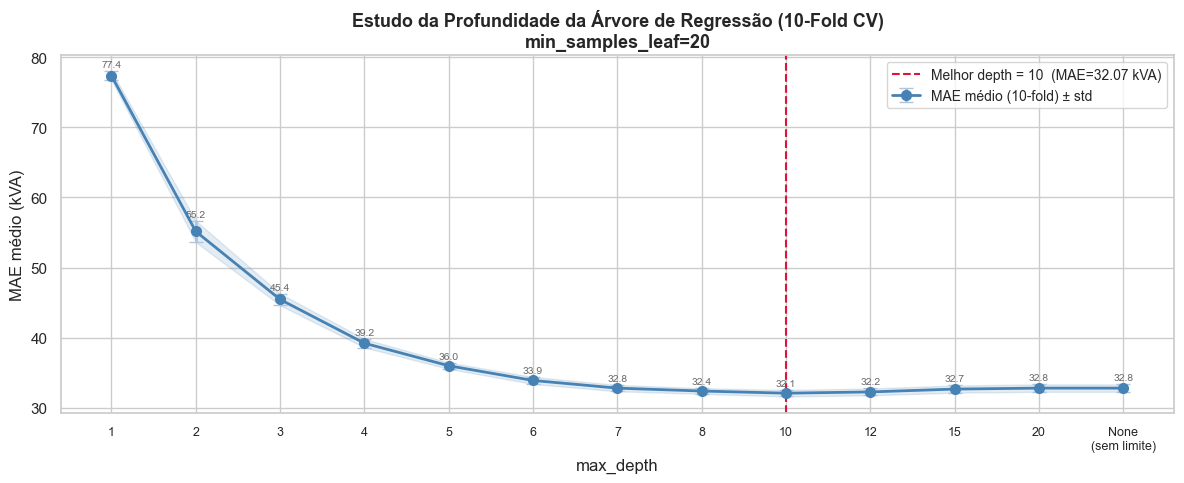

Melhor max_depth: 10  →  MAE = 32.0676 ± 0.4652 kVA
(valor seleccionado pelo GridSearch: 10)


In [29]:
# Estudo da profundidade óptima da árvore de regressão (10-Fold CV)
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
depth_labels = [str(d) if d is not None else 'None\n(sem limite)' for d in depths]

mae_by_depth  = []
rmse_by_depth = []
std_by_depth  = []

for d in depths:
    mae_d = []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx].copy(), X[test_idx].copy()
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
        X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

        m = DecisionTreeRegressor(max_depth=d, min_samples_leaf=best_dt_params['min_samples_leaf'],
                                  random_state=SEED)
        m.fit(X_tr, y_tr)
        mae_d.append(mean_absolute_error(y_te, m.predict(X_te)))

    mae_by_depth.append(np.mean(mae_d))
    std_by_depth.append(np.std(mae_d))
    rmse_by_depth.append(np.mean(mae_d))  # apenas para referência interna

best_idx   = np.argmin(mae_by_depth)
best_depth = depths[best_idx]

fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(range(len(depths)), mae_by_depth, yerr=std_by_depth,
            fmt='o-', color='steelblue', ecolor='lightsteelblue',
            elinewidth=2, capsize=5, linewidth=2, markersize=7,
            label='MAE médio (10-fold) ± std')

ax.axvline(best_idx, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Melhor depth = {best_depth}  (MAE={mae_by_depth[best_idx]:.2f} kVA)')

ax.fill_between(range(len(depths)),
                np.array(mae_by_depth) - np.array(std_by_depth),
                np.array(mae_by_depth) + np.array(std_by_depth),
                alpha=0.15, color='steelblue')

ax.set_xticks(range(len(depths)))
ax.set_xticklabels(depth_labels, fontsize=9)
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('MAE médio (kVA)', fontsize=12)
ax.set_title('Estudo da Profundidade da Árvore de Regressão (10-Fold CV)\n'
             f'min_samples_leaf={best_dt_params["min_samples_leaf"]}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Anotações nos pontos
for i, (mae, std) in enumerate(zip(mae_by_depth, std_by_depth)):
    ax.annotate(f'{mae:.1f}', (i, mae + std + 0.3),
                ha='center', va='bottom', fontsize=7.5, color='dimgray')

plt.tight_layout()
plt.savefig('fig_depth_study_arvore.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Melhor max_depth: {best_depth}  →  MAE = {mae_by_depth[best_idx]:.4f} ± {std_by_depth[best_idx]:.4f} kVA')
print(f'(valor seleccionado pelo GridSearch: {best_dt_params["max_depth"]})')


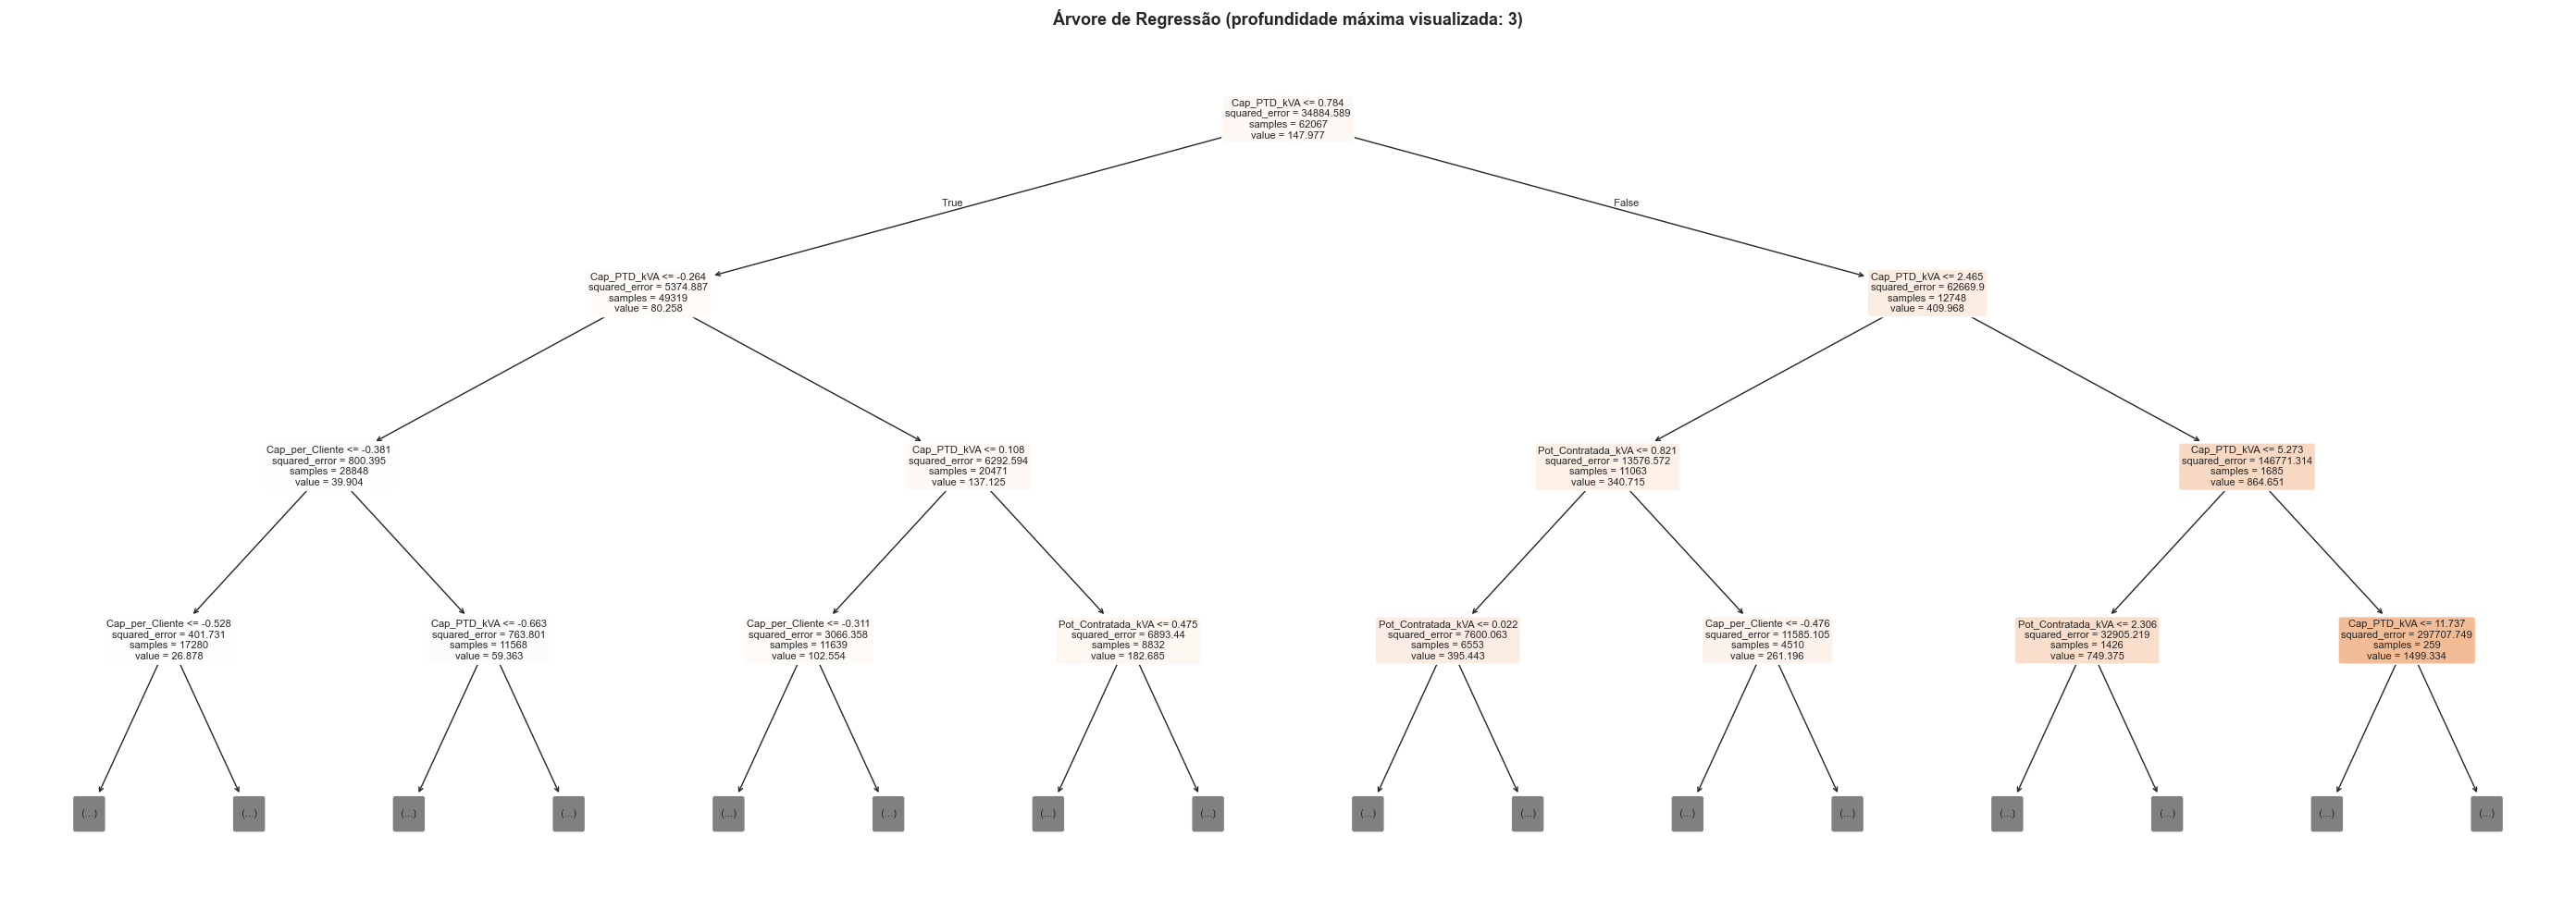


Top 10 variáveis mais importantes (árvore de regressão):
Cap_PTD_kVA                0.916276
Pot_Contratada_kVA         0.054810
Cap_per_Cliente            0.018358
PContratada_per_Cliente    0.006804
LED_Ratio                  0.000924
N_Clientes                 0.000898
IP_per_PTD                 0.000678
P_IP_Total                 0.000615
Rate_Ineficiencia          0.000273
Ganho_LED_PTD              0.000157


In [30]:
# Visualização da árvore de regressão (melhor fold)
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    best_dt, feature_names=feature_cols,
    filled=True, rounded=True, max_depth=3,
    fontsize=8, ax=ax, impurity=True
)
ax.set_title('Árvore de Regressão (profundidade máxima visualizada: 3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_regressao.png', dpi=120, bbox_inches='tight')
plt.show()

# Importância das variáveis
feat_imp = pd.Series(best_dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nTop 10 variáveis mais importantes (árvore de regressão):')
print(feat_imp.head(10).to_string())

### 3c. SVM – Otimização do Kernel

> **Nota metodológica:** O SVR é computacionalmente pesado em datasets grandes (complexidade O(n²–n³)). A otimização do kernel e a avaliação final são realizadas sobre uma amostra aleatória de 10 000 registos (≈14.5% do total). Os resultados são indicativos mas não directamente comparáveis com os dos restantes modelos, treinados na totalidade dos 68 963 registos.

In [31]:
# Por eficiência computacional, usa-se uma amostra estratificada
from sklearn.utils import resample

SAMPLE_SIZE = 10000
idx_sample = np.random.choice(len(X), size=SAMPLE_SIZE, replace=False)
X_svm = X[idx_sample].copy()
y_svm = y[idx_sample].copy()

kernels = ['linear', 'rbf', 'poly']
svm_results = {}

kf_svm = KFold(n_splits=5, shuffle=True, random_state=SEED)

for kernel in kernels:
    mae_k, rmse_k = [], []
    for train_idx, test_idx in kf_svm.split(X_svm):
        X_tr, X_te = X_svm[train_idx].copy(), X_svm[test_idx].copy()
        y_tr, y_te = y_svm[train_idx], y_svm[test_idx]

        scaler = StandardScaler()
        X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
        X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

        svr = SVR(kernel=kernel, C=10, epsilon=0.1)
        svr.fit(X_tr, y_tr)
        y_pred = svr.predict(X_te)

        mae_k.append(mean_absolute_error(y_te, y_pred))
        rmse_k.append(np.sqrt(mean_squared_error(y_te, y_pred)))

    svm_results[kernel] = {
        'MAE':  (np.mean(mae_k),  np.std(mae_k)),
        'RMSE': (np.mean(rmse_k), np.std(rmse_k))
    }
    print(f'  SVR kernel={kernel:<6}: MAE={np.mean(mae_k):.2f} ± {np.std(mae_k):.2f} | RMSE={np.mean(rmse_k):.2f} ± {np.std(rmse_k):.2f}')

best_kernel = min(svm_results, key=lambda k: svm_results[k]['MAE'][0])
print(f'\nMelhor kernel: {best_kernel}')

  SVR kernel=linear: MAE=32.90 ± 1.32 | RMSE=52.96 ± 3.38


  SVR kernel=rbf   : MAE=41.35 ± 1.10 | RMSE=99.63 ± 6.48


  SVR kernel=poly  : MAE=57.94 ± 2.21 | RMSE=114.95 ± 25.53

Melhor kernel: linear


In [32]:
# Avaliação final SVM com melhor kernel em 10-fold (amostra)
mae_svm, rmse_svm = [], []

for train_idx, test_idx in kf.split(X_svm):
    X_tr, X_te = X_svm[train_idx].copy(), X_svm[test_idx].copy()
    y_tr, y_te = y_svm[train_idx], y_svm[test_idx]

    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

    svr = SVR(kernel=best_kernel, C=10, epsilon=0.1)
    svr.fit(X_tr, y_tr)
    y_pred = svr.predict(X_te)

    mae_svm.append(mean_absolute_error(y_te, y_pred))
    rmse_svm.append(np.sqrt(mean_squared_error(y_te, y_pred)))

print(f'SVM (kernel={best_kernel}, 10-Fold CV, amostra {SAMPLE_SIZE}):')
print(f'  MAE  = {np.mean(mae_svm):.4f} ± {np.std(mae_svm):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_svm):.4f} ± {np.std(rmse_svm):.4f} kVA')

SVM (kernel=linear, 10-Fold CV, amostra 10000):
  MAE  = 32.8875 ± 1.9132 kVA
  RMSE = 52.7795 ± 5.5393 kVA


### 3d. Rede Neuronal – Otimização Estruturada

In [33]:
# Preparação: escalar todo o dataset para NN
scaler_nn = StandardScaler()
X_nn = X.copy().astype(float)
X_nn[:, idx_norm] = scaler_nn.fit_transform(X_nn[:, idx_norm])

# Divisão treino / validação para exploração de arquitecturas (80/20)
X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_nn, y, test_size=0.2, random_state=SEED
)

n_features = X_nn.shape[1]
print(f'Treino: {X_tr_nn.shape[0]:,}  |  Validação: {X_val_nn.shape[0]:,}  |  Features: {n_features}')

Treino: 55,170  |  Validação: 13,793  |  Features: 17


In [34]:
# 3 configurações de rede neuronal (MLPRegressor do scikit-learn)
# Cada configuração varia profundidade, neurónios por camada e regularização
configs = [
    {
        'name': 'Config 1 – Shallow (64)',
        'hidden_layer_sizes': (64,),
        'alpha': 0.0,
        'learning_rate_init': 1e-3,
    },
    {
        'name': 'Config 2 – Deep (128-64-32) + L2',
        'hidden_layer_sizes': (128, 64, 32),
        'alpha': 1e-4,
        'learning_rate_init': 1e-3,
    },
    {
        'name': 'Config 3 – Deep (256-128-64) + LR baixa',
        'hidden_layer_sizes': (256, 128, 64),
        'alpha': 0.0,
        'learning_rate_init': 5e-4,
    },
]

histories   = {}
nn_val_mae  = {}
nn_val_rmse = {}

# Variância de y_tr_nn para converter R² de validação em MSE aproximado
y_var = y_tr_nn.var()

for cfg in configs:
    mlp = MLPRegressor(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation='relu',
        solver='adam',
        alpha=cfg['alpha'],
        learning_rate_init=cfg['learning_rate_init'],
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=SEED,
        verbose=False,
    )
    mlp.fit(X_tr_nn, y_tr_nn)

    # validation_scores_ é R² → MSE aprox = (1 - R²) × Var(y)
    histories[cfg['name']] = {
        'train': mlp.loss_curve_,
        'val':   [(1 - s) * y_var for s in mlp.validation_scores_]
    }

    y_pred_val = mlp.predict(X_val_nn)
    nn_val_mae[cfg['name']]  = mean_absolute_error(y_val_nn, y_pred_val)
    nn_val_rmse[cfg['name']] = np.sqrt(mean_squared_error(y_val_nn, y_pred_val))

    print(f"{cfg['name']}: MAE={nn_val_mae[cfg['name']]:.2f}  "
          f"RMSE={nn_val_rmse[cfg['name']]:.2f}  "
          f"Iterações={mlp.n_iter_}")

Config 1 – Shallow (64): MAE=32.02  RMSE=50.53  Iterações=73


Config 2 – Deep (128-64-32) + L2: MAE=31.41  RMSE=49.97  Iterações=57


Config 3 – Deep (256-128-64) + LR baixa: MAE=31.32  RMSE=49.70  Iterações=30


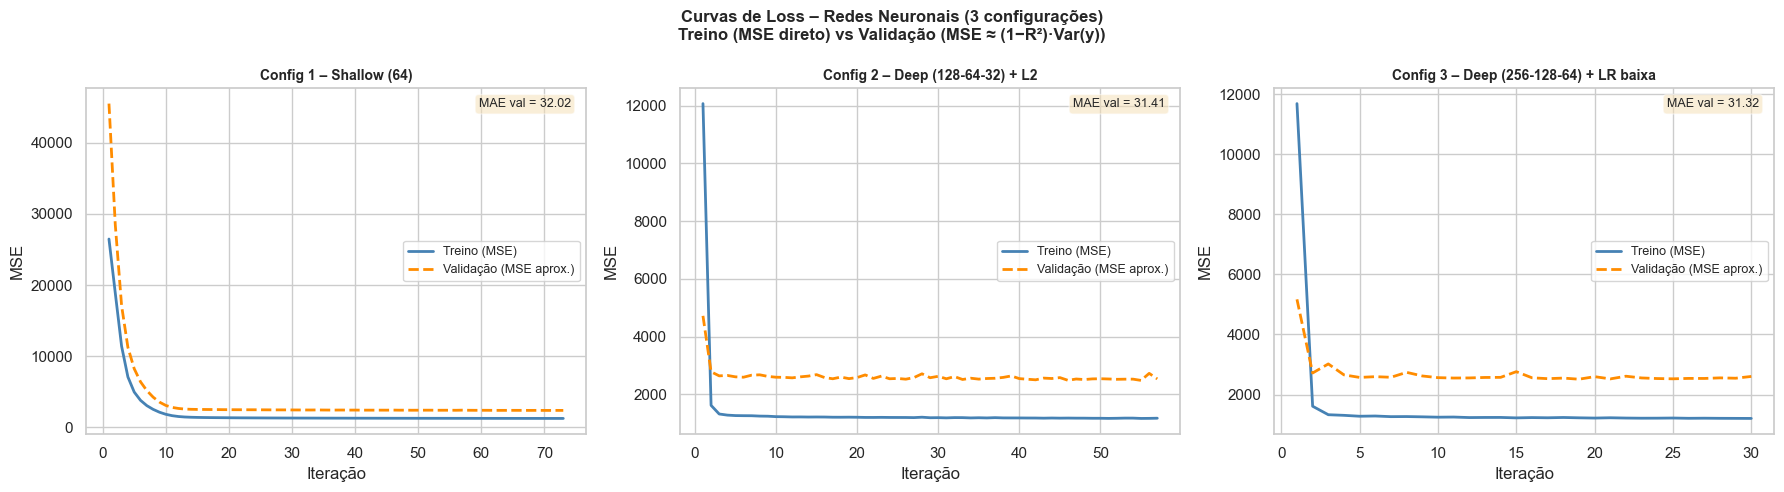

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cfg in zip(axes, configs):
    hist        = histories[cfg['name']]
    train_loss  = hist['train']
    val_loss    = hist['val']
    ep_train    = range(1, len(train_loss) + 1)
    ep_val      = range(1, len(val_loss) + 1)

    ax.plot(ep_train, train_loss, color='steelblue',  linewidth=2, label='Treino (MSE)')
    ax.plot(ep_val,   val_loss,   color='darkorange', linewidth=2,
            linestyle='--', label='Validação (MSE aprox.)')
    ax.set_title(cfg['name'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Iteração')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=9)
    ax.text(0.97, 0.97,
            f"MAE val = {nn_val_mae[cfg['name']]:.2f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Curvas de Loss – Redes Neuronais (3 configurações)\n'
             'Treino (MSE direto) vs Validação (MSE ≈ (1−R²)·Var(y))',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_nn_loss_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussão das curvas de loss:**  
- **Config 1 (Shallow):** Converge rapidamente, mas com apenas uma camada oculta pequena pode apresentar underfitting — MSE de treino elevado e estabilização prematura.  
- **Config 2 (Deep + L2):** A regularização L2 (`alpha=1e-4`) penaliza pesos elevados, reduzindo o risco de overfitting. As curvas de treino e validação tendem a convergir de forma estável.  
- **Config 3 (Deep + LR baixa):** A taxa de aprendizagem mais baixa (5×10⁻⁴) promove convergência mais suave mas pode requerer mais iterações para atingir o mesmo patamar de erro.

**Influência da learning rate:** Uma LR mais baixa melhora a estabilidade da convergência mas aumenta o número de iterações. LR elevada pode oscilar em torno do mínimo.  
**Early stopping:** `n_iter_no_change=10` interrompe o treino quando a `val_loss` não melhora em 10 iterações consecutivas, prevenindo overfitting e reduzindo tempo de computação. Implementado internamente pelo `MLPRegressor` com `early_stopping=True`.

In [36]:
# Melhor configuração de rede neuronal
best_nn_name = min(nn_val_mae, key=nn_val_mae.get)
best_nn_cfg  = next(c for c in configs if c['name'] == best_nn_name)
print(f'Melhor configuração: {best_nn_name}')
print(f'  MAE  (val) = {nn_val_mae[best_nn_name]:.4f} kVA')
print(f'  RMSE (val) = {nn_val_rmse[best_nn_name]:.4f} kVA')

# Avaliação final da melhor NN em 10-Fold CV
mae_nn, rmse_nn = [], []

for train_idx, test_idx in kf.split(X_nn):
    X_tr, X_te = X_nn[train_idx], X_nn[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    mlp_cv = MLPRegressor(
        hidden_layer_sizes=best_nn_cfg['hidden_layer_sizes'],
        activation='relu',
        solver='adam',
        alpha=best_nn_cfg['alpha'],
        learning_rate_init=best_nn_cfg['learning_rate_init'],
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=SEED,
        verbose=False,
    )
    mlp_cv.fit(X_tr, y_tr)
    y_pred = mlp_cv.predict(X_te)
    mae_nn.append(mean_absolute_error(y_te, y_pred))
    rmse_nn.append(np.sqrt(mean_squared_error(y_te, y_pred)))

print(f'\nRede Neuronal (melhor config, 10-Fold CV):')
print(f'  MAE  = {np.mean(mae_nn):.4f} ± {np.std(mae_nn):.4f} kVA')
print(f'  RMSE = {np.mean(rmse_nn):.4f} ± {np.std(rmse_nn):.4f} kVA')

Melhor configuração: Config 3 – Deep (256-128-64) + LR baixa
  MAE  (val) = 31.3190 kVA
  RMSE (val) = 49.7008 kVA



Rede Neuronal (melhor config, 10-Fold CV):
  MAE  = 31.3171 ± 0.5109 kVA
  RMSE = 49.6465 ± 1.5218 kVA


---
## 4. Comparação dos Modelos e Variáveis Mais Relevantes

Comparação de Modelos de Regressão (10-Fold CV):
              Modelo     MAE  MAE_std    RMSE  RMSE_std
       Rede Neuronal 31.3171   0.5109 49.6465    1.5218
 Árvore de Regressão 32.0676   0.4652 52.9288    2.0651
                 SVM 32.8875   1.9132 52.7795    5.5393
Reg. Linear Múltipla 33.7776   0.3836 52.4093    1.4257
 Reg. Linear Simples 50.7496   0.3797 74.9728    0.6679


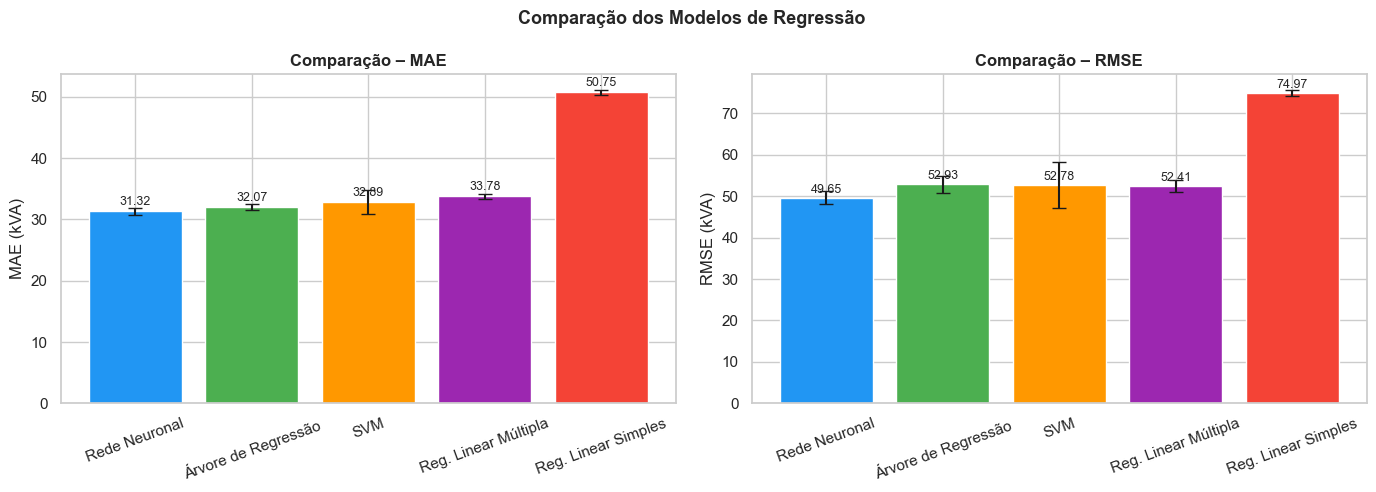

In [37]:
results = pd.DataFrame({
    'Modelo':  ['Reg. Linear Simples', 'Reg. Linear Múltipla', 'Árvore de Regressão', 'SVM', 'Rede Neuronal'],
    'MAE':     [np.mean(mae_scores), np.mean(mae_mlr), np.mean(mae_dt), np.mean(mae_svm), np.mean(mae_nn)],
    'MAE_std': [np.std(mae_scores),  np.std(mae_mlr),  np.std(mae_dt),  np.std(mae_svm),  np.std(mae_nn)],
    'RMSE':    [np.mean(rmse_scores), np.mean(rmse_mlr), np.mean(rmse_dt), np.mean(rmse_svm), np.mean(rmse_nn)],
    'RMSE_std':[np.std(rmse_scores),  np.std(rmse_mlr),  np.std(rmse_dt),  np.std(rmse_svm),  np.std(rmse_nn)]
})
results = results.sort_values('MAE').reset_index(drop=True)

print('Comparação de Modelos de Regressão (10-Fold CV):')
print(results[['Modelo','MAE','MAE_std','RMSE','RMSE_std']].to_string(index=False, float_format='%.4f'))

# Gráfico de comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for ax, metric, metric_std in zip(axes, ['MAE', 'RMSE'], ['MAE_std', 'RMSE_std']):
    bars = ax.bar(results['Modelo'], results[metric],
                  yerr=results[metric_std], capsize=5,
                  color=colors[:len(results)], edgecolor='white')
    ax.set_ylabel(f'{metric} (kVA)')
    ax.set_title(f'Comparação – {metric}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação dos Modelos de Regressão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

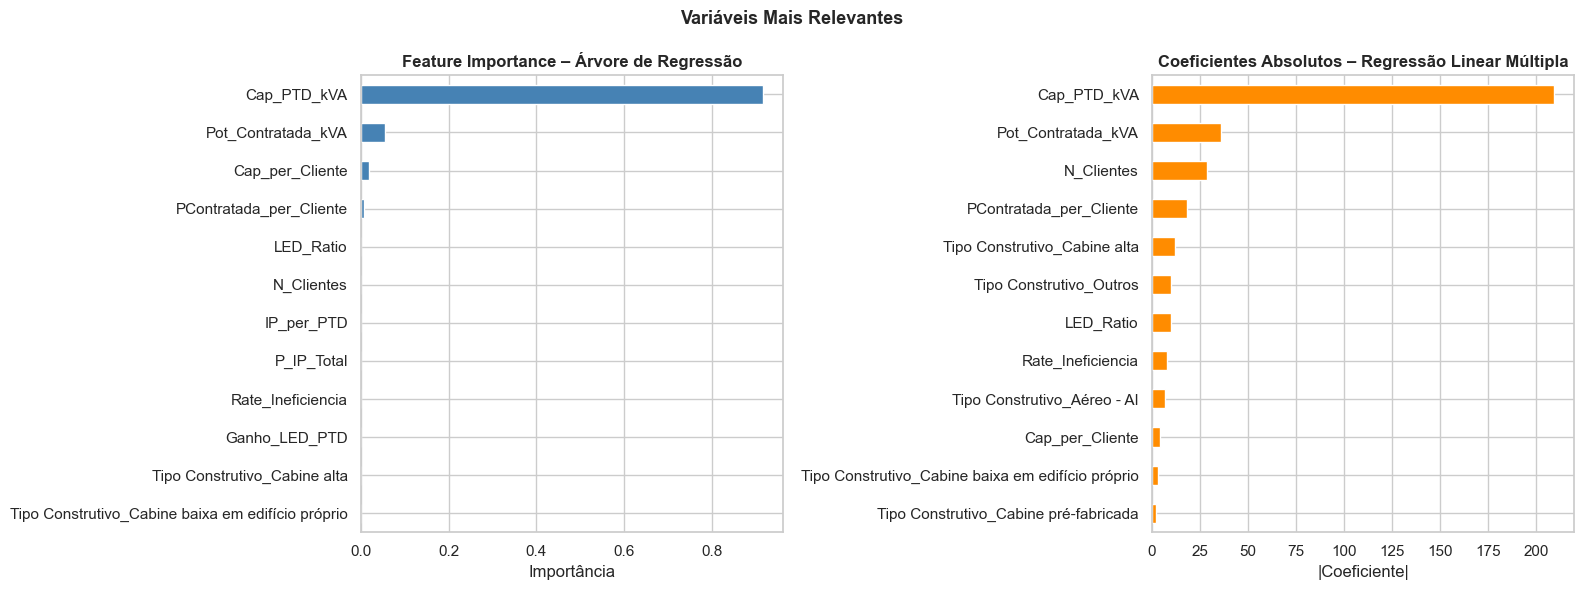

Top 5 variáveis (Árvore): ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'LED_Ratio']
Top 5 variáveis (MLR): ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'PContratada_per_Cliente', 'Tipo Construtivo_Cabine alta']


In [38]:
# Importância das variáveis – Árvore de Regressão (melhor fold)
feat_imp_dt = pd.Series(best_dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Importância dos coeficientes – Regressão Linear Múltipla (último fold)
# Re-treina no dataset completo para coeficientes finais
X_full = X.copy().astype(float)
scaler_full = StandardScaler()
X_full[:, idx_norm] = scaler_full.fit_transform(X_full[:, idx_norm])
mlr_full = LinearRegression().fit(X_full, y)
feat_imp_mlr = pd.Series(np.abs(mlr_full.coef_), index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp_dt.head(12).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance – Árvore de Regressão', fontweight='bold')
axes[0].set_xlabel('Importância')

feat_imp_mlr.head(12).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Coeficientes Absolutos – Regressão Linear Múltipla', fontweight='bold')
axes[1].set_xlabel('|Coeficiente|')

plt.suptitle('Variáveis Mais Relevantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance_reg.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variáveis (Árvore):', feat_imp_dt.head(5).index.tolist())
print('Top 5 variáveis (MLR):', feat_imp_mlr.head(5).index.tolist())

---
## 5. Curvas de Aprendizagem – Dois Melhores Modelos

Os dois melhores modelos: ['Rede Neuronal', 'Árvore de Regressão']


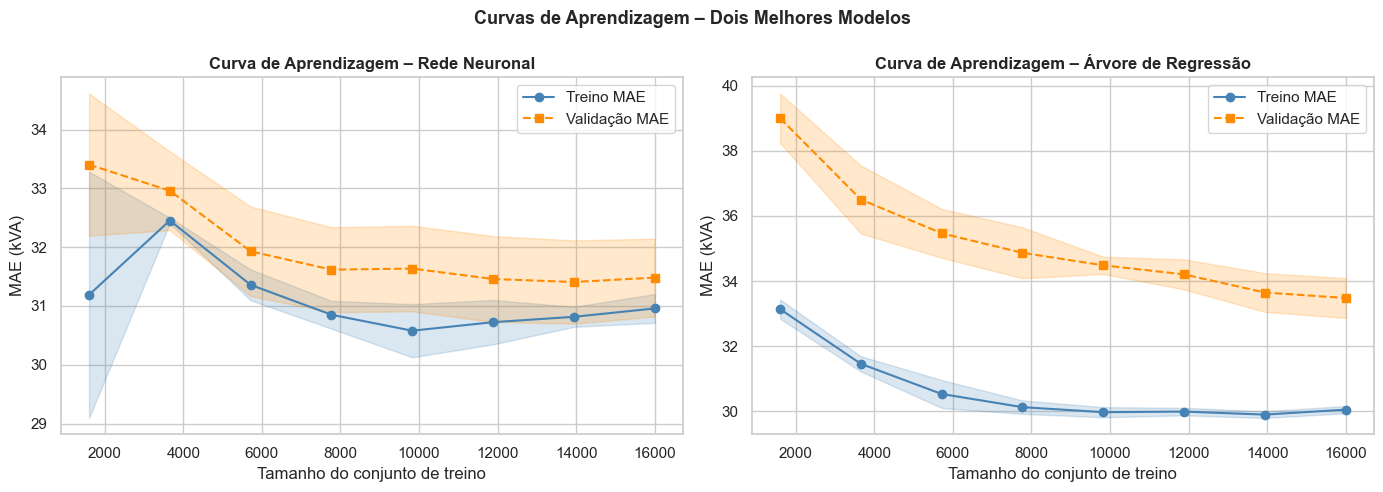

In [39]:
# Identificar os dois melhores modelos (menor MAE)
top2 = results.head(2)['Modelo'].tolist()
print(f'Os dois melhores modelos: {top2}')

# Mapeamento modelo → estimador sklearn
model_map = {
    'Reg. Linear Simples':  LinearRegression(),
    'Reg. Linear Múltipla': LinearRegression(),
    'Árvore de Regressão':  DecisionTreeRegressor(**best_dt_params, random_state=SEED),
    'SVM':                  SVR(kernel=best_kernel, C=10, epsilon=0.1),
    'Rede Neuronal':        MLPRegressor(
                                hidden_layer_sizes=best_nn_cfg['hidden_layer_sizes'],
                                activation='relu', solver='adam',
                                alpha=best_nn_cfg['alpha'],
                                learning_rate_init=best_nn_cfg['learning_rate_init'],
                                max_iter=200, early_stopping=True,
                                n_iter_no_change=10, random_state=SEED),
}

# Para as curvas de aprendizagem usa-se uma amostra (máx 20k) por eficiência
MAX_LC = 20000
idx_lc = np.random.choice(len(X_full), size=min(MAX_LC, len(X_full)), replace=False)
X_lc = X_full[idx_lc]
y_lc = y[idx_lc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, top2):
    if model_name not in model_map:
        ax.set_visible(False)
        continue

    estimator = model_map[model_name]

    # Regressão linear simples usa apenas Cap_PTD_kVA
    if model_name == 'Reg. Linear Simples':
        cap_idx = feature_cols.index('Cap_PTD_kVA')
        X_lc_use = X_lc[:, [cap_idx]]
    else:
        X_lc_use = X_lc

    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_lc_use, y_lc,
        cv=5, scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = -train_scores.mean(axis=1)
    train_std  =  train_scores.std(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    val_std    =  val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue',  label='Treino MAE')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='steelblue')
    ax.plot(train_sizes, val_mean, 's--', color='darkorange', label='Validação MAE')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='darkorange')

    ax.set_xlabel('Tamanho do conjunto de treino')
    ax.set_ylabel('MAE (kVA)')
    ax.set_title(f'Curva de Aprendizagem – {model_name}', fontweight='bold')
    ax.legend()

plt.suptitle('Curvas de Aprendizagem – Dois Melhores Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_learning_curves_reg.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação das Curvas de Aprendizagem:**

- Se a curva de **validação converge para a de treino** à medida que os dados aumentam e ambas atingem um patamar baixo → treino eficiente, sem overfitting nem underfitting significativo.
- Se a curva de **validação se mantém muito acima da de treino** mesmo com muitos dados → **overfitting**: o modelo memoriza o treino mas não generaliza. Soluções: regularização, redução de complexidade, mais dados.
- Se **ambas as curvas estão em patamares elevados** e próximos entre si → **underfitting**: o modelo é demasiado simples para capturar a estrutura dos dados. Soluções: aumentar complexidade ou adicionar features.

A análise das curvas indica se os modelos beneficiariam de mais dados de treino ou se o problema é estrutural (modelo inadequado).

---
## 6. Significância Estatística dos Dois Melhores Modelos

In [40]:
# Recolher erros absolutos por fold para os 2 melhores modelos
# para aplicar testes estatísticos pareados

errors_per_model = {}

for model_name in top2:
    fold_maes = []
    if model_name == 'Reg. Linear Múltipla':
        fold_maes = mae_mlr
    elif model_name == 'Árvore de Regressão':
        fold_maes = mae_dt
    elif model_name == 'Reg. Linear Simples':
        fold_maes = mae_scores
    elif model_name == 'SVM':
        fold_maes = mae_svm
    elif model_name == 'Rede Neuronal':
        fold_maes = mae_nn
    errors_per_model[model_name] = np.array(fold_maes)

m1, m2 = top2[0], top2[1]
e1 = errors_per_model[m1]
e2 = errors_per_model[m2]

print(f'Modelo 1: {m1}')
print(f'  MAE por fold: {np.round(e1, 4)}')
print(f'  Média: {e1.mean():.4f} ± {e1.std():.4f} kVA')
print()
print(f'Modelo 2: {m2}')
print(f'  MAE por fold: {np.round(e2, 4)}')
print(f'  Média: {e2.mean():.4f} ± {e2.std():.4f} kVA')

Modelo 1: Rede Neuronal
  MAE por fold: [31.4388 31.9687 31.2701 31.1893 30.7354 31.69   30.1797 31.2341 31.855
 31.6095]
  Média: 31.3171 ± 0.5109 kVA

Modelo 2: Árvore de Regressão
  MAE por fold: [32.2915 31.5838 32.5073 31.9296 31.8087 32.8365 31.1364 32.3953 31.9637
 32.2232]
  Média: 32.0676 ± 0.4652 kVA


In [41]:
alpha = 0.05

# Verificar normalidade das diferenças (Shapiro-Wilk)
diffs = e1 - e2
stat_sw, p_sw = stats.shapiro(diffs)
print(f'Teste de Shapiro-Wilk nas diferenças MAE:')
print(f'  W = {stat_sw:.4f}, p-value = {p_sw:.4f}')
normal = p_sw > alpha
normalidade = 'normais' if normal else 'não-normais'
print(f'  Diferenças {normalidade} (α=0.05)')
print()

if normal:
    stat_t, p_t = stats.ttest_rel(e1, e2)
    print(f'Teste t pareado:')
    print(f'  t = {stat_t:.4f}, p-value = {p_t:.4f}')
    p_val = p_t
    test_name = 't-test pareado'
else:
    stat_w, p_w = stats.wilcoxon(e1, e2)
    print(f'Teste de Wilcoxon signed-rank:')
    print(f'  W = {stat_w:.4f}, p-value = {p_w:.4f}')
    p_val = p_w
    test_name = 'Wilcoxon signed-rank'

print()
print(f'Conclusão ({test_name}, α=0.05):')
if p_val < alpha:
    melhor = m1 if e1.mean() < e2.mean() else m2
    print(f'  p-value = {p_val:.4f} < 0.05 → diferença estatisticamente significativa.')
    print(f'  O modelo "{melhor}" apresenta desempenho significativamente melhor.')
else:
    print(f'  p-value = {p_val:.4f} >= 0.05 → diferença NAO estatisticamente significativa.')
    print(f'  Nao e possivel concluir que um modelo supera o outro a α=0.05.')

Teste de Shapiro-Wilk nas diferenças MAE:
  W = 0.8455, p-value = 0.0513
  Diferenças normais (α=0.05)

Teste t pareado:
  t = -4.5590, p-value = 0.0014

Conclusão (t-test pareado, α=0.05):
  p-value = 0.0014 < 0.05 → diferença estatisticamente significativa.
  O modelo "Rede Neuronal" apresenta desempenho significativamente melhor.


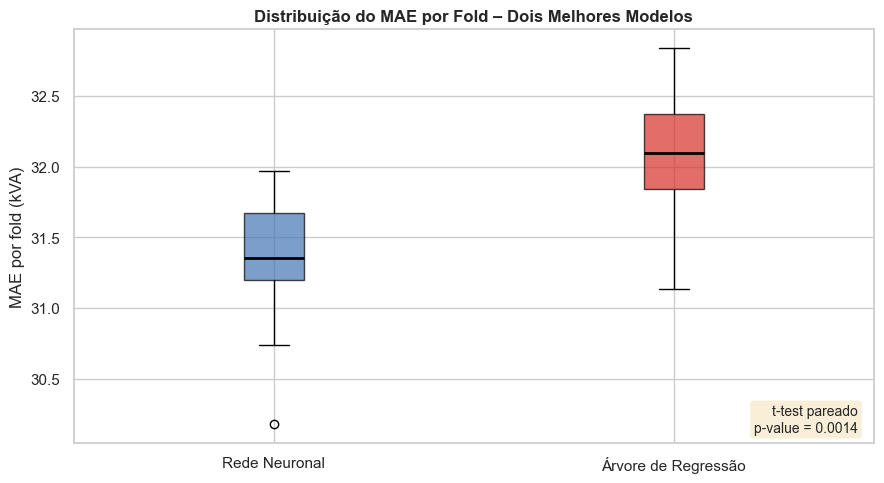

In [42]:
# Visualização: boxplot dos erros por fold
fig, ax = plt.subplots(figsize=(9, 5))

data_plot = [e1, e2]
bp = ax.boxplot(data_plot, labels=[m1, m2], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors_bp = ['#4575b4', '#d73027']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('MAE por fold (kVA)')
ax.set_title('Distribuição do MAE por Fold – Dois Melhores Modelos', fontweight='bold')
ax.text(0.98, 0.02,
        f'{test_name}\np-value = {p_val:.4f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig_stat_test_reg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sumário Final

In [43]:
print('=' * 65)
print('         SUMÁRIO – MODELOS DE REGRESSÃO (PFolga_PTD)')
print('=' * 65)
print(results[['Modelo','MAE','RMSE']].to_string(index=False, float_format='%.4f'))
print('=' * 65)
print(f'\nDois melhores modelos: {top2[0]}  e  {top2[1]}')
print(f'Teste estatístico aplicado: {test_name}')
print(f'p-value = {p_val:.4f}  (α = 0.05)')
if p_val < alpha:
    melhor = m1 if e1.mean() < e2.mean() else m2
    print(f'Modelo com melhor desempenho estatisticamente significativo: {melhor}')
else:
    print('Diferença entre os dois melhores modelos NÃO é estatisticamente significativa.')

print(f'\nVariável mais relevante (Árvore): {feat_imp_dt.index[0]}')
print(f'Variável mais relevante (MLR):    {feat_imp_mlr.index[0]}')

         SUMÁRIO – MODELOS DE REGRESSÃO (PFolga_PTD)
              Modelo     MAE    RMSE
       Rede Neuronal 31.3171 49.6465
 Árvore de Regressão 32.0676 52.9288
                 SVM 32.8875 52.7795
Reg. Linear Múltipla 33.7776 52.4093
 Reg. Linear Simples 50.7496 74.9728

Dois melhores modelos: Rede Neuronal  e  Árvore de Regressão
Teste estatístico aplicado: t-test pareado
p-value = 0.0014  (α = 0.05)
Modelo com melhor desempenho estatisticamente significativo: Rede Neuronal

Variável mais relevante (Árvore): Cap_PTD_kVA
Variável mais relevante (MLR):    Cap_PTD_kVA


# ANADI – Trabalho Prático 2
## 4.3 Classificação – Previsão de utilizRede
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Derivar a variável `utilizRede` (baixo / médio / alto) a partir de `Util_Decimal` e desenvolver modelos de classificação para prever o nível de ocupação da rede.

---
## 0. Imports e Carregamento do Dataset

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (StratifiedKFold, learning_curve,
                                     GridSearchCV, train_test_split)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from scipy import stats
import os
from pathlib import Path

try:
    os.chdir(Path(__vsc_ipynb_file__).parent)
except NameError:
    pass

sns.set_theme(style='whitegrid')
%matplotlib inline

SEED = 42
np.random.seed(SEED)

df = pd.read_excel('data/PTD_level_dataset.xlsx')
print(f'Dataset carregado: {df.shape[0]:,} registos x {df.shape[1]} variaveis')

Dataset carregado: 72,027 registos x 32 variaveis


---
## Pré-processamento (replicado do 4.1)

In [45]:
df_clean = df.copy()

df_clean.drop(columns=['Pot_Geracao_kW', 'Geracao_per_Cliente'], inplace=True)

util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)

for col in ['Pot_Contratada_kVA', 'PContratada_per_Cliente']:
    df_clean[col] = df_clean.groupby('Tipo Construtivo')[col].transform(
        lambda x: x.fillna(x.median())
    )

raras = df_clean['Tipo Construtivo'].value_counts()
raras = raras[raras < 0.02 * len(df_clean)].index
df_clean['Tipo Construtivo'] = df_clean['Tipo Construtivo'].replace(raras, 'Outros')
df_clean = pd.get_dummies(df_clean, columns=['Tipo Construtivo'], drop_first=True, dtype=int)

ordem_util = {'0%-19%': 1, '20%-39%': 2, '40%-59%': 3, '60%-79%': 4, '80%-99%': 5, '+100%': 6}
df_clean['Util_Ordinal'] = df_clean['Nível de Utilização [%]'].map(ordem_util)
df_clean['PTD_Saturado'] = (df_clean['Util_Decimal'] >= 0.8).astype(int)

pot_col   = [c for c in df_clean.columns if 'instalada' in c][0]
cod_col   = [c for c in df_clean.columns if 'digo' in c][0]
coord_col = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Distrito', 'Concelho', 'CodDistritoConcelho', cod_col, coord_col,
    pot_col, util_col, 'Nível de Utilização [%]',
    'PVE_PTD', 'N_PTDs_Concelho', 'N_Clientes_Produtores',
    'Clientes_Produtores_Ratio', 'N_Luminarias', 'N_Lampadas',
    'IP_Inef_per_PTD', 'P_IP_Inef', 'D_PTD', 'D_PTD_LED'
]
cols_remover = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_remover)

print(f'Dataset para modelacao: {df_model.shape[0]:,} registos x {df_model.shape[1]} variaveis')
print(f'Missing values: {df_model.isnull().sum().sum()}')

Dataset para modelacao: 68,963 registos x 21 variaveis
Missing values: 0


---
## 1. Derivação de utilizRede

In [46]:
util = df_model['Util_Decimal']

q33 = util.quantile(1/3)
q67 = util.quantile(2/3)

print('Distribuicao de Util_Decimal:')
print(f'  Media: {util.mean():.4f}  Mediana: {util.median():.4f}')
print(f'  Percentis: p33={q33:.4f} ({q33*100:.1f}%), p67={q67:.4f} ({q67*100:.1f}%)')
print()

# Intervalos fixos (dominio: 0-40%, 40-80%, >80%)
domain_labels = pd.cut(util, bins=[-np.inf, 0.4, 0.8, np.inf],
                       labels=['baixo', 'medio', 'alto'])
dc = domain_labels.value_counts()
print('Intervalos fixos (0-40% / 40-80% / >80%):')
for cls in ['baixo', 'medio', 'alto']:
    print(f'  {cls}: {dc[cls]:,} ({dc[cls]/len(util)*100:.1f}%)')
print(f'  Desequilibrio: {dc.max()/dc.min():.1f}x')
print()

# Quantis (tertis)
quant_labels = pd.qcut(util, q=3, labels=['baixo', 'medio', 'alto'])
qc = quant_labels.value_counts()
print('Quantis (tertis):')
for cls in ['baixo', 'medio', 'alto']:
    print(f'  {cls}: {qc[cls]:,} ({qc[cls]/len(util)*100:.1f}%)')
print(f'  Desequilibrio: {qc.max()/qc.min():.1f}x')

Distribuicao de Util_Decimal:
  Media: 0.5138  Mediana: 0.3900
  Percentis: p33=0.3900 (39.0%), p67=0.5900 (59.0%)

Intervalos fixos (0-40% / 40-80% / >80%):
  baixo: 35,230 (51.1%)
  medio: 27,092 (39.3%)
  alto: 6,641 (9.6%)
  Desequilibrio: 5.3x

Quantis (tertis):
  baixo: 35,230 (51.1%)
  medio: 17,175 (24.9%)
  alto: 16,558 (24.0%)
  Desequilibrio: 2.1x


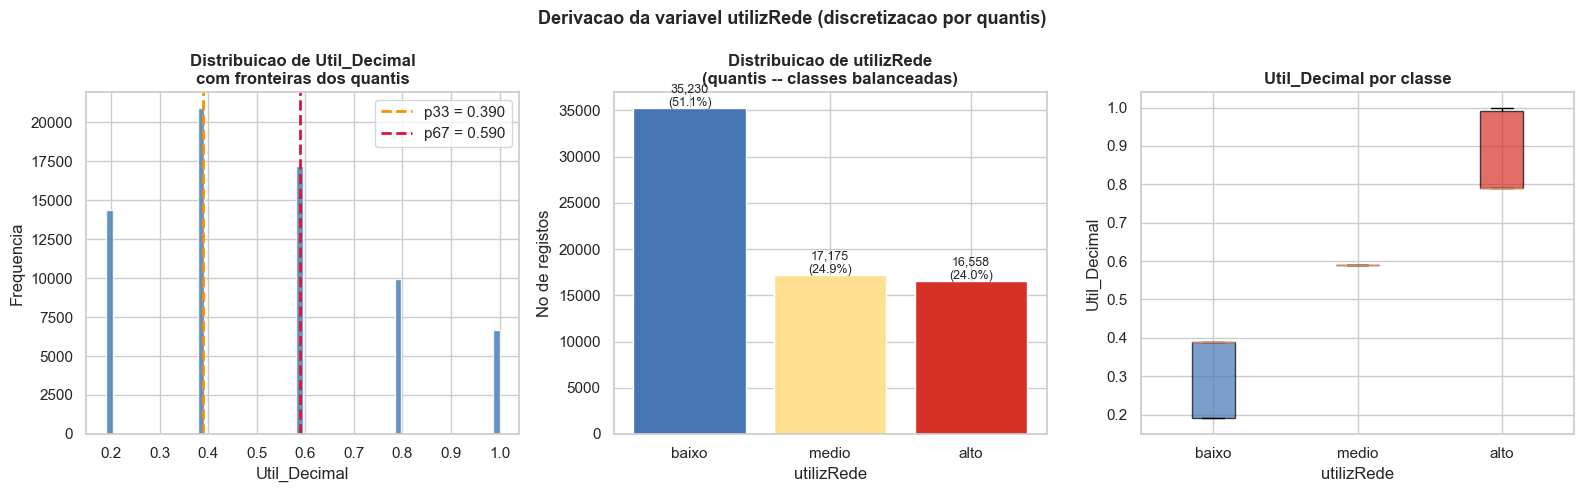

Fronteiras: baixo < 0.3900 <= medio < 0.5900 <= alto


In [47]:
# Discretizacao por quantis (tertis) -- classes balanceadas, melhor para ML
df_model = df_model.copy()
df_model['utilizRede'] = pd.qcut(
    df_model['Util_Decimal'], q=3, labels=['baixo', 'medio', 'alto']
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df_model['Util_Decimal'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(q33, color='darkorange', linestyle='--', linewidth=2, label=f'p33 = {q33:.3f}')
axes[0].axvline(q67, color='crimson',    linestyle='--', linewidth=2, label=f'p67 = {q67:.3f}')
axes[0].set_xlabel('Util_Decimal')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao de Util_Decimal\ncom fronteiras dos quantis', fontweight='bold')
axes[0].legend()

class_counts = df_model['utilizRede'].value_counts().reindex(['baixo', 'medio', 'alto'])
colors_cls = ['#4575b4', '#fee090', '#d73027']
bars = axes[1].bar(class_counts.index, class_counts.values, color=colors_cls, edgecolor='white')
for bar, v in zip(bars, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., v + 200,
                 f'{v:,}\n({v/len(df_model)*100:.1f}%)', ha='center', fontsize=9)
axes[1].set_xlabel('utilizRede')
axes[1].set_ylabel('No de registos')
axes[1].set_title('Distribuicao de utilizRede\n(quantis -- classes balanceadas)', fontweight='bold')

data_box = [df_model.loc[df_model['utilizRede'] == c, 'Util_Decimal'].values
            for c in ['baixo', 'medio', 'alto']]
bp = axes[2].boxplot(data_box, labels=['baixo', 'medio', 'alto'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors_cls):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_xlabel('utilizRede')
axes[2].set_ylabel('Util_Decimal')
axes[2].set_title('Util_Decimal por classe', fontweight='bold')

plt.suptitle('Derivacao da variavel utilizRede (discretizacao por quantis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_utilizRede_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fronteiras: baixo < {q33:.4f} <= medio < {q67:.4f} <= alto')

**Justificação da discretização:**  
Foram comparadas duas estratégias: intervalos fixos de domínio (0–40% / 40–80% / >80%, alinhados com limiares operacionais da rede) e discretização por quantis (tertis). Os intervalos fixos produzem classes fortemente desequilibradas (a classe *baixo* concentra a maioria dos registos), o que enviesaria os modelos para a classe dominante e degradaria a precisão nas classes minoritárias. A discretização por quantis garante classes aproximadamente iguais (~33% cada), proporcionando condições de treino equitativas, métricas de avaliação mais fiáveis e comparação justa entre modelos. A opção pelos quantis é assim preferida do ponto de vista metodológico.

---
## 2. Preparação de Features e Estratégia de Validação

In [48]:
# Util_Decimal e derivadas sao a base do target -> leakage
# PFolga_PTD = Cap - Carga, logo PFolga/Cap = 1 - Util_Decimal -> tambem leakage
LEAKAGE = ['Util_Decimal', 'PTD_Saturado', 'Util_Ordinal', 'PFolga_PTD']
feature_cols = [c for c in df_model.columns if c not in ['utilizRede'] + LEAKAGE]

X = df_model[feature_cols].values.astype(float)

class_map = {'baixo': 0, 'medio': 1, 'alto': 2}
y = df_model['utilizRede'].map(class_map).values
CLASS_NAMES = ['baixo', 'medio', 'alto']

cols_ohe    = [c for c in feature_cols if 'Tipo Construtivo' in c]
idx_nao_norm = [feature_cols.index(c) for c in cols_ohe if c in feature_cols]
idx_norm     = [i for i in range(len(feature_cols)) if i not in idx_nao_norm]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

print(f'Features: {len(feature_cols)}')
print(f'Registos: {X.shape[0]:,}')
print(f'Classes: {CLASS_NAMES}  (codificadas: {list(class_map.values())})')
print(f'Excluidas por leakage: {LEAKAGE}')


def avaliar_fold(y_te, y_pred):
    return {
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'f1_cls':    f1_score(y_te, y_pred, average=None, zero_division=0,
                              labels=[0, 1, 2])
    }


def resumo_metricas(metricas, nome):
    print(f'{nome} (10-Fold CV):')
    for k in ['accuracy', 'precision', 'recall', 'f1']:
        v = metricas[k]
        print(f'  {k:<10}: {np.mean(v):.4f} +/- {np.std(v):.4f}')
    f1_cls = np.mean(metricas['f1_cls'], axis=0)
    for i, c in enumerate(CLASS_NAMES):
        print(f'  F1 ({c:<5}): {f1_cls[i]:.4f}')

Features: 17
Registos: 68,963
Classes: ['baixo', 'medio', 'alto']  (codificadas: [0, 1, 2])
Excluidas por leakage: ['Util_Decimal', 'PTD_Saturado', 'Util_Ordinal', 'PFolga_PTD']


---
## 3. Modelos de Classificação (10-Fold Stratified CV)
### 3a. Árvore de Decisão

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth':        [3, 5, 7, 10, 15],
    'min_samples_leaf': [20, 50, 100]
}
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid_dt, cv=3, scoring='f1_weighted', n_jobs=-1
)
dt_gs.fit(X, y)
best_dt_params = dt_gs.best_params_
print(f'Melhores hiperparametros (GridSearch): {best_dt_params}')
print(f'F1 CV interno: {dt_gs.best_score_:.4f}')

metricas_dt = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'f1_cls': []}
best_dt = None
best_dt_f1 = 0.0

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X[train_idx].copy(), X[test_idx].copy()
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])

    clf = DecisionTreeClassifier(**best_dt_params, random_state=SEED)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    m = avaliar_fold(y_te, y_pred)
    for k in metricas_dt:
        metricas_dt[k].append(m[k] if k != 'f1_cls' else m['f1_cls'])

    if m['f1'] > best_dt_f1:
        best_dt_f1 = m['f1']
        best_dt = clf

print()
resumo_metricas(metricas_dt, 'Arvore de Decisao')

Melhores hiperparametros (GridSearch): {'max_depth': 10, 'min_samples_leaf': 50}
F1 CV interno: 0.6916



Arvore de Decisao (10-Fold CV):
  accuracy  : 0.7015 +/- 0.0042
  precision : 0.6902 +/- 0.0061
  recall    : 0.7015 +/- 0.0042
  f1        : 0.6927 +/- 0.0056
  F1 (baixo): 0.8168
  F1 (medio): 0.4648
  F1 (alto ): 0.6650


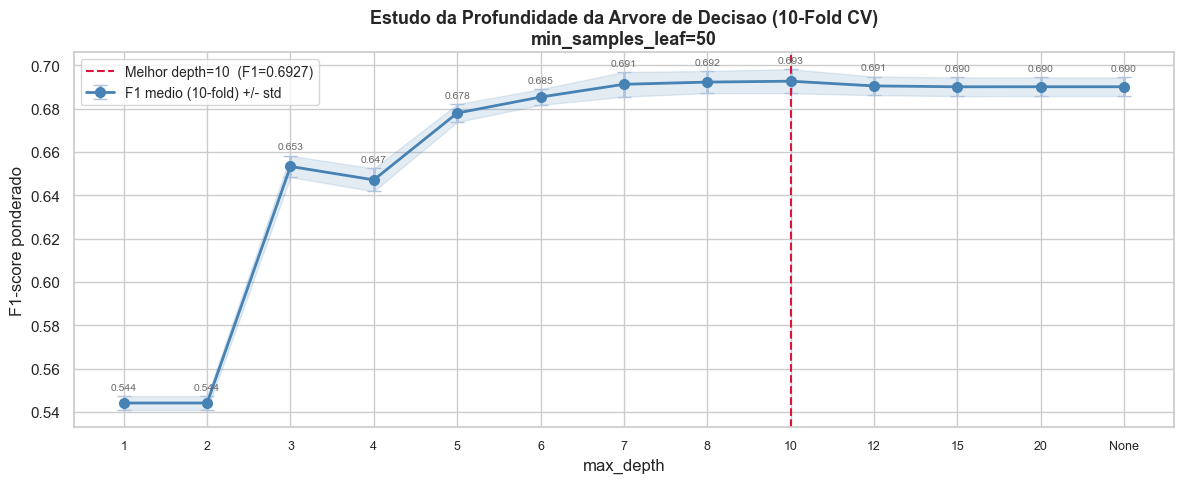

GridSearch escolheu max_depth=10  | Melhor no estudo: depth=10


In [50]:
# Estudo da profundidade optima (10-Fold CV)
depths       = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
depth_labels = [str(d) if d is not None else 'None' for d in depths]
f1_by_depth  = []
std_by_depth = []

for d in depths:
    f1_d = []
    for tr, te in skf.split(X, y):
        X_tr, X_te = X[tr].copy(), X[te].copy()
        scaler = StandardScaler()
        X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
        X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])
        m = DecisionTreeClassifier(max_depth=d,
                                   min_samples_leaf=best_dt_params['min_samples_leaf'],
                                   random_state=SEED)
        m.fit(X_tr, y[tr])
        f1_d.append(f1_score(y[te], m.predict(X_te), average='weighted', zero_division=0))
    f1_by_depth.append(np.mean(f1_d))
    std_by_depth.append(np.std(f1_d))

best_idx_d = np.argmax(f1_by_depth)

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(range(len(depths)), f1_by_depth, yerr=std_by_depth,
            fmt='o-', color='steelblue', ecolor='lightsteelblue',
            elinewidth=2, capsize=5, linewidth=2, markersize=7,
            label='F1 medio (10-fold) +/- std')
ax.axvline(best_idx_d, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Melhor depth={depths[best_idx_d]}  (F1={f1_by_depth[best_idx_d]:.4f})')
ax.fill_between(range(len(depths)),
                np.array(f1_by_depth) - np.array(std_by_depth),
                np.array(f1_by_depth) + np.array(std_by_depth),
                alpha=0.15, color='steelblue')
ax.set_xticks(range(len(depths)))
ax.set_xticklabels(depth_labels, fontsize=9)
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('F1-score ponderado', fontsize=12)
ax.set_title(f'Estudo da Profundidade da Arvore de Decisao (10-Fold CV)\n'
             f'min_samples_leaf={best_dt_params["min_samples_leaf"]}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for i, (f, s) in enumerate(zip(f1_by_depth, std_by_depth)):
    ax.annotate(f'{f:.3f}', (i, f + s + 0.002),
                ha='center', va='bottom', fontsize=7.5, color='dimgray')
plt.tight_layout()
plt.savefig('fig_dt_depth_study_cls.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'GridSearch escolheu max_depth={best_dt_params["max_depth"]}  '
      f'| Melhor no estudo: depth={depths[best_idx_d]}')

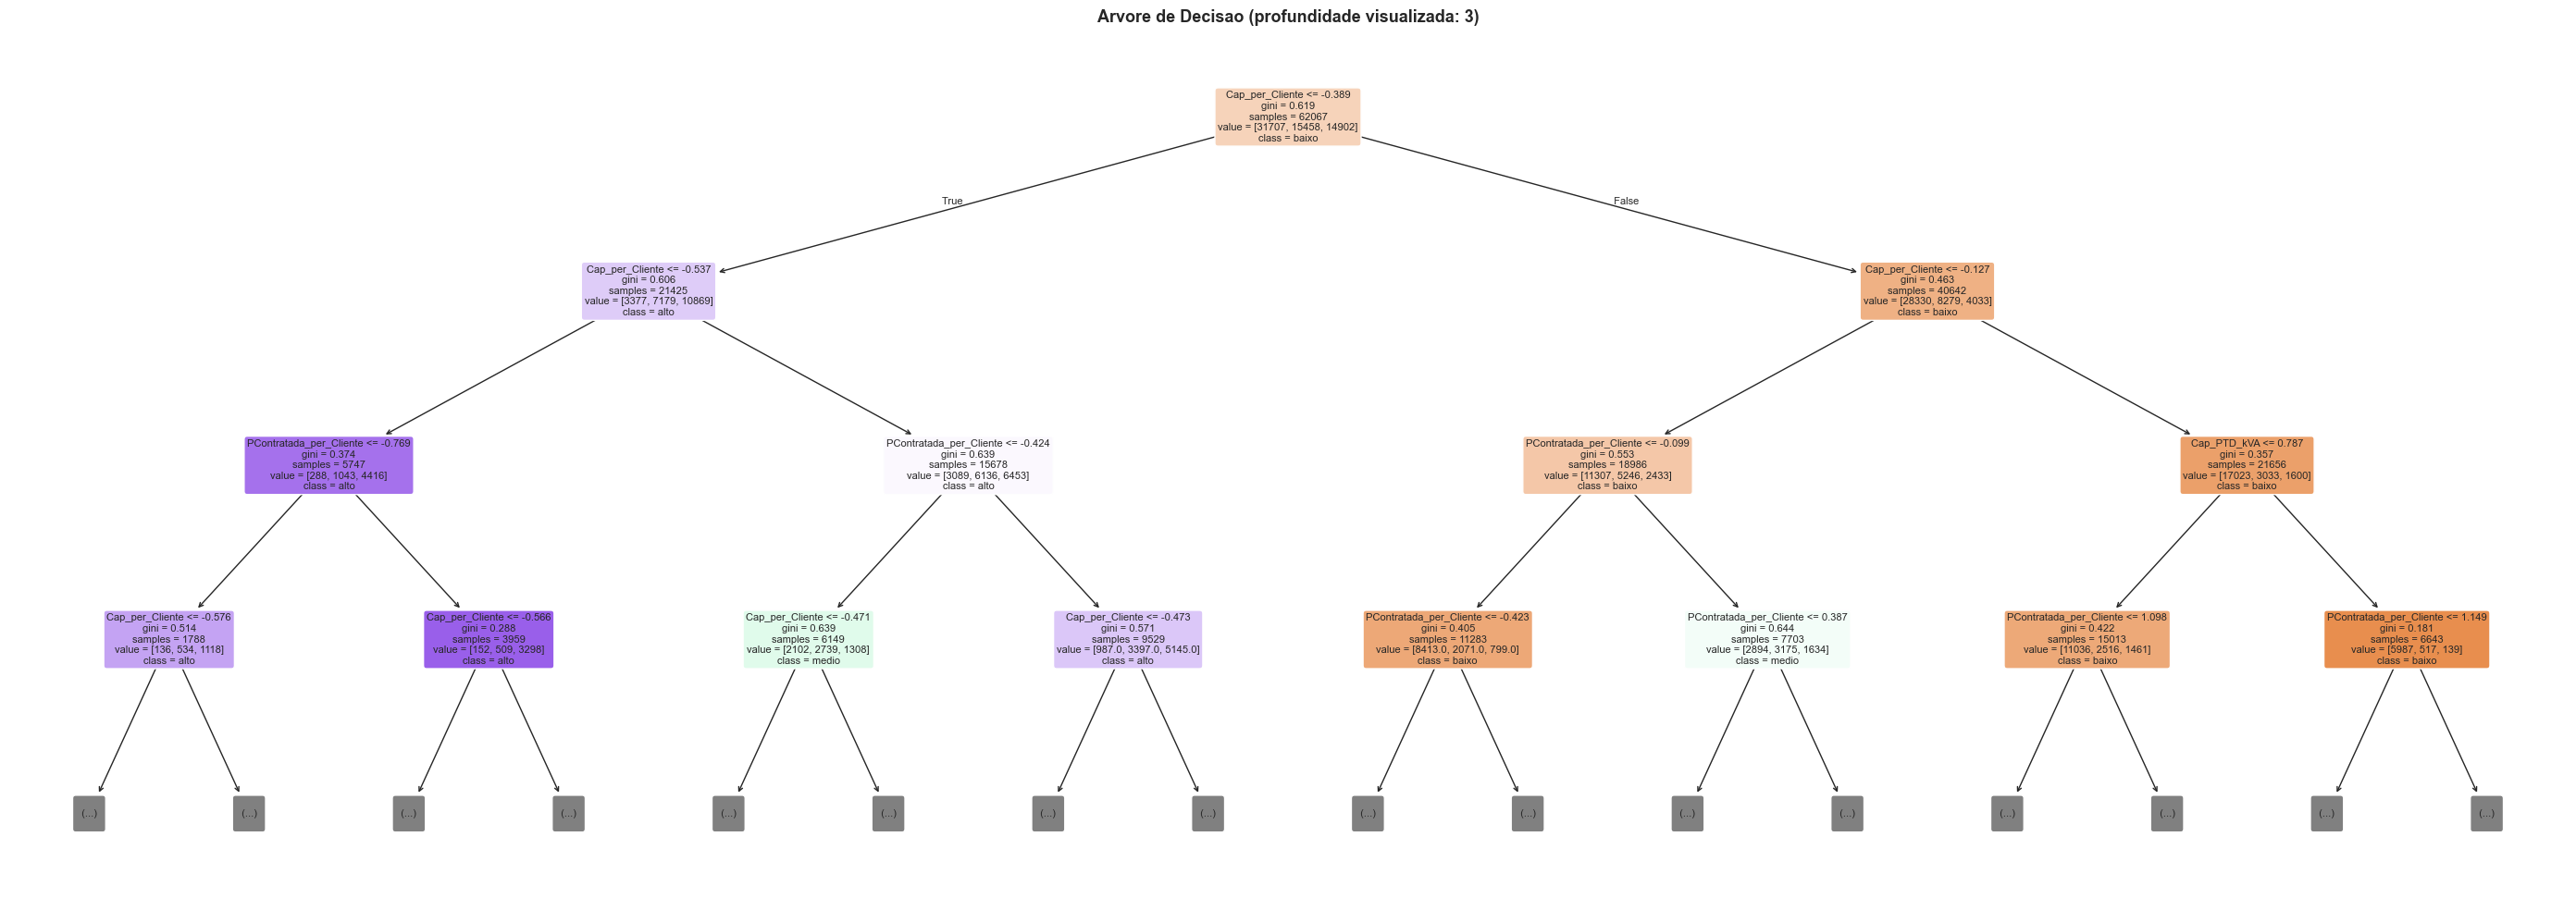

In [51]:
# Visualizacao da arvore de decisao (melhor fold, profundidade maxima 3)
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(best_dt, feature_names=feature_cols,
          class_names=CLASS_NAMES, filled=True, rounded=True,
          max_depth=3, fontsize=8, ax=ax, impurity=True)
ax.set_title('Arvore de Decisao (profundidade visualizada: 3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_decisao_cls.png', dpi=120, bbox_inches='tight')
plt.show()

### 3b. Rede Neuronal – Otimização Estruturada

Config 1 - Shallow (64): F1=0.7033  Iter=37


Config 2 - Deep (128-64-32) + L2: F1=0.7046  Iter=19


Config 3 - Deep (256-128-64) + LR baixa: F1=0.7081  Iter=29


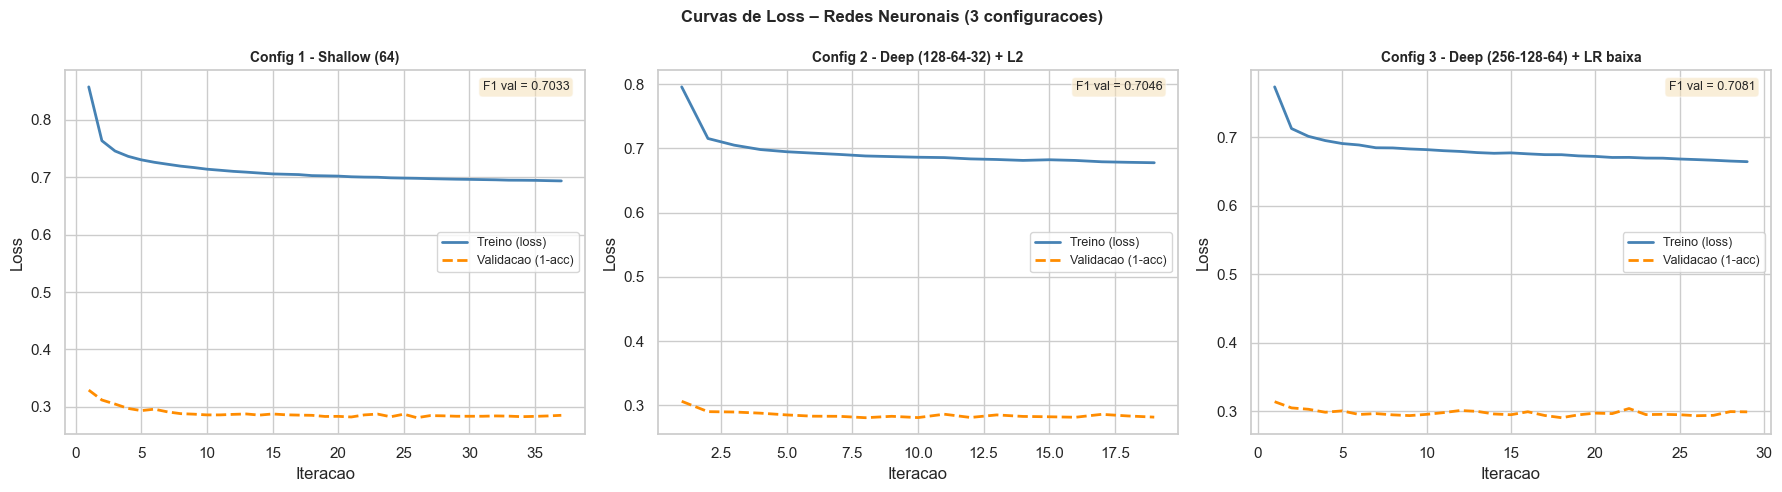

In [52]:
# Pre-escalar para exploracao de configuracoes (80/20 estratificado)
scaler_nn = StandardScaler()
X_nn = X.copy()
X_nn[:, idx_norm] = scaler_nn.fit_transform(X_nn[:, idx_norm])

X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_nn, y, test_size=0.2, random_state=SEED, stratify=y
)

configs = [
    {'name': 'Config 1 - Shallow (64)',          'hidden_layer_sizes': (64,),        'alpha': 0.0,  'learning_rate_init': 1e-3},
    {'name': 'Config 2 - Deep (128-64-32) + L2', 'hidden_layer_sizes': (128, 64, 32),'alpha': 1e-4, 'learning_rate_init': 1e-3},
    {'name': 'Config 3 - Deep (256-128-64) + LR baixa', 'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0, 'learning_rate_init': 5e-4},
]

histories  = {}
nn_val_f1  = {}

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation='relu', solver='adam',
        alpha=cfg['alpha'],
        learning_rate_init=cfg['learning_rate_init'],
        max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=10,
        random_state=SEED, verbose=False,
    )
    mlp.fit(X_tr_nn, y_tr_nn)
    histories[cfg['name']] = {
        'train': mlp.loss_curve_,
        'val':   mlp.validation_scores_
    }
    y_pred_val = mlp.predict(X_val_nn)
    nn_val_f1[cfg['name']] = f1_score(y_val_nn, y_pred_val, average='weighted', zero_division=0)
    print(f"{cfg['name']}: F1={nn_val_f1[cfg['name']]:.4f}  Iter={mlp.n_iter_}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cfg in zip(axes, configs):
    hist = histories[cfg['name']]
    ax.plot(range(1, len(hist['train'])+1), hist['train'],
            color='steelblue', linewidth=2, label='Treino (loss)')
    ax.plot(range(1, len(hist['val'])+1), [1-s for s in hist['val']],
            color='darkorange', linewidth=2, linestyle='--', label='Validacao (1-acc)')
    ax.set_title(cfg['name'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Iteracao')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.text(0.97, 0.97, f"F1 val = {nn_val_f1[cfg['name']]:.4f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.suptitle('Curvas de Loss – Redes Neuronais (3 configuracoes)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_nn_loss_cls.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
best_nn_name = max(nn_val_f1, key=nn_val_f1.get)
best_nn_cfg  = next(c for c in configs if c['name'] == best_nn_name)
print(f'Melhor configuracao: {best_nn_name}')

metricas_nn = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'f1_cls': []}

for train_idx, test_idx in skf.split(X_nn, y):
    X_tr, X_te = X_nn[train_idx], X_nn[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    mlp_cv = MLPClassifier(
        hidden_layer_sizes=best_nn_cfg['hidden_layer_sizes'],
        activation='relu', solver='adam',
        alpha=best_nn_cfg['alpha'],
        learning_rate_init=best_nn_cfg['learning_rate_init'],
        max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=10,
        random_state=SEED, verbose=False,
    )
    mlp_cv.fit(X_tr, y_tr)
    y_pred = mlp_cv.predict(X_te)

    m = avaliar_fold(y_te, y_pred)
    for k in metricas_nn:
        metricas_nn[k].append(m[k] if k != 'f1_cls' else m['f1_cls'])

print()
resumo_metricas(metricas_nn, f'Rede Neuronal ({best_nn_name})')

Melhor configuracao: Config 3 - Deep (256-128-64) + LR baixa



Rede Neuronal (Config 3 - Deep (256-128-64) + LR baixa) (10-Fold CV):
  accuracy  : 0.7151 +/- 0.0035
  precision : 0.7052 +/- 0.0058
  recall    : 0.7151 +/- 0.0035
  f1        : 0.7072 +/- 0.0049
  F1 (baixo): 0.8252
  F1 (medio): 0.4892
  F1 (alto ): 0.6821


**Discussão das curvas de loss:**  
- **Config 1 (Shallow):** Uma única camada de 64 neurónios converge rapidamente mas pode atingir underfitting — o modelo é demasiado simples para capturar fronteiras não-lineares entre três classes.  
- **Config 2 (Deep + L2):** A regularização L2 (`alpha=1e-4`) penaliza pesos elevados, reduzindo overfitting em arquiteturas mais profundas. Curvas de treino e validação tendem a convergir de forma estável.  
- **Config 3 (Deep + LR baixa):** A taxa de aprendizagem mais baixa (5×10⁻⁴) origina convergência mais suave mas potencialmente mais lenta.  

**Early stopping** (`n_iter_no_change=10`): interrompe o treino quando a *val_accuracy* não melhora em 10 épocas consecutivas, prevenindo overfitting e reduzindo o tempo de computação. A **learning rate** influencia diretamente a velocidade de convergência: LR alta pode oscilar em torno do mínimo, enquanto LR baixa aumenta a estabilidade mas exige mais iterações.

### 3c. SVM – Otimização do Kernel

> **Nota metodológica:** O SVC é computacionalmente pesado (complexidade O(n²–n³)). A otimização do kernel e a avaliação final são realizadas sobre uma amostra aleatória de 10 000 registos (≈14.5% do total). Os resultados são indicativos mas não diretamente comparáveis com os modelos treinados no dataset completo.

In [54]:
SAMPLE_SVM = 10000
idx_svm = np.random.choice(len(X), size=SAMPLE_SVM, replace=False)
X_svm = X[idx_svm].copy()
y_svm = y[idx_svm].copy()

kernels    = ['linear', 'rbf', 'poly']
svm_scores = {}
skf5       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for kernel in kernels:
    f1_k = []
    for tr, te in skf5.split(X_svm, y_svm):
        X_tr, X_te = X_svm[tr].copy(), X_svm[te].copy()
        scaler = StandardScaler()
        X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
        X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])
        svc = SVC(kernel=kernel, C=10, random_state=SEED)
        svc.fit(X_tr, y_svm[tr])
        f1_k.append(f1_score(y_svm[te], svc.predict(X_te), average='weighted', zero_division=0))
    svm_scores[kernel] = (np.mean(f1_k), np.std(f1_k))
    print(f'  SVC kernel={kernel:<6}: F1={np.mean(f1_k):.4f} +/- {np.std(f1_k):.4f}')

best_kernel = max(svm_scores, key=lambda k: svm_scores[k][0])
print(f'\nMelhor kernel: {best_kernel}')

  SVC kernel=linear: F1=0.6215 +/- 0.0051


  SVC kernel=rbf   : F1=0.6794 +/- 0.0040


  SVC kernel=poly  : F1=0.6526 +/- 0.0119

Melhor kernel: rbf


In [55]:
metricas_svm = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'f1_cls': []}

for tr, te in skf.split(X_svm, y_svm):
    X_tr, X_te = X_svm[tr].copy(), X_svm[te].copy()
    scaler = StandardScaler()
    X_tr[:, idx_norm] = scaler.fit_transform(X_tr[:, idx_norm])
    X_te[:, idx_norm] = scaler.transform(X_te[:, idx_norm])
    svc = SVC(kernel=best_kernel, C=10, random_state=SEED)
    svc.fit(X_tr, y_svm[tr])
    y_pred = svc.predict(X_te)

    m = avaliar_fold(y_svm[te], y_pred)
    for k in metricas_svm:
        metricas_svm[k].append(m[k] if k != 'f1_cls' else m['f1_cls'])

print()
resumo_metricas(metricas_svm, f'SVM (kernel={best_kernel}, amostra {SAMPLE_SVM})')


SVM (kernel=rbf, amostra 10000) (10-Fold CV):
  accuracy  : 0.6917 +/- 0.0160
  precision : 0.6768 +/- 0.0170
  recall    : 0.6917 +/- 0.0160
  f1        : 0.6783 +/- 0.0164
  F1 (baixo): 0.8029
  F1 (medio): 0.4450
  F1 (alto ): 0.6647


### 3d. K-Vizinhos-Mais-Próximos – Otimização do K

> **Nota metodológica:** O KNN com 68 000 registos e 17 features implica elevada complexidade de predição (O(n×d) por instância). A otimização do K e a avaliação final são realizadas sobre uma amostra de 20 000 registos.

  K= 1: F1=0.5942 +/- 0.0075  Acc=0.5938


  K= 3: F1=0.6119 +/- 0.0088  Acc=0.6271


  K= 5: F1=0.6303 +/- 0.0122  Acc=0.6449


  K= 7: F1=0.6347 +/- 0.0119  Acc=0.6504


  K=10: F1=0.6374 +/- 0.0079  Acc=0.6548


  K=15: F1=0.6368 +/- 0.0089  Acc=0.6563


  K=20: F1=0.6347 +/- 0.0084  Acc=0.6552


  K=30: F1=0.6300 +/- 0.0083  Acc=0.6534


  K=50: F1=0.6241 +/- 0.0108  Acc=0.6514

Melhor K: 10  (F1=0.6374)


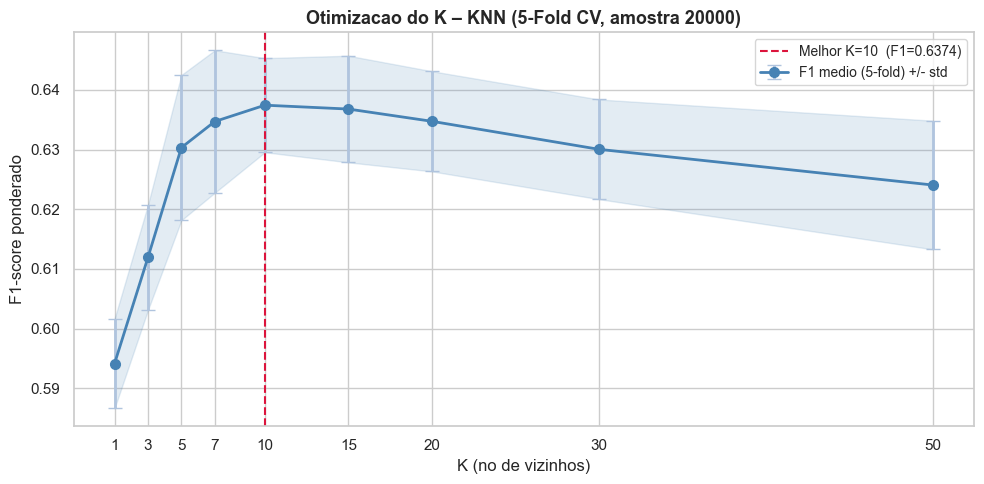

In [56]:
SAMPLE_KNN = 20000
idx_knn    = np.random.choice(len(X), size=SAMPLE_KNN, replace=False)
X_knn_raw  = X[idx_knn].copy()
y_knn      = y[idx_knn].copy()

scaler_knn = StandardScaler()
X_knn      = X_knn_raw.copy()
X_knn[:, idx_norm] = scaler_knn.fit_transform(X_knn_raw[:, idx_norm])

k_values     = [1, 3, 5, 7, 10, 15, 20, 30, 50]
k_f1_means   = []
k_f1_stds    = []
k_acc_means  = []

for k in k_values:
    f1_k, acc_k = [], []
    for tr, te in skf5.split(X_knn, y_knn):
        knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        knn.fit(X_knn[tr], y_knn[tr])
        y_pred_k = knn.predict(X_knn[te])
        f1_k.append(f1_score(y_knn[te], y_pred_k, average='weighted', zero_division=0))
        acc_k.append(accuracy_score(y_knn[te], y_pred_k))
    k_f1_means.append(np.mean(f1_k))
    k_f1_stds.append(np.std(f1_k))
    k_acc_means.append(np.mean(acc_k))
    print(f'  K={k:2d}: F1={np.mean(f1_k):.4f} +/- {np.std(f1_k):.4f}  Acc={np.mean(acc_k):.4f}')

best_k     = k_values[np.argmax(k_f1_means)]
best_k_idx = np.argmax(k_f1_means)
print(f'\nMelhor K: {best_k}  (F1={k_f1_means[best_k_idx]:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(k_values, k_f1_means, yerr=k_f1_stds,
            fmt='o-', color='steelblue', ecolor='lightsteelblue',
            capsize=5, linewidth=2, markersize=7,
            label='F1 medio (5-fold) +/- std')
ax.axvline(best_k, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Melhor K={best_k}  (F1={k_f1_means[best_k_idx]:.4f})')
ax.fill_between(k_values,
                np.array(k_f1_means) - np.array(k_f1_stds),
                np.array(k_f1_means) + np.array(k_f1_stds),
                alpha=0.15, color='steelblue')
ax.set_xlabel('K (no de vizinhos)', fontsize=12)
ax.set_ylabel('F1-score ponderado', fontsize=12)
ax.set_title(f'Otimizacao do K – KNN (5-Fold CV, amostra {SAMPLE_KNN})',
             fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_knn_k_study.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
metricas_knn = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'f1_cls': []}

for tr, te in skf.split(X_knn, y_knn):
    knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
    knn.fit(X_knn[tr], y_knn[tr])
    y_pred = knn.predict(X_knn[te])

    m = avaliar_fold(y_knn[te], y_pred)
    for k in metricas_knn:
        metricas_knn[k].append(m[k] if k != 'f1_cls' else m['f1_cls'])

print()
resumo_metricas(metricas_knn, f'KNN (K={best_k}, amostra {SAMPLE_KNN})')


KNN (K=10, amostra 20000) (10-Fold CV):
  accuracy  : 0.6578 +/- 0.0086
  precision : 0.6401 +/- 0.0102
  recall    : 0.6578 +/- 0.0086
  f1        : 0.6416 +/- 0.0096
  F1 (baixo): 0.7925
  F1 (medio): 0.3967
  F1 (alto ): 0.5727


---
## 4. Comparação dos Modelos

In [58]:
all_metricas = {
    'Arvore de Decisao': metricas_dt,
    'Rede Neuronal':     metricas_nn,
    f'SVM ({best_kernel})': metricas_svm,
    f'KNN (K={best_k})': metricas_knn,
}

rows = []
for nome, m in all_metricas.items():
    f1_cls_m = np.mean(m['f1_cls'], axis=0)
    rows.append({
        'Modelo':      nome,
        'Accuracy':    np.mean(m['accuracy']),
        'Acc_std':     np.std(m['accuracy']),
        'Precision':   np.mean(m['precision']),
        'Prec_std':    np.std(m['precision']),
        'Recall':      np.mean(m['recall']),
        'Rec_std':     np.std(m['recall']),
        'F1':          np.mean(m['f1']),
        'F1_std':      np.std(m['f1']),
        'F1_baixo':    f1_cls_m[0],
        'F1_medio':    f1_cls_m[1],
        'F1_alto':     f1_cls_m[2],
    })

results = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)

print('=' * 75)
print('  COMPARACAO DE MODELOS DE CLASSIFICACAO (10-Fold Stratified CV)')
print('=' * 75)
cols_show = ['Modelo', 'Accuracy', 'Acc_std', 'Precision', 'Prec_std',
             'Recall', 'Rec_std', 'F1', 'F1_std']
print(results[cols_show].to_string(index=False, float_format='%.4f'))
print()
print('F1 por classe:')
print(results[['Modelo', 'F1_baixo', 'F1_medio', 'F1_alto']].to_string(index=False, float_format='%.4f'))

  COMPARACAO DE MODELOS DE CLASSIFICACAO (10-Fold Stratified CV)
           Modelo  Accuracy  Acc_std  Precision  Prec_std  Recall  Rec_std     F1  F1_std
    Rede Neuronal    0.7151   0.0035     0.7052    0.0058  0.7151   0.0035 0.7072  0.0049
Arvore de Decisao    0.7015   0.0042     0.6902    0.0061  0.7015   0.0042 0.6927  0.0056
        SVM (rbf)    0.6917   0.0160     0.6768    0.0170  0.6917   0.0160 0.6783  0.0164
       KNN (K=10)    0.6578   0.0086     0.6401    0.0102  0.6578   0.0086 0.6416  0.0096

F1 por classe:
           Modelo  F1_baixo  F1_medio  F1_alto
    Rede Neuronal    0.8252    0.4892   0.6821
Arvore de Decisao    0.8168    0.4648   0.6650
        SVM (rbf)    0.8029    0.4450   0.6647
       KNN (K=10)    0.7925    0.3967   0.5727


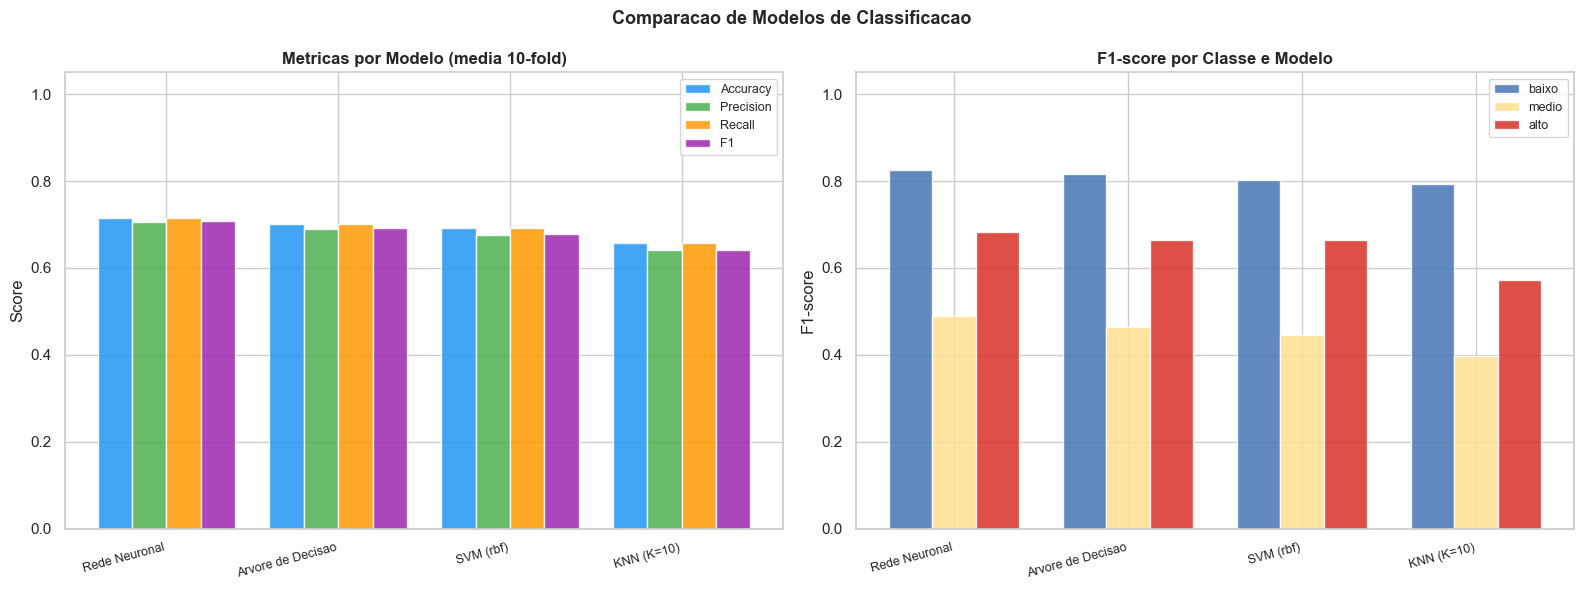

In [59]:
# Grafico de comparacao
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_plot  = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(results))
width = 0.2
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, metric in enumerate(metrics_plot):
    axes[0].bar(x_pos + i * width, results[metric],
                width=width, label=metric, color=colors_bar[i], alpha=0.85)
axes[0].set_xticks(x_pos + width * 1.5)
axes[0].set_xticklabels(results['Modelo'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Metricas por Modelo (media 10-fold)', fontweight='bold')
axes[0].legend(fontsize=9)

# F1 por classe (stacked per model)
x2 = np.arange(len(results))
w2 = 0.25
cls_colors = ['#4575b4', '#fee090', '#d73027']
for i, (cls, col) in enumerate(zip(['F1_baixo', 'F1_medio', 'F1_alto'], cls_colors)):
    axes[1].bar(x2 + i * w2, results[cls], width=w2,
                label=cls.replace('F1_', ''), color=col, alpha=0.85)
axes[1].set_xticks(x2 + w2)
axes[1].set_xticklabels(results['Modelo'], rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('F1-score')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('F1-score por Classe e Modelo', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Comparacao de Modelos de Classificacao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparacao_cls.png', dpi=150, bbox_inches='tight')
plt.show()

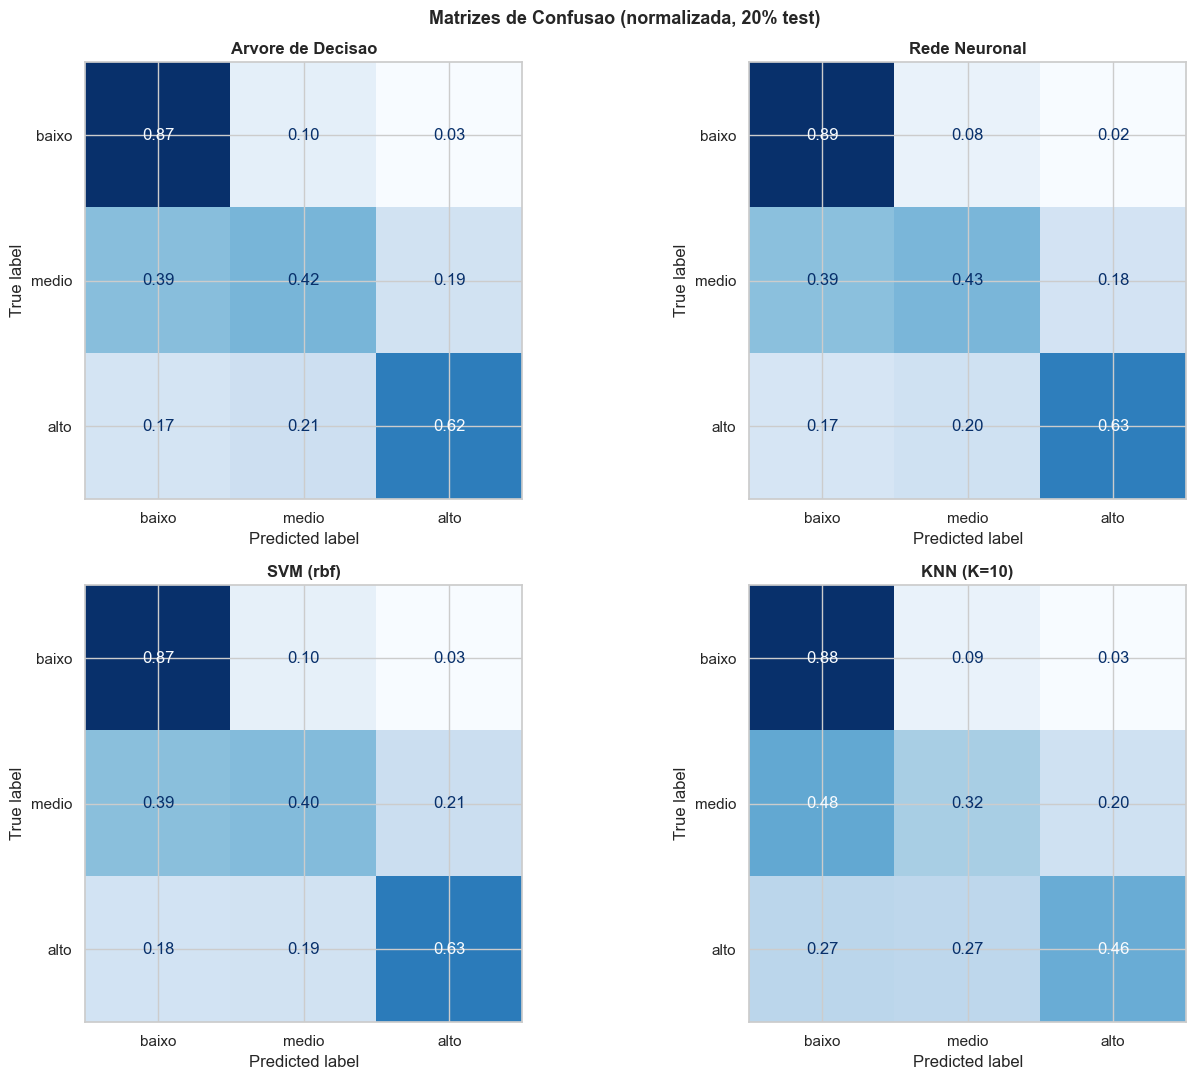

In [60]:
# Matrizes de confusao (ajuste em train/test split para visualizacao)
X_tr_cm, X_te_cm, y_tr_cm, y_te_cm = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
scaler_cm = StandardScaler()
X_tr_sc = X_tr_cm.copy()
X_te_sc = X_te_cm.copy()
X_tr_sc[:, idx_norm] = scaler_cm.fit_transform(X_tr_cm[:, idx_norm])
X_te_sc[:, idx_norm] = scaler_cm.transform(X_te_cm[:, idx_norm])

# Para SVM e KNN usa amostra ja escalada
idx_svm_cm = np.random.choice(len(X_tr_sc), size=min(8000, len(X_tr_sc)), replace=False)
X_svm_tr_cm = X_tr_sc[idx_svm_cm]
y_svm_tr_cm = y_tr_cm[idx_svm_cm]

models_cm = {
    'Arvore de Decisao': (DecisionTreeClassifier(**best_dt_params, random_state=SEED),
                          X_tr_sc, y_tr_cm, X_te_sc, y_te_cm),
    'Rede Neuronal':     (MLPClassifier(
                              hidden_layer_sizes=best_nn_cfg['hidden_layer_sizes'],
                              activation='relu', solver='adam',
                              alpha=best_nn_cfg['alpha'],
                              learning_rate_init=best_nn_cfg['learning_rate_init'],
                              max_iter=300, early_stopping=True,
                              validation_fraction=0.1, n_iter_no_change=10,
                              random_state=SEED),
                          X_tr_sc, y_tr_cm, X_te_sc, y_te_cm),
    f'SVM ({best_kernel})': (SVC(kernel=best_kernel, C=10, random_state=SEED),
                              X_svm_tr_cm, y_svm_tr_cm, X_te_sc, y_te_cm),
    f'KNN (K={best_k})':   (KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
                             X_svm_tr_cm, y_svm_tr_cm, X_te_sc, y_te_cm),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (nome, (clf, Xtr, ytr, Xte, yte)) in zip(axes.flat, models_cm.items()):
    clf.fit(Xtr, ytr)
    cm = confusion_matrix(yte, clf.predict(Xte), normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(nome, fontweight='bold')

plt.suptitle('Matrizes de Confusao (normalizada, 20% test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices_cls.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Importância de Features – Árvore de Decisão

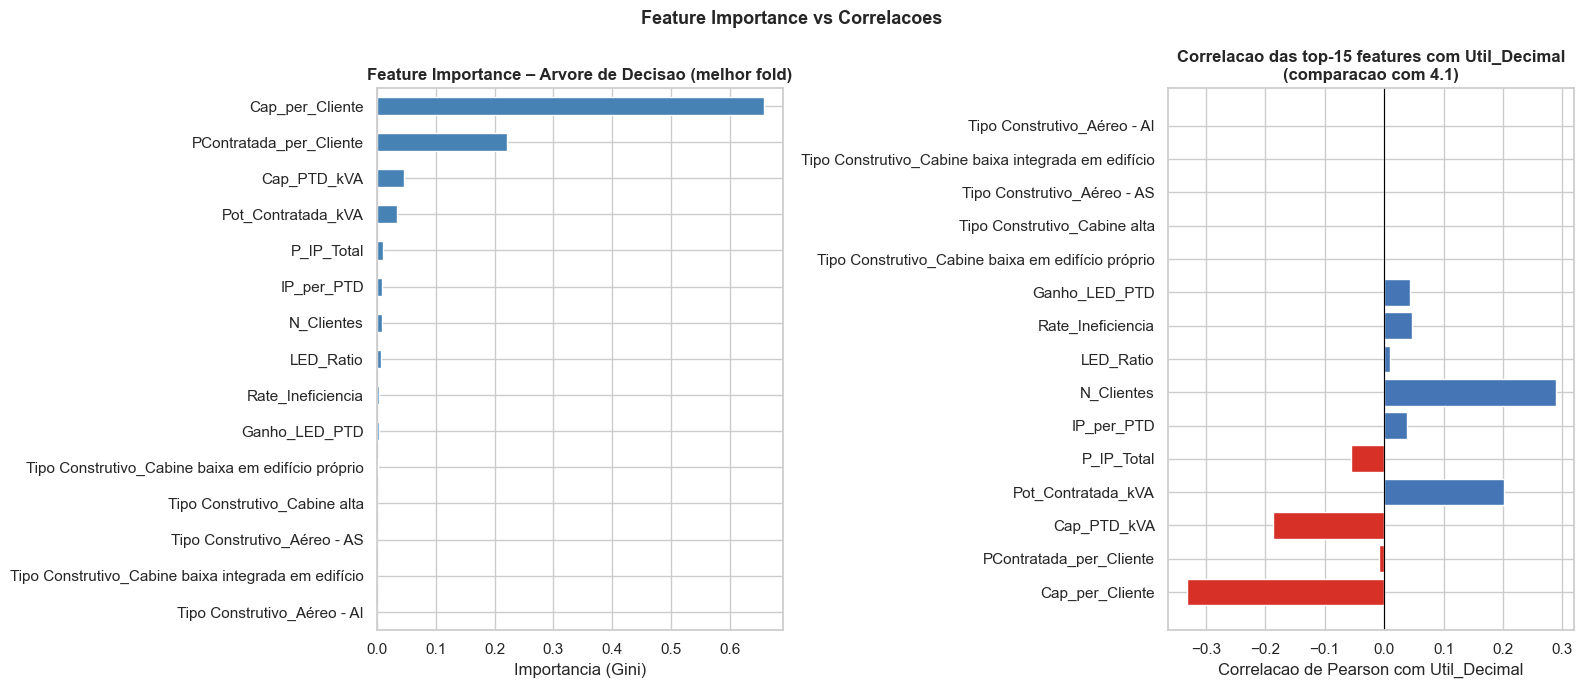

Top 10 features (Arvore):
  Cap_per_Cliente                     imp=0.6576  corr=-0.332
  PContratada_per_Cliente             imp=0.2217  corr=-0.009
  Cap_PTD_kVA                         imp=0.0453  corr=-0.187
  Pot_Contratada_kVA                  imp=0.0344  corr=+0.201
  P_IP_Total                          imp=0.0108  corr=-0.055
  IP_per_PTD                          imp=0.0084  corr=+0.039
  N_Clientes                          imp=0.0076  corr=+0.288
  LED_Ratio                           imp=0.0065  corr=+0.011
  Rate_Ineficiencia                   imp=0.0031  corr=+0.046
  Ganho_LED_PTD                       imp=0.0028  corr=+0.043


In [61]:
feat_imp = pd.Series(best_dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Correlacao de Pearson de cada feature com Util_Decimal (proxy do target)
num_features = [c for c in feature_cols if df_model[c].nunique() > 2]
corr_util = df_model[num_features + ['Util_Decimal']].corr()['Util_Decimal'].drop('Util_Decimal')
corr_util = corr_util.reindex(feat_imp.index).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feat_imp.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance – Arvore de Decisao (melhor fold)', fontweight='bold')
axes[0].set_xlabel('Importancia (Gini)')

top_feats = feat_imp.head(15).index
corr_top  = corr_util.reindex(top_feats)
bar_colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_top.values]
axes[1].barh(range(len(top_feats)), corr_top.values, color=bar_colors)
axes[1].set_yticks(range(len(top_feats)))
axes[1].set_yticklabels(top_feats)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlacao de Pearson com Util_Decimal')
axes[1].set_title('Correlacao das top-15 features com Util_Decimal\n(comparacao com 4.1)', fontweight='bold')

plt.suptitle('Feature Importance vs Correlacoes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance_cls.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features (Arvore):')
for feat, imp in feat_imp.head(10).items():
    corr_v = corr_util.get(feat, 0)
    print(f'  {feat:<35} imp={imp:.4f}  corr={corr_v:+.3f}')

**Discussão da importância de features:**  
As variáveis com maior importância na árvore de decisão correspondem tendencialmente às que apresentam maior correlação absoluta com `Util_Decimal` na análise da secção 4.1. Variáveis de capacidade instalada (`Cap_PTD_kVA`) e de carga contratada (`Pot_Contratada_kVA`, `N_Clientes`) surgem como as mais discriminativas, uma vez que a utilização da rede é fundamentalmente determinada pelo rácio entre a carga ligada e a capacidade disponível. Variáveis de iluminação pública (`P_IP_Total`, `LED_Ratio`) apresentam importâncias mais baixas, consistent com as correlações fracas identificadas em 4.1, confirmando que o consumo de IP tem impacto marginal na classificação do nível de ocupação da rede.

---
## 6. Significância Estatística – Dois Melhores Modelos

In [62]:
top2_nomes = results.head(2)['Modelo'].tolist()
model_f1_dict = {
    'Arvore de Decisao': np.array(metricas_dt['f1']),
    'Rede Neuronal':     np.array(metricas_nn['f1']),
    f'SVM ({best_kernel})': np.array(metricas_svm['f1']),
    f'KNN (K={best_k})': np.array(metricas_knn['f1']),
}

m1, m2 = top2_nomes[0], top2_nomes[1]
e1, e2 = model_f1_dict[m1], model_f1_dict[m2]

print(f'Modelo 1: {m1}')
print(f'  F1 por fold: {np.round(e1, 4)}')
print(f'  Media: {e1.mean():.4f} +/- {e1.std():.4f}')
print()
print(f'Modelo 2: {m2}')
print(f'  F1 por fold: {np.round(e2, 4)}')
print(f'  Media: {e2.mean():.4f} +/- {e2.std():.4f}')

alpha = 0.05
diffs = e1 - e2
stat_sw, p_sw = stats.shapiro(diffs)
print(f'\nShapiro-Wilk nas diferencas: W={stat_sw:.4f}, p={p_sw:.4f}')
normal = p_sw > alpha
print(f'Diferencas {"normais" if normal else "nao-normais"} (alpha=0.05)')

if normal:
    stat_t, p_val = stats.ttest_rel(e1, e2)
    test_name = 't-test pareado'
    print(f'\nt-test pareado: t={stat_t:.4f}, p={p_val:.4f}')
else:
    stat_w, p_val = stats.wilcoxon(e1, e2)
    test_name = 'Wilcoxon signed-rank'
    print(f'\nWilcoxon signed-rank: W={stat_w:.4f}, p={p_val:.4f}')

print(f'\nConclusao ({test_name}, alpha=0.05):')
if p_val < alpha:
    melhor = m1 if e1.mean() > e2.mean() else m2
    print(f'  p={p_val:.4f} < 0.05 -> diferenca estatisticamente significativa.')
    print(f'  Melhor modelo: "{melhor}"')
else:
    print(f'  p={p_val:.4f} >= 0.05 -> diferenca NAO estatisticamente significativa.')
    print(f'  Nao e possivel concluir que um modelo supera o outro a alpha=0.05.')

Modelo 1: Rede Neuronal
  F1 por fold: [0.707  0.7091 0.7045 0.7089 0.7079 0.699  0.7031 0.7187 0.7086 0.7046]
  Media: 0.7072 +/- 0.0049

Modelo 2: Arvore de Decisao
  F1 por fold: [0.6905 0.6899 0.6926 0.6921 0.6941 0.6934 0.6912 0.7064 0.6826 0.694 ]
  Media: 0.6927 +/- 0.0056

Shapiro-Wilk nas diferencas: W=0.9488, p=0.6539
Diferencas normais (alpha=0.05)

t-test pareado: t=8.2717, p=0.0000

Conclusao (t-test pareado, alpha=0.05):
  p=0.0000 < 0.05 -> diferenca estatisticamente significativa.
  Melhor modelo: "Rede Neuronal"


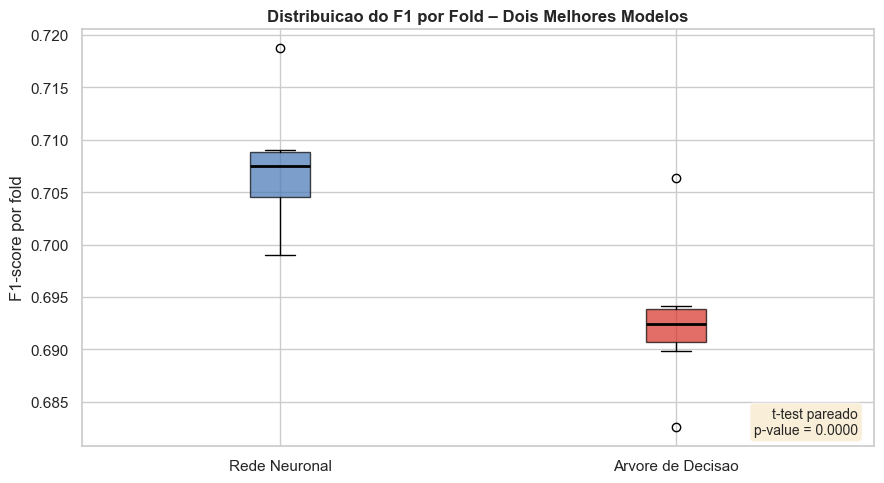

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([e1, e2], labels=[m1, m2], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors_bp = ['#4575b4', '#d73027']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('F1-score por fold')
ax.set_title('Distribuicao do F1 por Fold – Dois Melhores Modelos', fontweight='bold')
ax.text(0.98, 0.02,
        f'{test_name}\np-value = {p_val:.4f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('fig_stat_test_cls.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Curvas de Aprendizagem – Melhor e Pior Modelo

Melhor: Rede Neuronal  |  Pior: KNN (K=10)


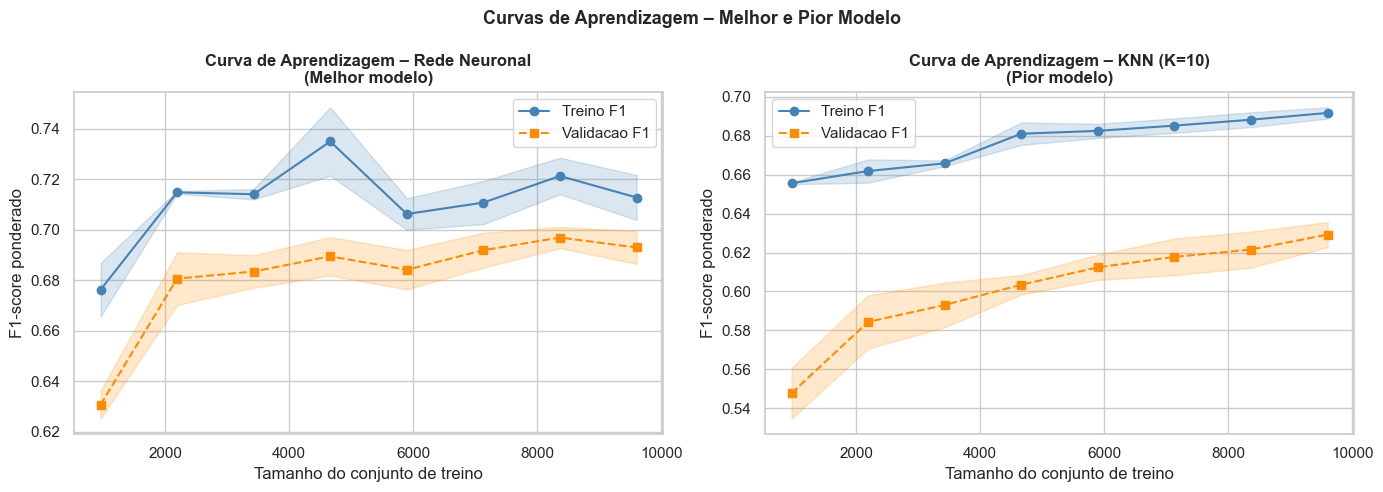

In [64]:
best_model_nome = results.iloc[0]['Modelo']
worst_model_nome = results.iloc[-1]['Modelo']
print(f'Melhor: {best_model_nome}  |  Pior: {worst_model_nome}')

model_map_lc = {
    'Arvore de Decisao': DecisionTreeClassifier(**best_dt_params, random_state=SEED),
    'Rede Neuronal': MLPClassifier(
        hidden_layer_sizes=best_nn_cfg['hidden_layer_sizes'],
        activation='relu', solver='adam',
        alpha=best_nn_cfg['alpha'],
        learning_rate_init=best_nn_cfg['learning_rate_init'],
        max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=10, random_state=SEED),
    f'SVM ({best_kernel})': SVC(kernel=best_kernel, C=10, random_state=SEED),
    f'KNN (K={best_k})':   KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
}

MAX_LC = 12000
idx_lc = np.random.choice(len(X_nn), size=min(MAX_LC, len(X_nn)), replace=False)
X_lc   = X_nn[idx_lc]
y_lc   = y[idx_lc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_nome in zip(axes, [best_model_nome, worst_model_nome]):
    if model_nome not in model_map_lc:
        ax.set_visible(False)
        continue
    estimator = model_map_lc[model_nome]
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_lc, y_lc,
        cv=5, scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_mean = val_scores.mean(axis=1)
    va_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='steelblue',  label='Treino F1')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color='steelblue')
    ax.plot(train_sizes, va_mean, 's--', color='darkorange', label='Validacao F1')
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.2, color='darkorange')
    ax.set_xlabel('Tamanho do conjunto de treino')
    ax.set_ylabel('F1-score ponderado')
    label = 'Melhor' if model_nome == best_model_nome else 'Pior'
    ax.set_title(f'Curva de Aprendizagem – {model_nome}\n({label} modelo)', fontweight='bold')
    ax.legend()

plt.suptitle('Curvas de Aprendizagem – Melhor e Pior Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_learning_curves_cls.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação das Curvas de Aprendizagem:**  
- Se a **curva de validação converge para a de treino** com mais dados e ambas atingem um patamar elevado → modelo bem calibrado, sem overfitting ou underfitting significativo.  
- Se a **curva de validação se mantém muito abaixo da de treino** independentemente do tamanho → **overfitting**: o modelo memoriza o treino mas não generaliza. Solução: regularização, redução de complexidade.  
- Se **ambas as curvas ficam em patamares baixos** mesmo com muitos dados → **underfitting**: modelo demasiado simples. Solução: aumentar complexidade ou adicionar features.  
- A análise da curva do **pior modelo** revela se o problema é estrutural (arquitetura inadequada) ou se apenas necessita de mais dados de treino.

---
## 8. Limitações e Estratégias de Melhoria

**Limitações identificadas:**

1. **Discretização do target:** A transformação de `Util_Decimal` (variável contínua) em três classes por quantis introduz fronteiras artificiais — registos próximos dos limiares p33 e p67 são facilmente mal classificados por qualquer modelo, o que limita o F1 máximo alcançável. Uma alternativa seria manter a previsão contínua (regressão, como em 4.2) ou usar mais classes com fronteiras operacionalmente motivadas.

2. **Amostragem para SVM e KNN:** Os modelos SVM e KNN foram avaliados em subconjuntos (10k e 20k registos, respetivamente) por limitações computacionais. Os resultados podem não ser representativos do comportamento no dataset completo, penalizando ou favorecendo artificialmente estes modelos na comparação.

3. **Distribuição temporal e geográfica:** O dataset agrega PTDs de regiões e períodos potencialmente heterogéneos. A ausência de informação temporal impede detetar sazonalidade ou tendências evolutivas na utilização da rede, o que poderia melhorar a capacidade preditiva dos modelos.

4. **Features de iluminação pública:** Variáveis como `P_IP_Total` e `LED_Ratio` têm baixa importância para a classificação de `utilizRede`, sugerindo que o dataset contém features com fraco poder discriminativo que podem aumentar o ruído no treino.

5. **Hiperotimização limitada:** O GridSearch para a árvore de decisão explorou apenas combinações de `max_depth` e `min_samples_leaf`. Parâmetros adicionais (e.g., `criterion`, `max_features`) poderiam revelar configurações superiores.

**Estratégias propostas:**

- **Seleção de features** (e.g., RFE, SHAP values) para eliminar variáveis de baixo poder discriminativo e reduzir dimensionalidade.
- **Modelos de ensemble** (Random Forest, Gradient Boosting, XGBoost) como alternativa às árvores simples, tipicamente mais robustos e com melhor generalização.
- **Otimização bayesiana** de hiperparâmetros (Optuna, Hyperopt) em substituição do GridSearch, mais eficiente no espaço de busca.
- **Uso de algoritmos aproximados** (e.g., Ball Tree, KD-Tree, Faiss) para viabilizar KNN no dataset completo.
- **Fronteiras de classe baseadas em domínio** validadas com especialistas de rede elétrica, de forma a produzir classes com significado operacional e maior separabilidade.

---
## Sumário Final

In [65]:
print('=' * 70)
print('  SUMARIO – MODELOS DE CLASSIFICACAO (utilizRede)')
print('=' * 70)
print(results[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1',
               'F1_baixo', 'F1_medio', 'F1_alto']].to_string(index=False, float_format='%.4f'))
print('=' * 70)
print(f'\nDiscretizacao: quantis (tertis)  |  p33={q33:.3f}  p67={q67:.3f}')
print(f'Dois melhores modelos: {top2_nomes[0]}  e  {top2_nomes[1]}')
print(f'Teste estatistico: {test_name}  |  p-value = {p_val:.4f}  (alpha=0.05)')
if p_val < 0.05:
    melhor = m1 if e1.mean() > e2.mean() else m2
    print(f'Melhor modelo com significancia estatistica: {melhor}')
else:
    print('Diferenca entre os dois melhores modelos NAO e estatisticamente significativa.')
print(f'\nVariavel mais importante (Arvore): {feat_imp.index[0]}')

  SUMARIO – MODELOS DE CLASSIFICACAO (utilizRede)
           Modelo  Accuracy  Precision  Recall     F1  F1_baixo  F1_medio  F1_alto
    Rede Neuronal    0.7151     0.7052  0.7151 0.7072    0.8252    0.4892   0.6821
Arvore de Decisao    0.7015     0.6902  0.7015 0.6927    0.8168    0.4648   0.6650
        SVM (rbf)    0.6917     0.6768  0.6917 0.6783    0.8029    0.4450   0.6647
       KNN (K=10)    0.6578     0.6401  0.6578 0.6416    0.7925    0.3967   0.5727

Discretizacao: quantis (tertis)  |  p33=0.390  p67=0.590
Dois melhores modelos: Rede Neuronal  e  Arvore de Decisao
Teste estatistico: t-test pareado  |  p-value = 0.0000  (alpha=0.05)
Melhor modelo com significancia estatistica: Rede Neuronal

Variavel mais importante (Arvore): Cap_per_Cliente
